(mmm_multiplicative)=
# Additive vs Log vs Log-Log Marketing Mix Models

This notebook compares three MMM specifications available through the `link` parameter on the `MMM` class:

| Model | `link` | Saturation | Likelihood | Interpretation |
|-------|--------|------------|------------|----------------|
| **Additive** | `"identity"` | `LogisticSaturation` | Normal | Components add to $y$ |
| **Log (multiplicative)** | `"log"` | `LogisticSaturation` | LogNormal | Components multiply $y$ via $\exp$ |
| **Log-log** | `"log"` | `LogSaturation` | LogNormal | Response is a log transform of spend |

After comparing the three decompositions, we close by comparing the models on a single estimand that *is* directly comparable across links: ROAS, computed with the `mmm.incrementality` module and checked against the true ROAS of the simulated data.

## Mathematical Formulation

All three models share the same **linear predictor**:

$$
\mu = \text{intercept} + \sum_c \text{saturation}_c(\text{adstock}_c(x_c)) + \text{controls} + \text{seasonality}
$$

They differ in how $\mu$ relates to the observed target $y$:

### 1. Additive (Identity Link)

$$
y_{\text{scaled}} \sim \text{Normal}(\mu, \sigma)
$$

Each component of $\mu$ contributes additively to $y$. This is the standard formulation used in most MMM literature.

### 2. Log (Multiplicative)

$$y_{\text{scaled}} \sim \text{LogNormal}(\mu, \sigma)$$

Equivalently, $\log(y_{\text{scaled}}) \sim \text{Normal}(\mu, \sigma)$, so $y \propto \exp(\mu)$. Each additive component in $\mu$ becomes a **multiplicative factor** on $y$:

$$
y = \exp(\text{intercept}) \times \prod_c \exp(\text{saturation}_c) \times \exp(\text{controls}) \times \ldots
$$

Use this when the data-generating process is multiplicative (e.g. sales = baseline $\times$ media uplift $\times$ seasonality).

### 3. Log-Log

Same as the log model, but the saturation function is $\beta \log(1 + x)$ (`LogSaturation`) applied to **raw spend** instead of a sigmoidal curve. Both sides of the relationship are then on a log scale (log response, log spend), which is why we call it a *log-log* model.

Use this when channel response is concave in log-spend and you want a simple, interpretable functional form. `\log(1 + x)` (rather than `\log x`) keeps the transform finite at $x = 0$, which is common for paused channels.

## Trend Handling

A raw integer trend $t = 0, 1, \ldots, n$ behaves differently depending on the link function:

- **Identity link**: $\gamma_t \cdot t$ adds a **linear** trend to $y$.
- **Log link**: $\gamma_t \cdot t$ in log-space gives **exponential** growth $y \propto \exp(\gamma_t \cdot t)$.

With the quickstart's prior $\gamma \sim \text{Normal}(0, 0.05)$ and $t$ up to ~200, the log-space contribution could reach $\exp(10) \approx 22{,}000\times$, completely degenerate. To avoid this, we **normalize the trend to $[0, 1]$** for the log and log-log models, so $\gamma_t$ directly represents the total multiplicative trend factor via $\exp(\gamma_t)$.

## Prepare Notebook

In [1]:
import warnings

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.lines import Line2D
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation, LogSaturation
from pymc_marketing.mmm.mmm import MMM
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

warnings.filterwarnings("ignore")

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
seed = sum(map(ord, "mmm_multiplicative"))
rng = np.random.default_rng(seed=seed)

## Data Loading and Preparation

We use a synthetic weekly dataset with two media channels (`x1`, `x2`), two event indicators, and a sales target. All three models will be fitted to the same data so that any differences in the decomposition reflect the link function choice, not the training set.

In [3]:
url = "https://raw.githubusercontent.com/pymc-labs/pymc-marketing/main/data/mmm_example.csv"
data = pd.read_csv(url, parse_dates=["date_week"])
data.head()

,date_week,y,x1,x2,event_1,event_2,dayofyear,t
0,2018-04-02,3984.662237,0.318580,0.0,0.0,0.0,92,0
1,2018-04-09,3762.871794,0.112388,0.0,0.0,0.0,99,1
2,2018-04-16,4466.967388,0.292400,0.0,0.0,0.0,106,2
3,2018-04-23,3864.219373,0.071399,0.0,0.0,0.0,113,3
4,2018-04-30,4441.625278,0.386745,0.0,0.0,0.0,120,4


In [4]:
# Raw integer trend (for the additive model, matching the quickstart)
data["t"] = range(len(data))

# Normalized trend in [0, 1] (for log/log-log models, avoids exponential blow-up)
data["t_norm"] = data["t"] / data["t"].max()

y = data["y"]

# Two versions of X: one per link type
X_additive = data.drop(columns=["y"])
X_log = data.drop(columns=["y", "t"]).copy()

print(f"Observations: {len(data)}")
print(f"Target range: [{y.min():.1f}, {y.max():.1f}]")
print(f"All y > 0: {(y > 0).all()}  (required for log link)")

Observations: 179
Target range: [3192.9, 8312.4]
All y > 0: True  (required for log link)


In [5]:
CHANNELS = ["x1", "x2"]
CONTROL_COLUMNS_ADDITIVE = ["event_1", "event_2", "t"]
CONTROL_COLUMNS_LOG = ["event_1", "event_2", "t_norm"]

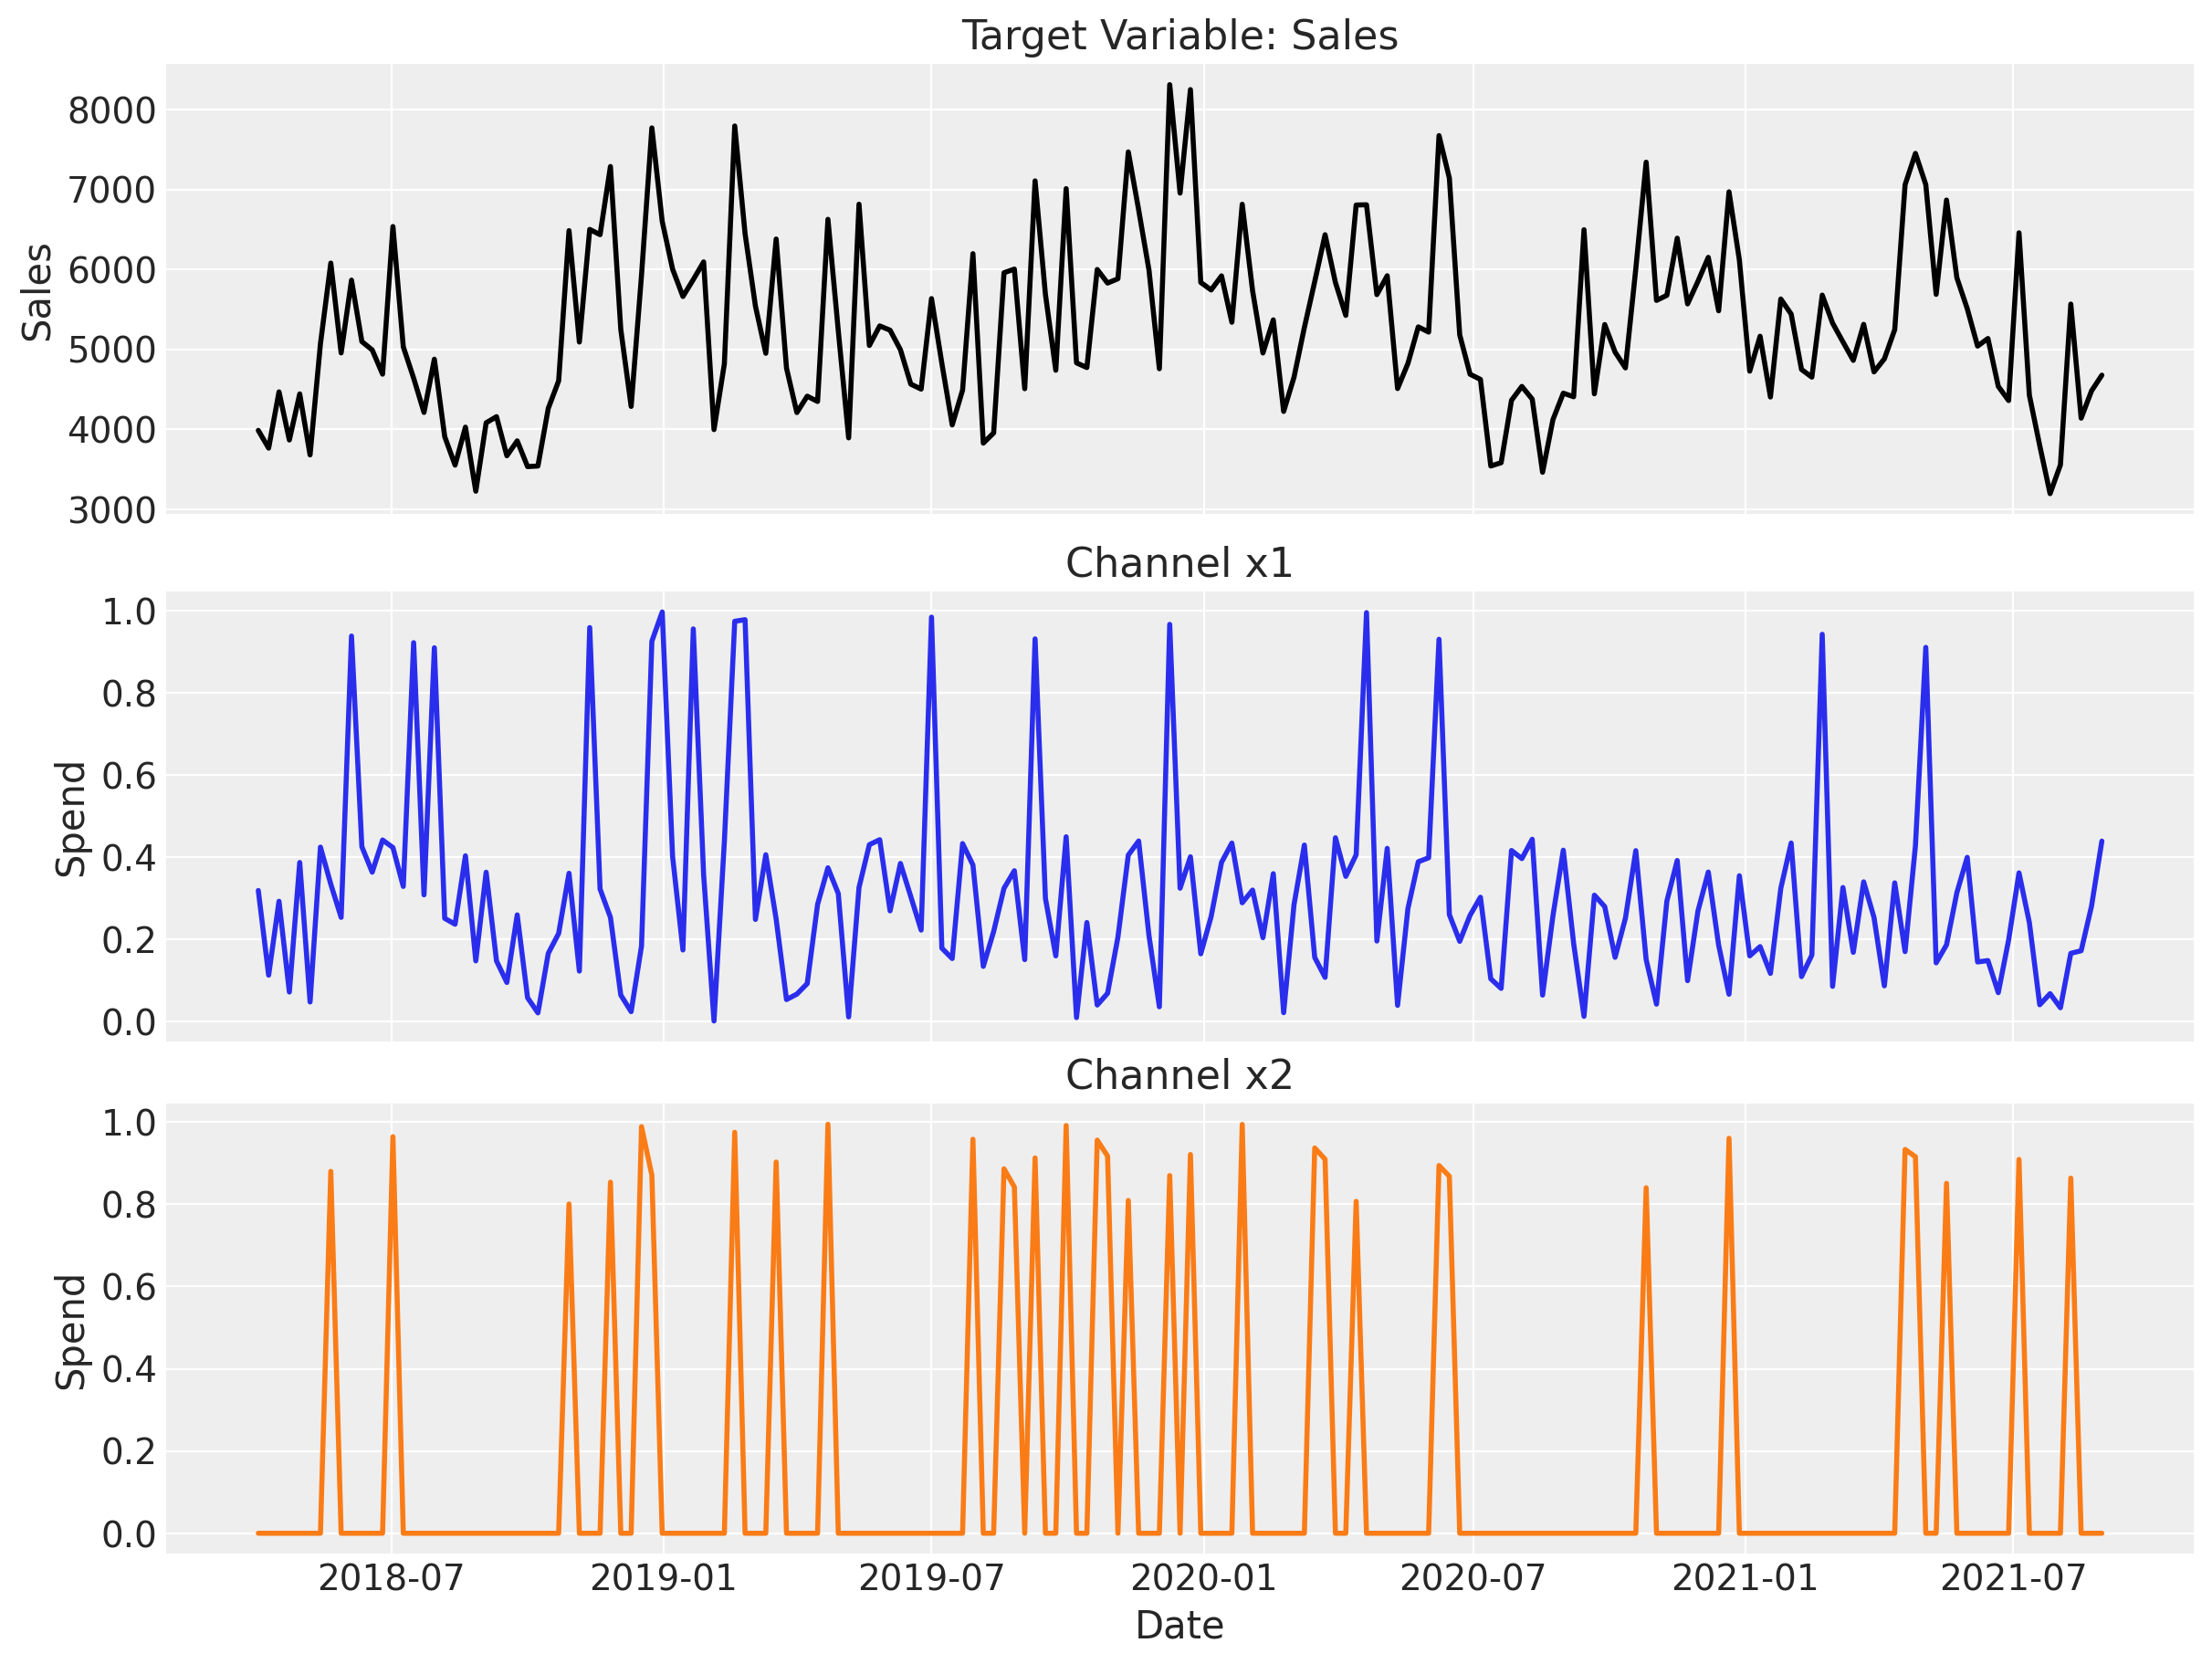

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Sales
axes[0].plot(data["date_week"], data["y"], color="black", linewidth=2)
axes[0].set(ylabel="Sales", title="Target Variable: Sales")

# Channel 1
axes[1].plot(data["date_week"], data["x1"], color="C0", linewidth=2)
axes[1].set(ylabel="Spend", title="Channel x1")

# Channel 2
axes[2].plot(data["date_week"], data["x2"], color="C1", linewidth=2)
axes[2].set(xlabel="Date", ylabel="Spend", title="Channel x2");

Channel `x1` carries the bulk of the spend and shows clear seasonality; `x2` is smaller and more sporadic. Sales visually track `x1`, suggesting it will dominate the estimated media effect. The two event columns (not plotted) are binary indicators for one-off promotions.

## Spend Shares and Prior Configuration

We scale the prior standard deviations for the channel coefficients by each channel's share of total spend. This way, channels with higher spend get wider priors, allowing the model to assign them proportionally larger effects while keeping the overall prior mass comparable across channels.

In [7]:
total_spend_per_channel = data[CHANNELS].sum(axis=0)
spend_share = total_spend_per_channel / total_spend_per_channel.sum()
n_channels = len(CHANNELS)
prior_sigma = n_channels * spend_share.to_numpy()

## Model 1: Additive (Identity Link)

This is the standard additive MMM from the quickstart notebook. The linear
predictor $\mu$ maps directly to the expected value of $y$ via the identity
link and a Normal likelihood.

In [8]:
# --- Additive model config (from quickstart) ---
additive_model_config = {
    "intercept": Prior("Normal", mu=0.5, sigma=0.2),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.05, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=6), dims="date"),
}


mmm_additive = MMM(
    model_config=additive_model_config,
    target_column="y",
    date_column="date_week",
    channel_columns=CHANNELS,
    control_columns=CONTROL_COLUMNS_ADDITIVE,
    yearly_seasonality=2,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    link="identity",
)

# Opt in to the new namespace-based plot suite
mmm_additive.plot_suite = "new"

mmm_additive.build_model(X_additive, y)
mmm_additive.add_original_scale_contribution_variable(
    [
        "intercept_contribution",
        "control_contribution",
        "channel_contribution",
        "fourier_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)
mmm_additive.table()

                                 Variable  Expression                                  Dimensions                  
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                          channel_scale =  Data                                        channel[2]                  
                           target_scale =  Data                                                                    
                           channel_data =  Data                                        date[179] × channel[2]      
                            target_data =  Data                                        date[179]                   
                           control_data =  Data                                        date[179] × control[3]      
                              dayofyear =  Data                                        date[179]                   
                                                                                                                   
                 intercept_contribution ~  Normal(0.5, 0.2)                                                        
                          adstock_alpha ~  Beta(1, 3)                                  channel[2]                  
                         saturation_lam ~  Gamma(3, <constant>)                        channel[2]                  
                        saturation_beta ~  HalfNormal(0, <constant>)                   channel[2]                  
                          gamma_control ~  Normal(0, 0.05)                             control[3]                  
                          gamma_fourier ~  Laplace(0, 0.2)                             fourier_mode[4]             
                                y_sigma ~  HalfNormal(0, 6)                                                        
                                                                                       Parameter count = 15        
                                                                                                                   
                   channel_contribution =  f(saturation_beta, saturation_lam,          date[179] × channel[2]      
                                           adstock_alpha)                                                          
                   control_contribution =  f(gamma_control)                            date[179] × control[3]      
                   fourier_contribution =  f(gamma_fourier)                            date[179] × fourier_mode[4] 
        yearly_seasonality_contribution =  f(gamma_fourier)                            date[179]                   
  total_media_contribution_original_scale  f(saturation_beta, saturation_lam,                                      
                                        =  adstock_alpha)                                                          
  intercept_contribution_original_scale =  f(intercept_contribution)                                               
    control_contribution_original_scale =  f(gamma_control)                            date[179] × control[3]      
    channel_contribution_original_scale =  f(saturation_beta, saturation_lam,          date[179] × channel[2]      
                                           adstock_alpha)                                                          
    fourier_contribution_original_scale =  f(gamma_fourier)                            date[179] × fourier_mode[4] 
 yearly_seasonality_contribution_origina…  f(gamma_fourier)                            date[179]                   
                                        =                                                                          
                       y_original_scale =  f(y)                                        date[179]                   
                                                                                                                   
                                      y ~  Normal(f(inte

In [9]:
fit_kwargs = {
    "chains": 4,
    "target_accept": 0.85,
    "nuts_sampler": "nutpie",
    "random_seed": rng,
}

_ = mmm_additive.fit(X_additive, y, **fit_kwargs)

NUTS[nutpie]: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling complete. We inspect the trace plots for convergence before interpreting the results.

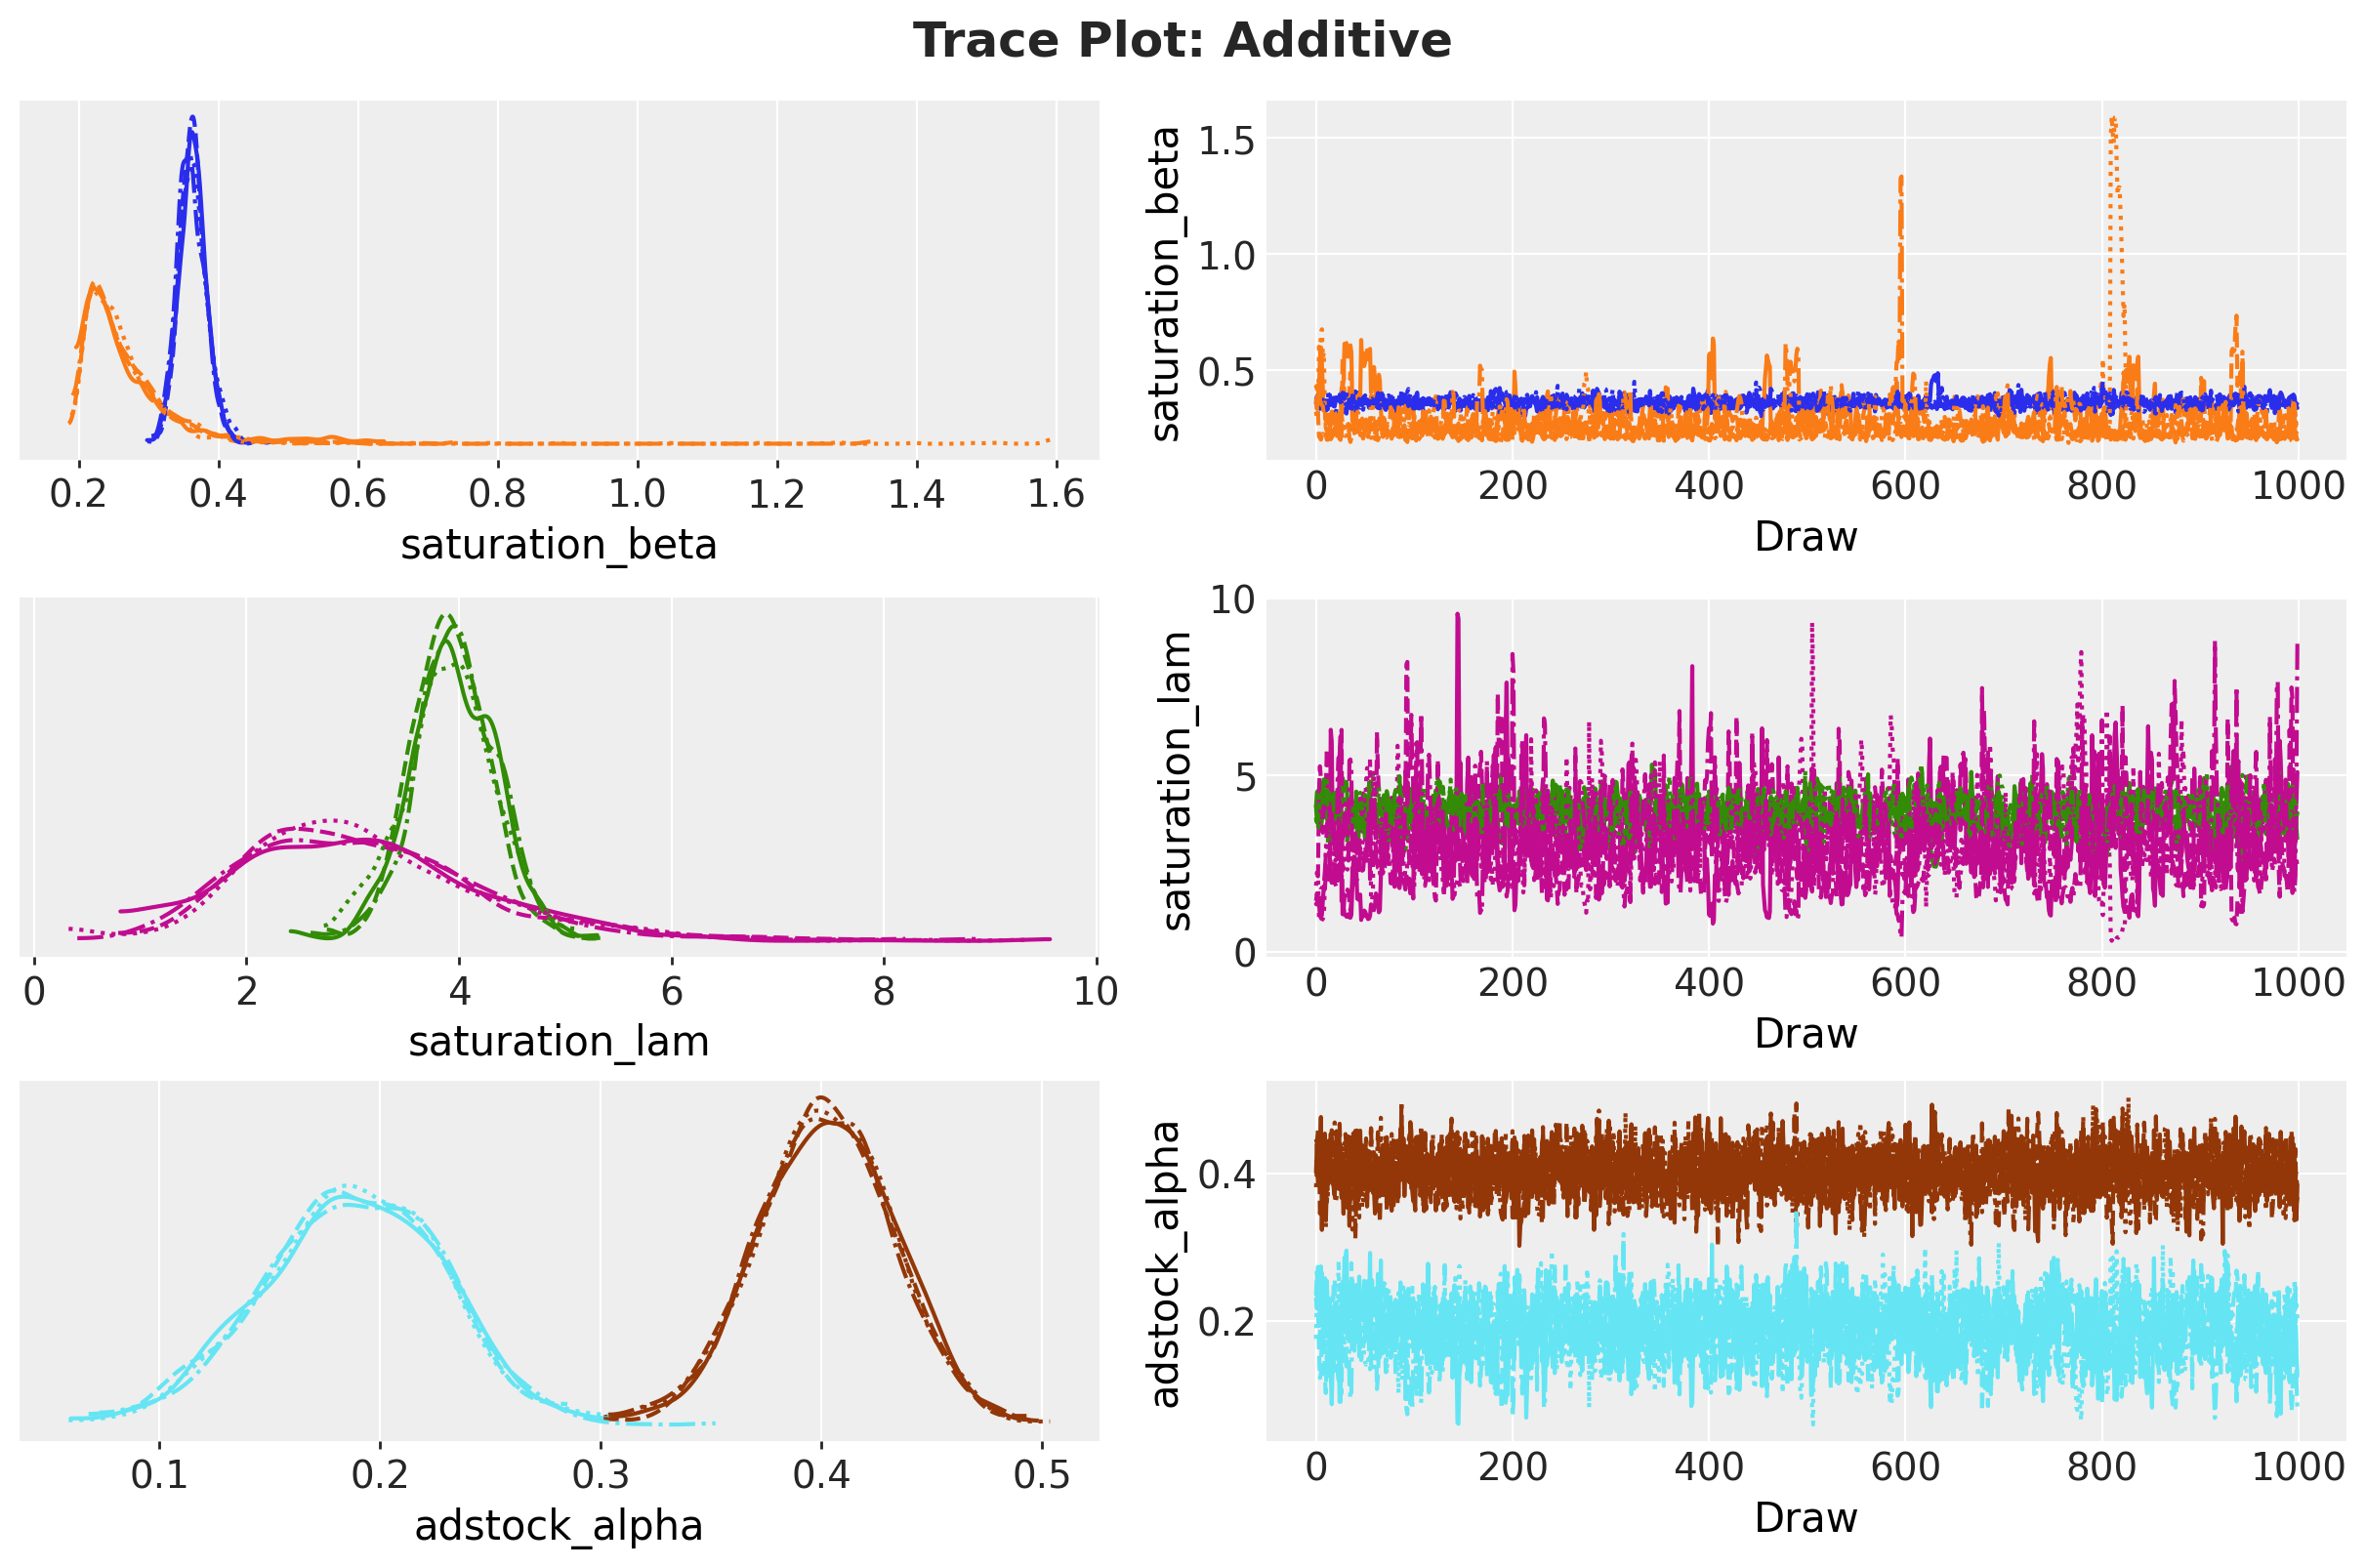

In [10]:
def plot_trace_dist(mmm, model_name, var_names):
    """Plot trace for key media parameters."""
    pc = azp.plot_trace_dist(
        mmm.fit_result,
        var_names=var_names,
        figure_kwargs={"figsize": (12, 2.5 * len(var_names))},
    )
    fig = pc.viz["/"]["figure"].values.item()
    fig.suptitle(f"Trace Plot: {model_name}", y=1.05, fontsize=18, fontweight="bold")


TRACE_VAR_NAMES = [
    "saturation_beta",
    "saturation_lam",
    "adstock_alpha",
]

plot_trace_dist(
    mmm_additive,
    model_name="Additive",
    var_names=TRACE_VAR_NAMES,
)

Well-behaved traces show stationary chains that mix well and overlap in their marginal densities. Check the reported number of divergences (ideally zero) before interpreting the posteriors.

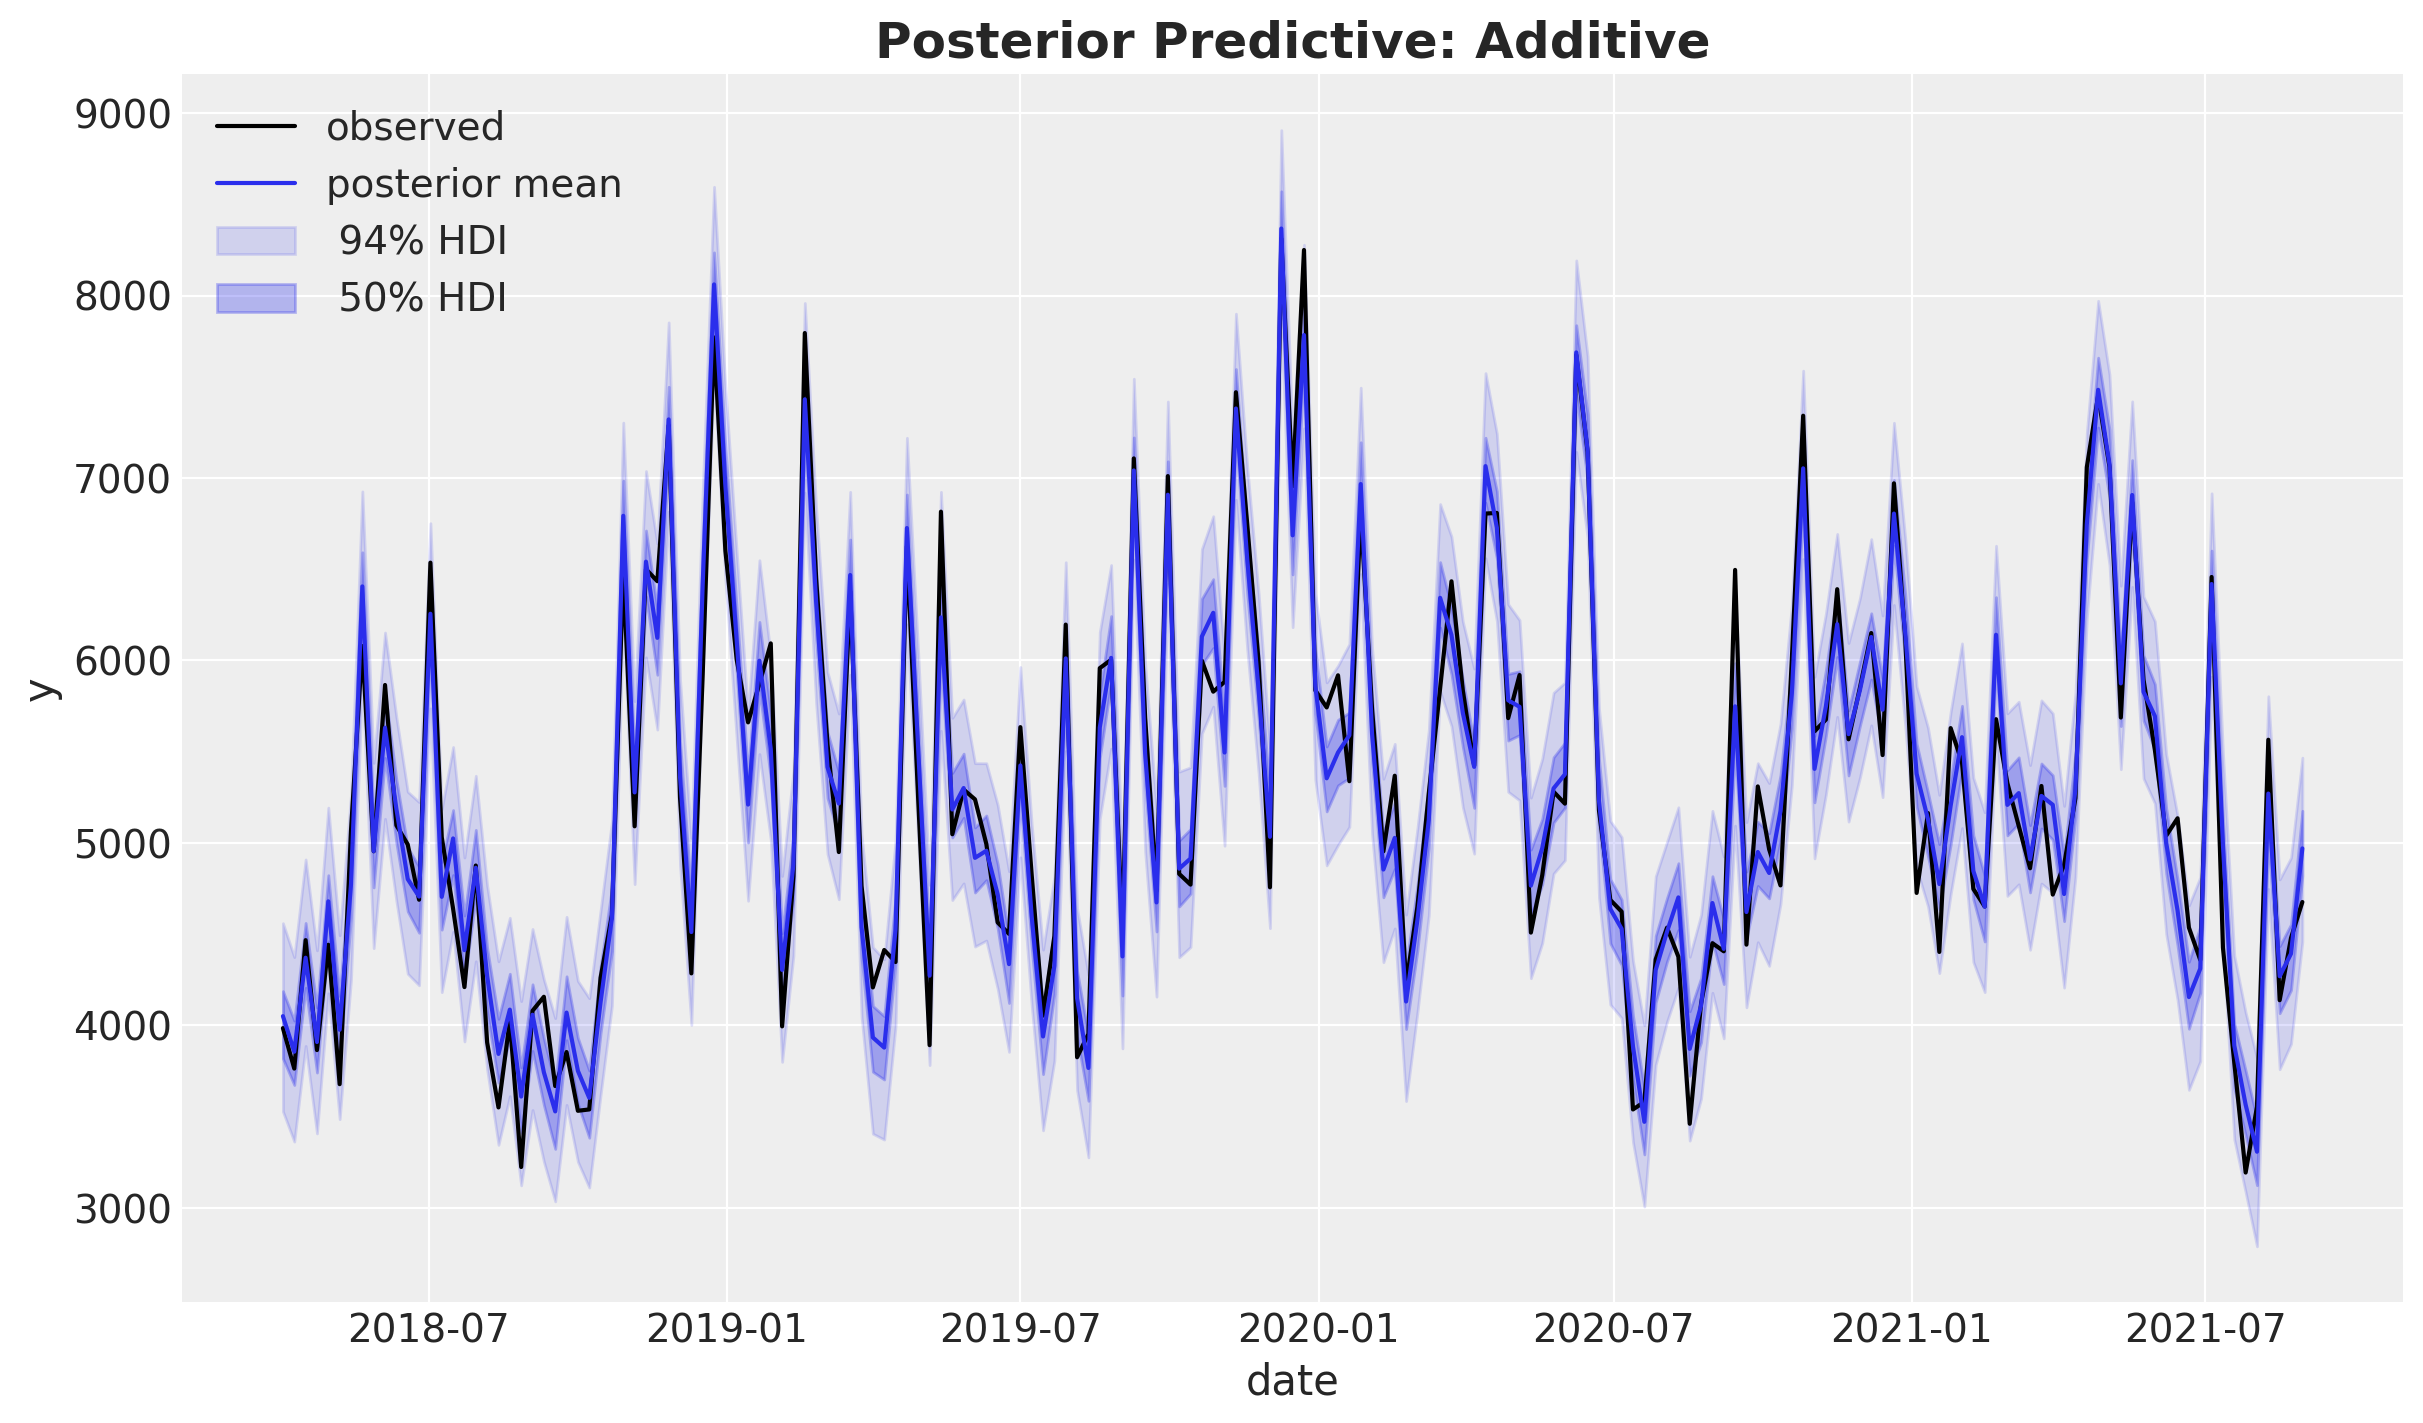

In [11]:
def plot_posterior_predictive(mmm, y_obs, model_name):
    y_hat_orig = mmm.idata.posterior["y_original_scale"]
    y_hat_flat = y_hat_orig.stack(sample=("chain", "draw")).values

    fig, ax = plt.subplots()
    dates = mmm.X["date_week"]
    ax.plot(dates, y_obs, color="black", label="observed")
    mean = y_hat_flat.mean(axis=-1)
    ax.plot(dates, mean, color="C0", label="posterior mean")
    for hdi_prob, alpha in zip([0.94, 0.5], [0.15, 0.3], strict=True):
        hdi = az.hdi(y_hat_orig, prob=hdi_prob)
        ax.fill_between(
            dates,
            hdi.sel(ci_bound="lower"),
            hdi.sel(ci_bound="upper"),
            color="C0",
            alpha=alpha,
            label=f"{hdi_prob: 0.0%} HDI",
        )
    ax.set(xlabel="date", ylabel="y")
    ax.legend()
    ax.set_title(f"Posterior Predictive: {model_name}", fontsize=18, fontweight="bold")
    return fig, ax


fig, ax = plot_posterior_predictive(mmm_additive, model_name="Additive", y_obs=y)

The posterior mean closely tracks the observed data and the HDI bands are reasonably tight, indicating a good in-sample fit. The model captures the seasonal pattern visible in the raw sales data.

### Decomposing contributions in the additive model

`compute_mean_contributions_over_time()` uses a **unified counterfactual decomposition** for all link types. Each column answers: *"how much would $\hat y(t)$ decrease if we removed this component?"*

For component $j$ with value $v_j(t)$ in the linear predictor:

$$
\text{contribution}_j(t)
= \mathbb{E}\bigl[\text{inv}(\mu) \cdot s\bigr]
- \mathbb{E}\bigl[\text{inv}(\mu - v_j) \cdot s\bigr]
$$

where $\text{inv}$ is the inverse link and $s$ = `target_scale`.

With an identity link $\text{inv}$ is the identity function, so this simplifies to:

$$
\text{contribution}_j(t) = \mathbb{E}[v_j(t)] \cdot s
$$

The resulting columns **sum exactly to $\hat y(t)$** at every date. Each line in the decomposition plot below can be read as *"this many units of $y$ came from this component on this date."*

In [12]:
contributions_additive = mmm_additive.compute_mean_contributions_over_time()
contributions_additive.head()

,date,x1,x2,event_1,event_2,t,yearly_seasonality,intercept
0,2018-04-02,1078.705171,0.0,0.0,0.0,0.000000,21.745057,2951.421078
1,2018-04-09,829.675762,0.0,0.0,0.0,5.133787,74.001250,2951.421078
2,2018-04-16,1289.139467,0.0,0.0,0.0,10.267574,120.011104,2951.421078
3,2018-04-23,788.901879,0.0,0.0,0.0,15.401361,154.451684,2951.421078
4,2018-04-30,1535.045933,0.0,0.0,0.0,20.535149,172.735079,2951.421078


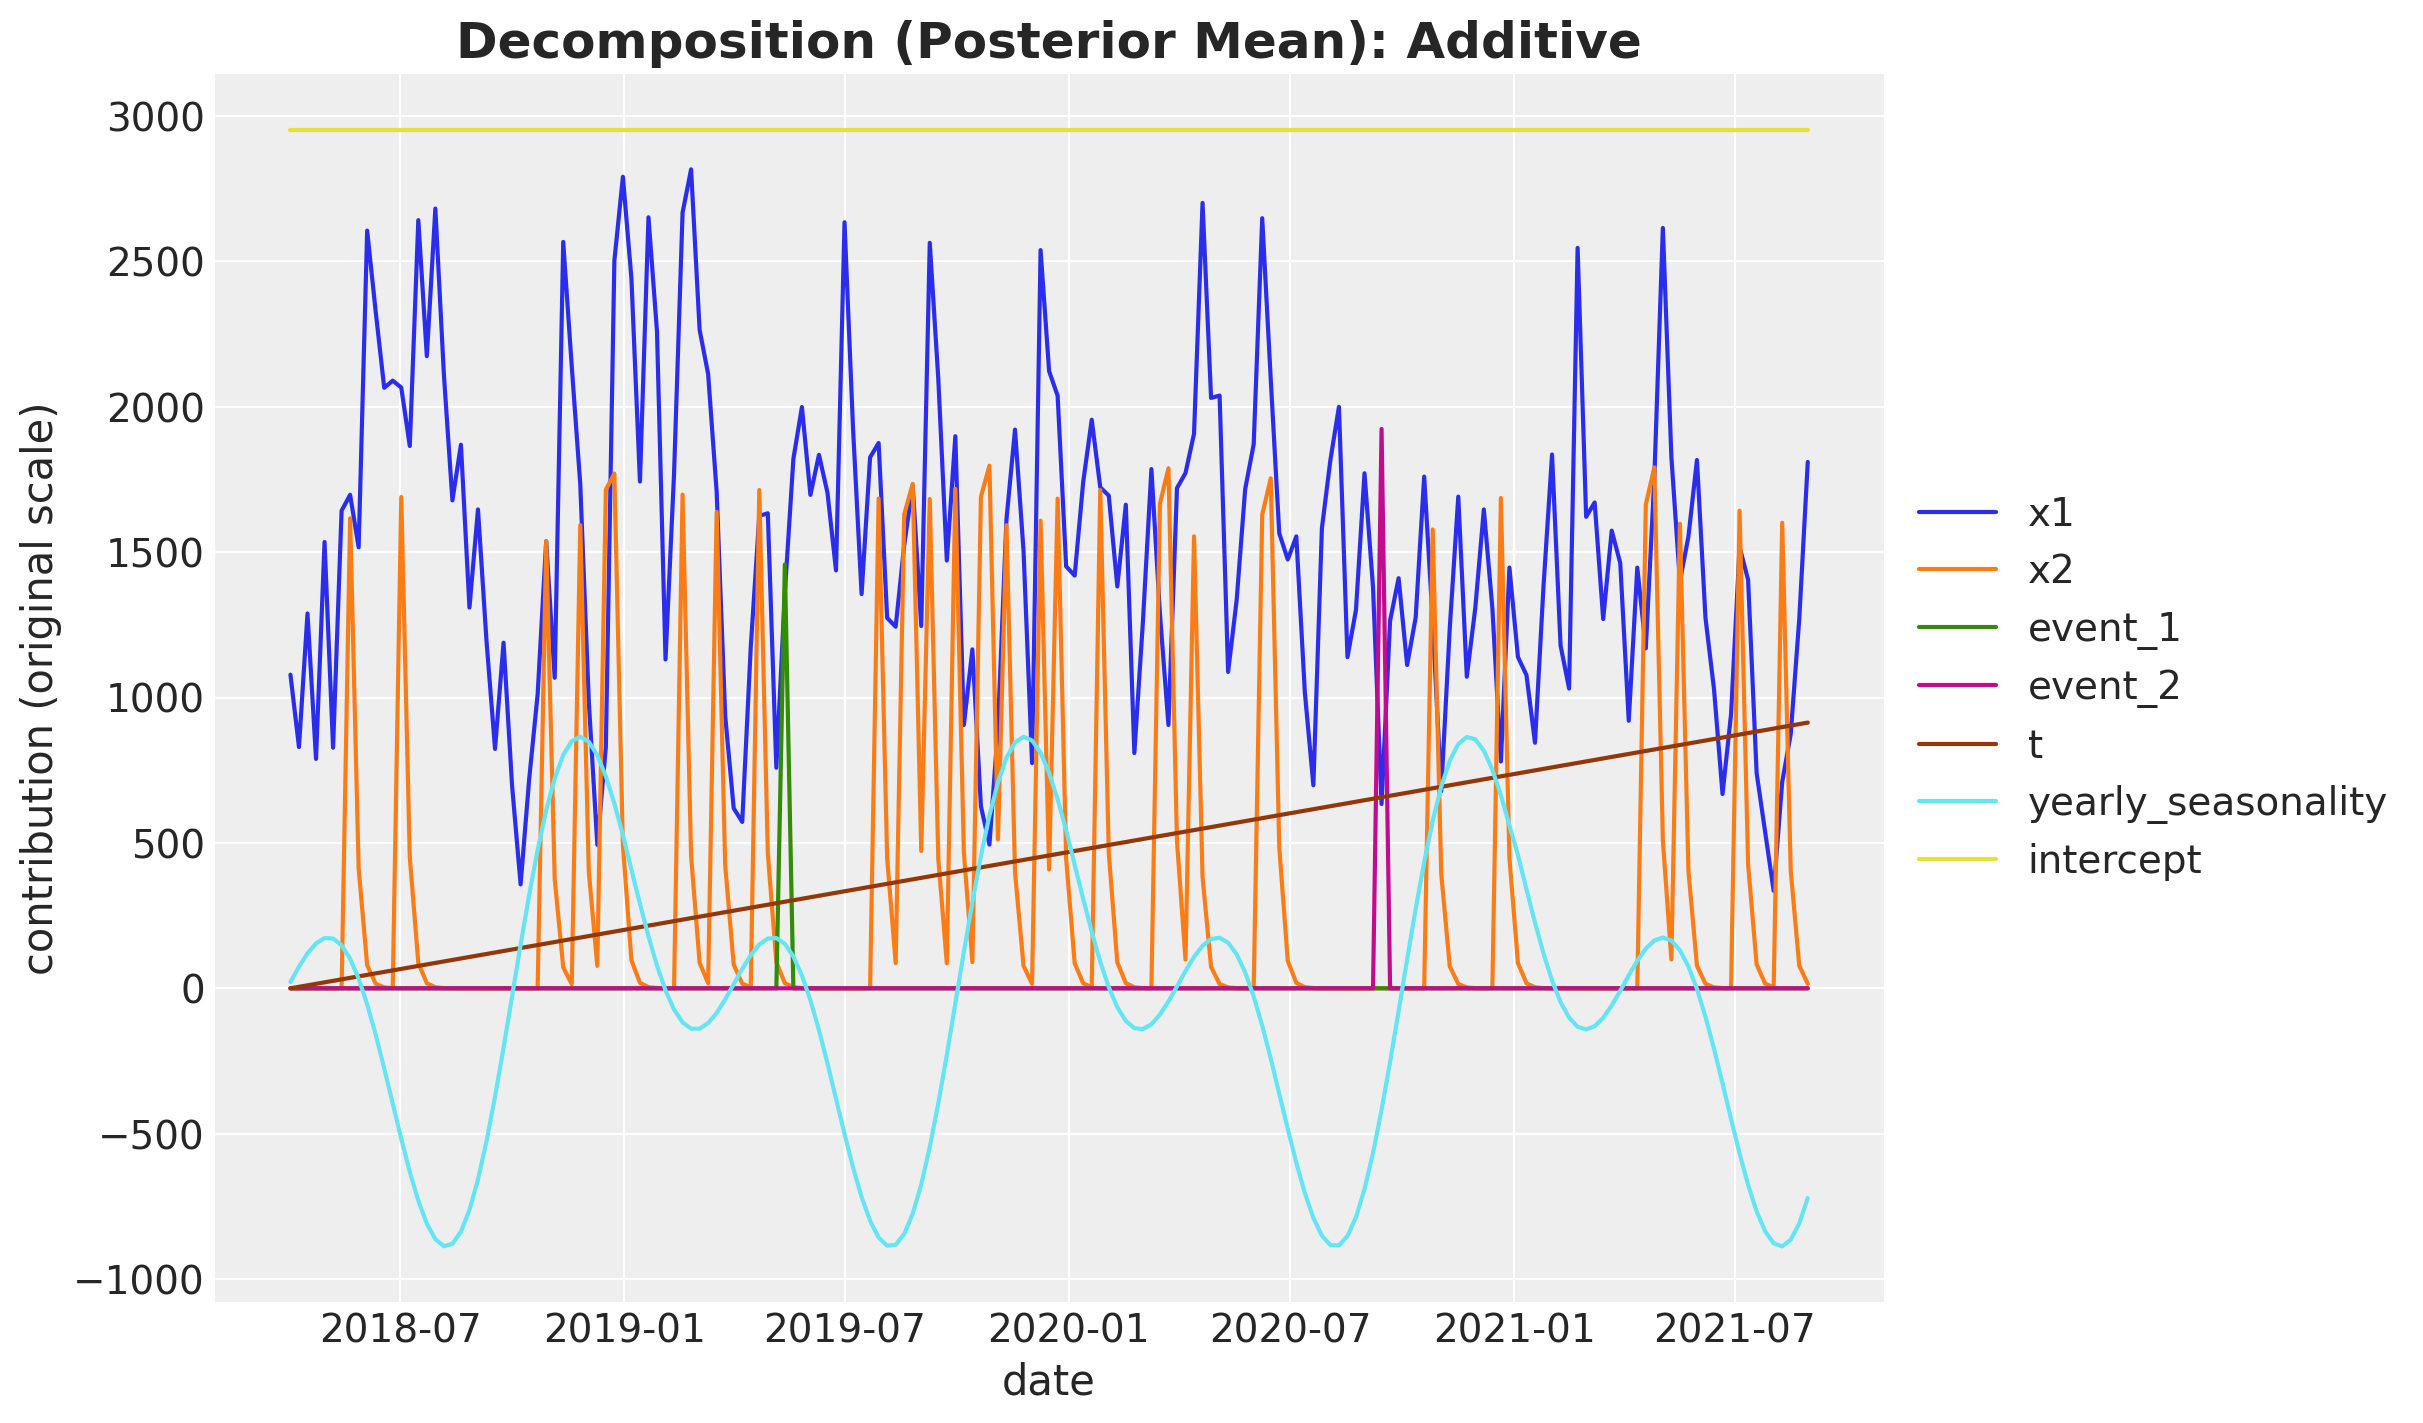

In [13]:
def plot_decomposition(contributions_df, model_name, date_col="date"):
    """Plot component contributions over time (line plot, handles mixed signs)."""
    component_cols = [c for c in contributions_df.columns if c != date_col]
    fig, ax = plt.subplots(figsize=(12, 7))
    for col in component_cols:
        ax.plot(
            contributions_df[date_col], contributions_df[col], linewidth=1.5, label=col
        )
    ax.set(
        xlabel="date",
        ylabel="contribution (original scale)",
    )
    ax.set_title(
        f"Decomposition (Posterior Mean): {model_name}", fontsize=18, fontweight="bold"
    )
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    return fig, ax


fig, ax = plot_decomposition(contributions_additive, "Additive")

The line plot shows each component's time-varying contribution in original-scale units. 

In many cases, we are not just interested in the posterior mean decomposition, but the entire distribution of contributions. We can also extract this fromt the model:

In [14]:
contributions_additive_posterior = (
    mmm_additive.compute_counterfactual_contributions_dataset()
)

contributions_additive_posterior

<xarray.Dataset> Size: 34MB
Dimensions:             (chain: 4, draw: 1000, date: 179)
Coordinates:
  * chain               (chain) int64 32B 0 1 2 3
  * draw                (draw) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
  * date                (date) datetime64[ns] 1kB 2018-04-02 ... 2021-08-30
Data variables:
    x1                  (chain, draw, date) float64 6MB 1.119e+03 ... 1.549e+03
    x2                  (chain, draw, date) float64 6MB 0.0 0.0 ... 37.44 2.952
    event_1             (chain, draw, date) float64 6MB 0.0 0.0 0.0 ... 0.0 0.0
    event_2             (chain, draw, date) float64 6MB 0.0 0.0 0.0 ... 0.0 0.0
    t                   (chain, draw, date) float64 6MB 0.0 5.878 ... 873.9
    yearly_seasonality  (chain, draw, date) float64 6MB 24.19 77.44 ... -744.5
    intercept           (chain, draw) float64 32kB 2.848e+03 ... 3.21e+03

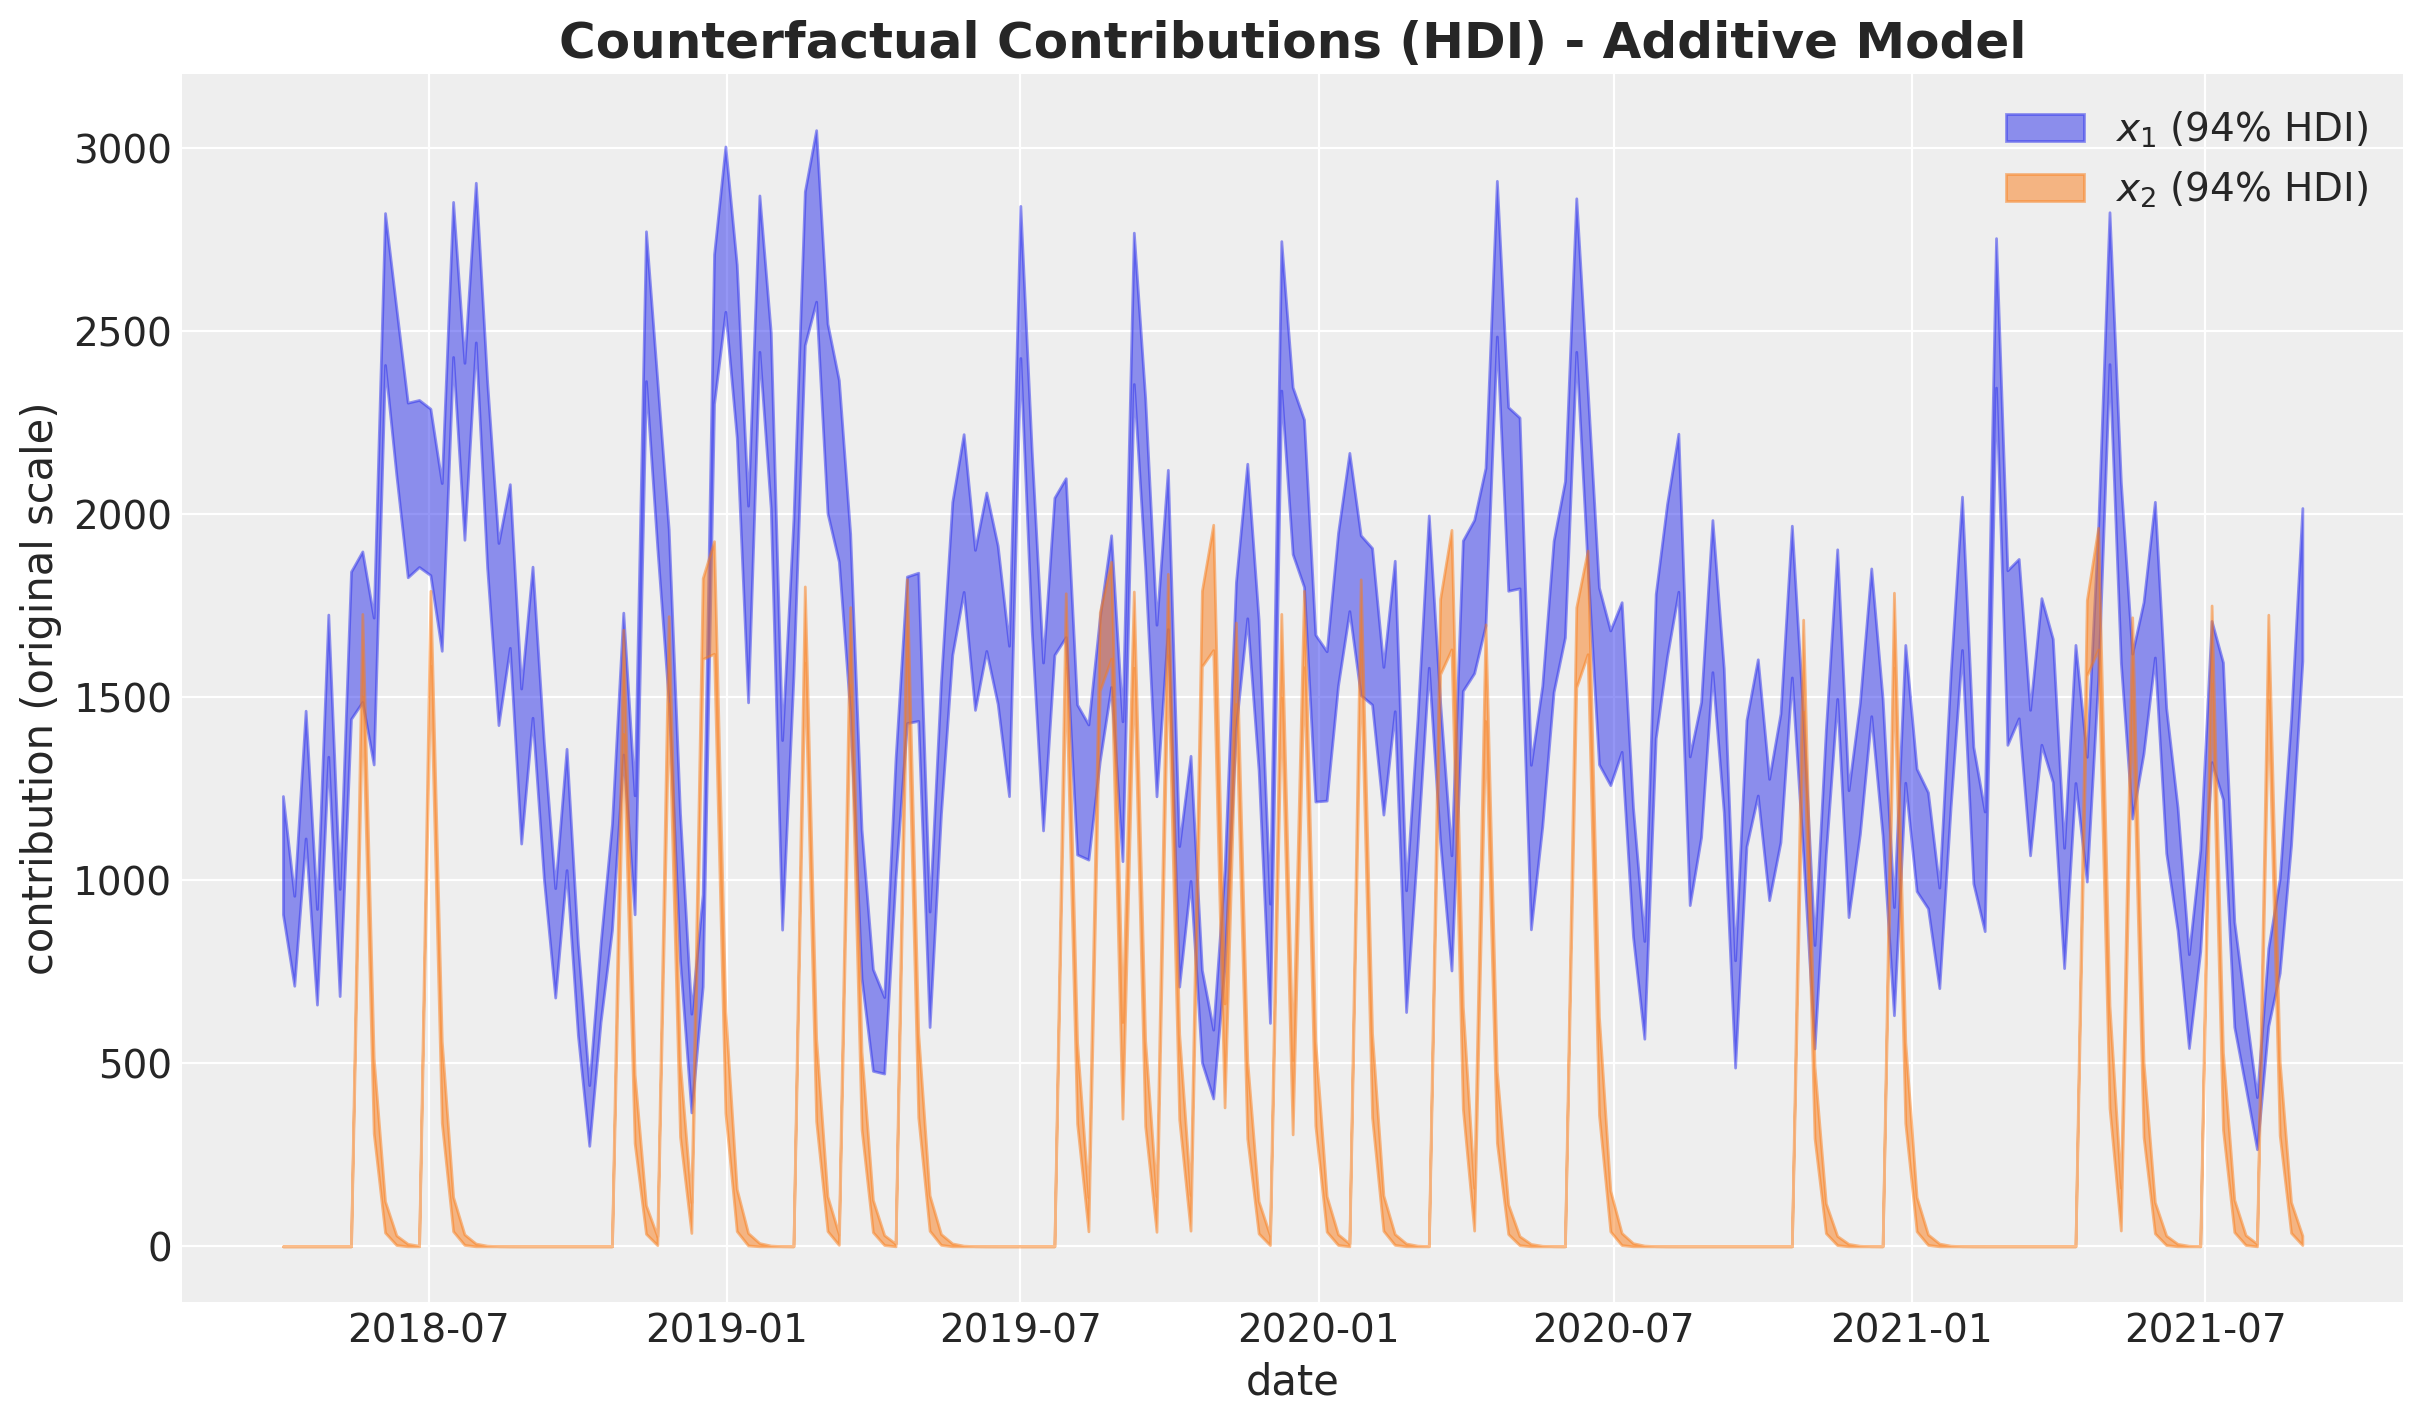

In [15]:
fig, ax = plt.subplots()

hdi = az.hdi(contributions_additive_posterior["x1"], prob=0.94)
ax.fill_between(
    contributions_additive_posterior["date"],
    hdi.sel(ci_bound="lower"),
    hdi.sel(ci_bound="upper"),
    color="C0",
    alpha=0.5,
    label=r"$x_1$ (94% HDI)",
)
hdi = az.hdi(contributions_additive_posterior["x2"], prob=0.94)
ax.fill_between(
    contributions_additive_posterior["date"],
    hdi.sel(ci_bound="lower"),
    hdi.sel(ci_bound="upper"),
    color="C1",
    alpha=0.5,
    label=r"$x_2$ (94% HDI)",
)

ax.legend(loc="upper right")
ax.set(xlabel="date", ylabel="contribution (original scale)")
ax.set_title(
    "Counterfactual Contributions (HDI) - Additive Model",
    fontsize=18,
    fontweight="bold",
);

To summarize the relative importance of the two media channels we can look at their posterior share distributions below.

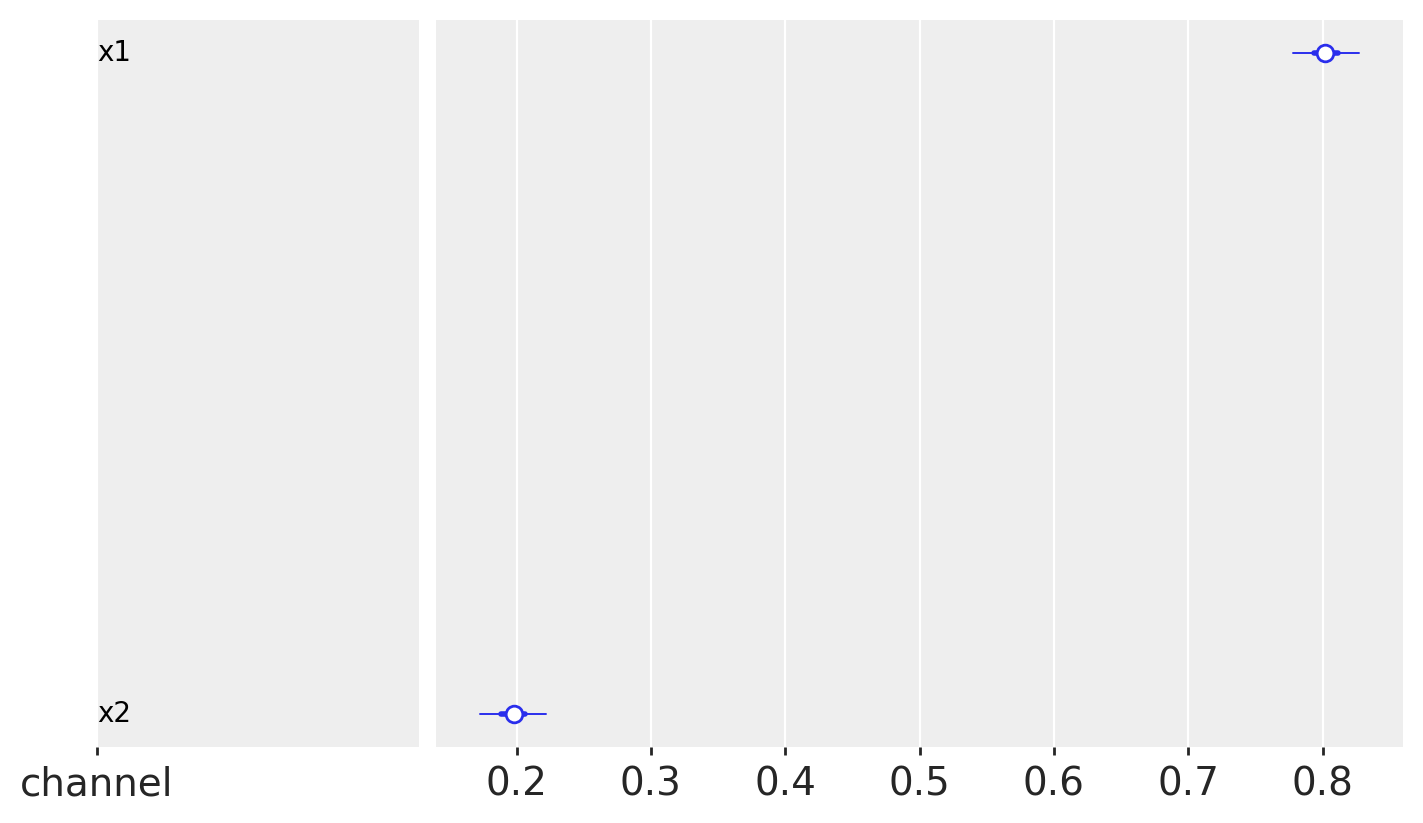

In [16]:
fig, axes = mmm_additive.plot.decomposition.channel_share_hdi(figsize=(7, 4))

Channel `x1` captures the majority of the estimated media effect, consistent with its higher spend volume. The posterior distributions are well separated, giving confidence that the model can distinguish the two channels.

## How contributions are computed (read this once)

Before fitting the log and log-log models, it is worth understanding *how* PyMC-Marketing turns a fitted model into per-component contributions, because the recipe is identical across links: only the inverse-link function changes. `compute_mean_contributions_over_time()` (and its full-posterior sibling `compute_counterfactual_contributions_dataset()`) answer one question per component: *"how much would predicted $y$ drop if we removed this component?"*

**1. The counterfactual definition.** For every component $j$ (each channel, each control, seasonality, the intercept) with log-space value $v_j(t)$ in the linear predictor $\mu(t)$, the per-draw, per-period contribution is $\text{contribution}_j(t) = \text{inv}(\mu(t)) \cdot s - \text{inv}(\mu(t) - v_j(t)) \cdot s$, where $\text{inv}$ is the inverse link ($\text{identity}$ or $\exp$) and $s$ is `target_scale`. We zero out the component inside $\mu$, re-apply the inverse link, and measure the drop on the original scale.

**2. Why a counterfactual and not a direct split?** In a multiplicative model the components are *added* inside $\mu$ but *multiplied* on the $y$-scale ($y = \prod_c \exp(v_c)$). There is no additive term on the $y$-scale to read off as "channel $c$'s sales", so the only honest way to attribute sales is to ask what $y$ would have been without $c$. The counterfactual is exactly that question.

**3. The identity link is the special case.** When $\text{inv} = \text{identity}$, the formula collapses to $\text{contribution}_j(t) = v_j(t) \cdot s$, the familiar additive decomposition. That is why identity-link contributions partition $\hat y(t)$ exactly (they sum to $\hat y$), while log-link contributions do not.

**4. What it costs under the log link.** Because each component's counterfactual absorbs its share of every interaction it participates in, per-component contributions *overlap*: their sum exceeds $\hat y(t)$. This is a property of asking a per-component "what-if" question in a non-linear model, not a bug. Each value is individually correct (*"removing X costs this much"*); they simply cannot be stacked into an exact pie chart.

The two models below put this recipe into practice. See the API docs for `compute_counterfactual_contributions_dataset` for the formal statement and the full-posterior (credible-interval-preserving) form.

## Model 2: Log (Multiplicative)

With `link="log"`, the linear predictor $\mu$ is the same additive combination, but each component becomes a **multiplicative factor** on $y$ via $\exp(\cdot)$:

$$
y = \exp(\text{intercept}) \times \prod_c \exp(\text{saturation}_c(\text{adstock}_c(x_c))) \times \ldots
$$

The likelihood is `LogNormal`, so $\log(y_{\text{scaled}}) \sim \text{Normal}(\mu, \sigma)$.

**Note on trend**: We use `t_norm` (normalized to $[0, 1]$) instead of the raw integer `t` to avoid exponential blow-up. The coefficient $\gamma_t$ now represents the total log-scale trend over the observation period, and $\exp(\gamma_t)$ is the multiplicative factor from start to end.



In [17]:
# --- Log / log-log model config ---
# The link="log" defaults handle intercept (Normal(0, 5)) and likelihood
# (LogNormal(sigma=HalfNormal(0.5))). We override saturation_beta,
# gamma_control (wider for [0,1]-scaled trend), and gamma_fourier.
log_model_config = {
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=0.5, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
}

mmm_log = MMM(
    model_config=log_model_config,
    target_column="y",
    date_column="date_week",
    channel_columns=CHANNELS,
    control_columns=CONTROL_COLUMNS_LOG,
    yearly_seasonality=2,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    link="log",
)

mmm_log.build_model(X_log, y)
mmm_log.table()

                                  Variable  Expression                                 Dimensions                  
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                           channel_scale =  Data                                       channel[2]                  
                            target_scale =  Data                                                                   
                            channel_data =  Data                                       date[179] × channel[2]      
                             target_data =  Data                                       date[179]                   
                            control_data =  Data                                       date[179] × control[3]      
                               dayofyear =  Data                                       date[179]                   
                                                                                                                   
                  intercept_contribution ~  Normal(0, 5)                                                           
                           adstock_alpha ~  Beta(1, 3)                                 channel[2]                  
                          saturation_lam ~  Gamma(3, <constant>)                       channel[2]                  
                         saturation_beta ~  HalfNormal(0, <constant>)                  channel[2]                  
                           gamma_control ~  Normal(0, 0.5)                             control[3]                  
                           gamma_fourier ~  Laplace(0, 0.2)                            fourier_mode[4]             
                                 y_sigma ~  HalfNormal(0, 0.5)                                                     
                                                                                       Parameter count = 15        
                                                                                                                   
                    channel_contribution =  f(saturation_beta, saturation_lam,         date[179] × channel[2]      
                                            adstock_alpha)                                                         
                    control_contribution =  f(gamma_control)                           date[179] × control[3]      
                    fourier_contribution =  f(gamma_fourier)                           date[179] × fourier_mode[4] 
         yearly_seasonality_contribution =  f(gamma_fourier)                           date[179]                   
                                      mu =  f(intercept_contribution, gamma_fourier,   date[179]                   
                                            gamma_control, saturation_beta,                                        
                                            saturation_lam, adstock_alpha)                                         
 total_media_contribution_original_scale =  f(intercept_contribution,                                              
                                            saturation_beta, gamma_fourier,                                        
                                            gamma_control, saturation_lam,                                         
                                            adstock_alpha)                                                         
                        y_original_scale =  f(intercept_contribution, gamma_fourier,   date[179]                   
                                            gamma_control, saturation_beta,                                        
                                            saturation_lam, adstock_alpha)                                         
                                                                                                                   
                                       y ~  LogNormal(f(

In [18]:
_ = mmm_log.fit(X=X_log, y=y, **fit_kwargs)

NUTS[nutpie]: [gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, y_sigma]


Output()

Output()

Sampling complete. We check traces and divergences before proceeding.

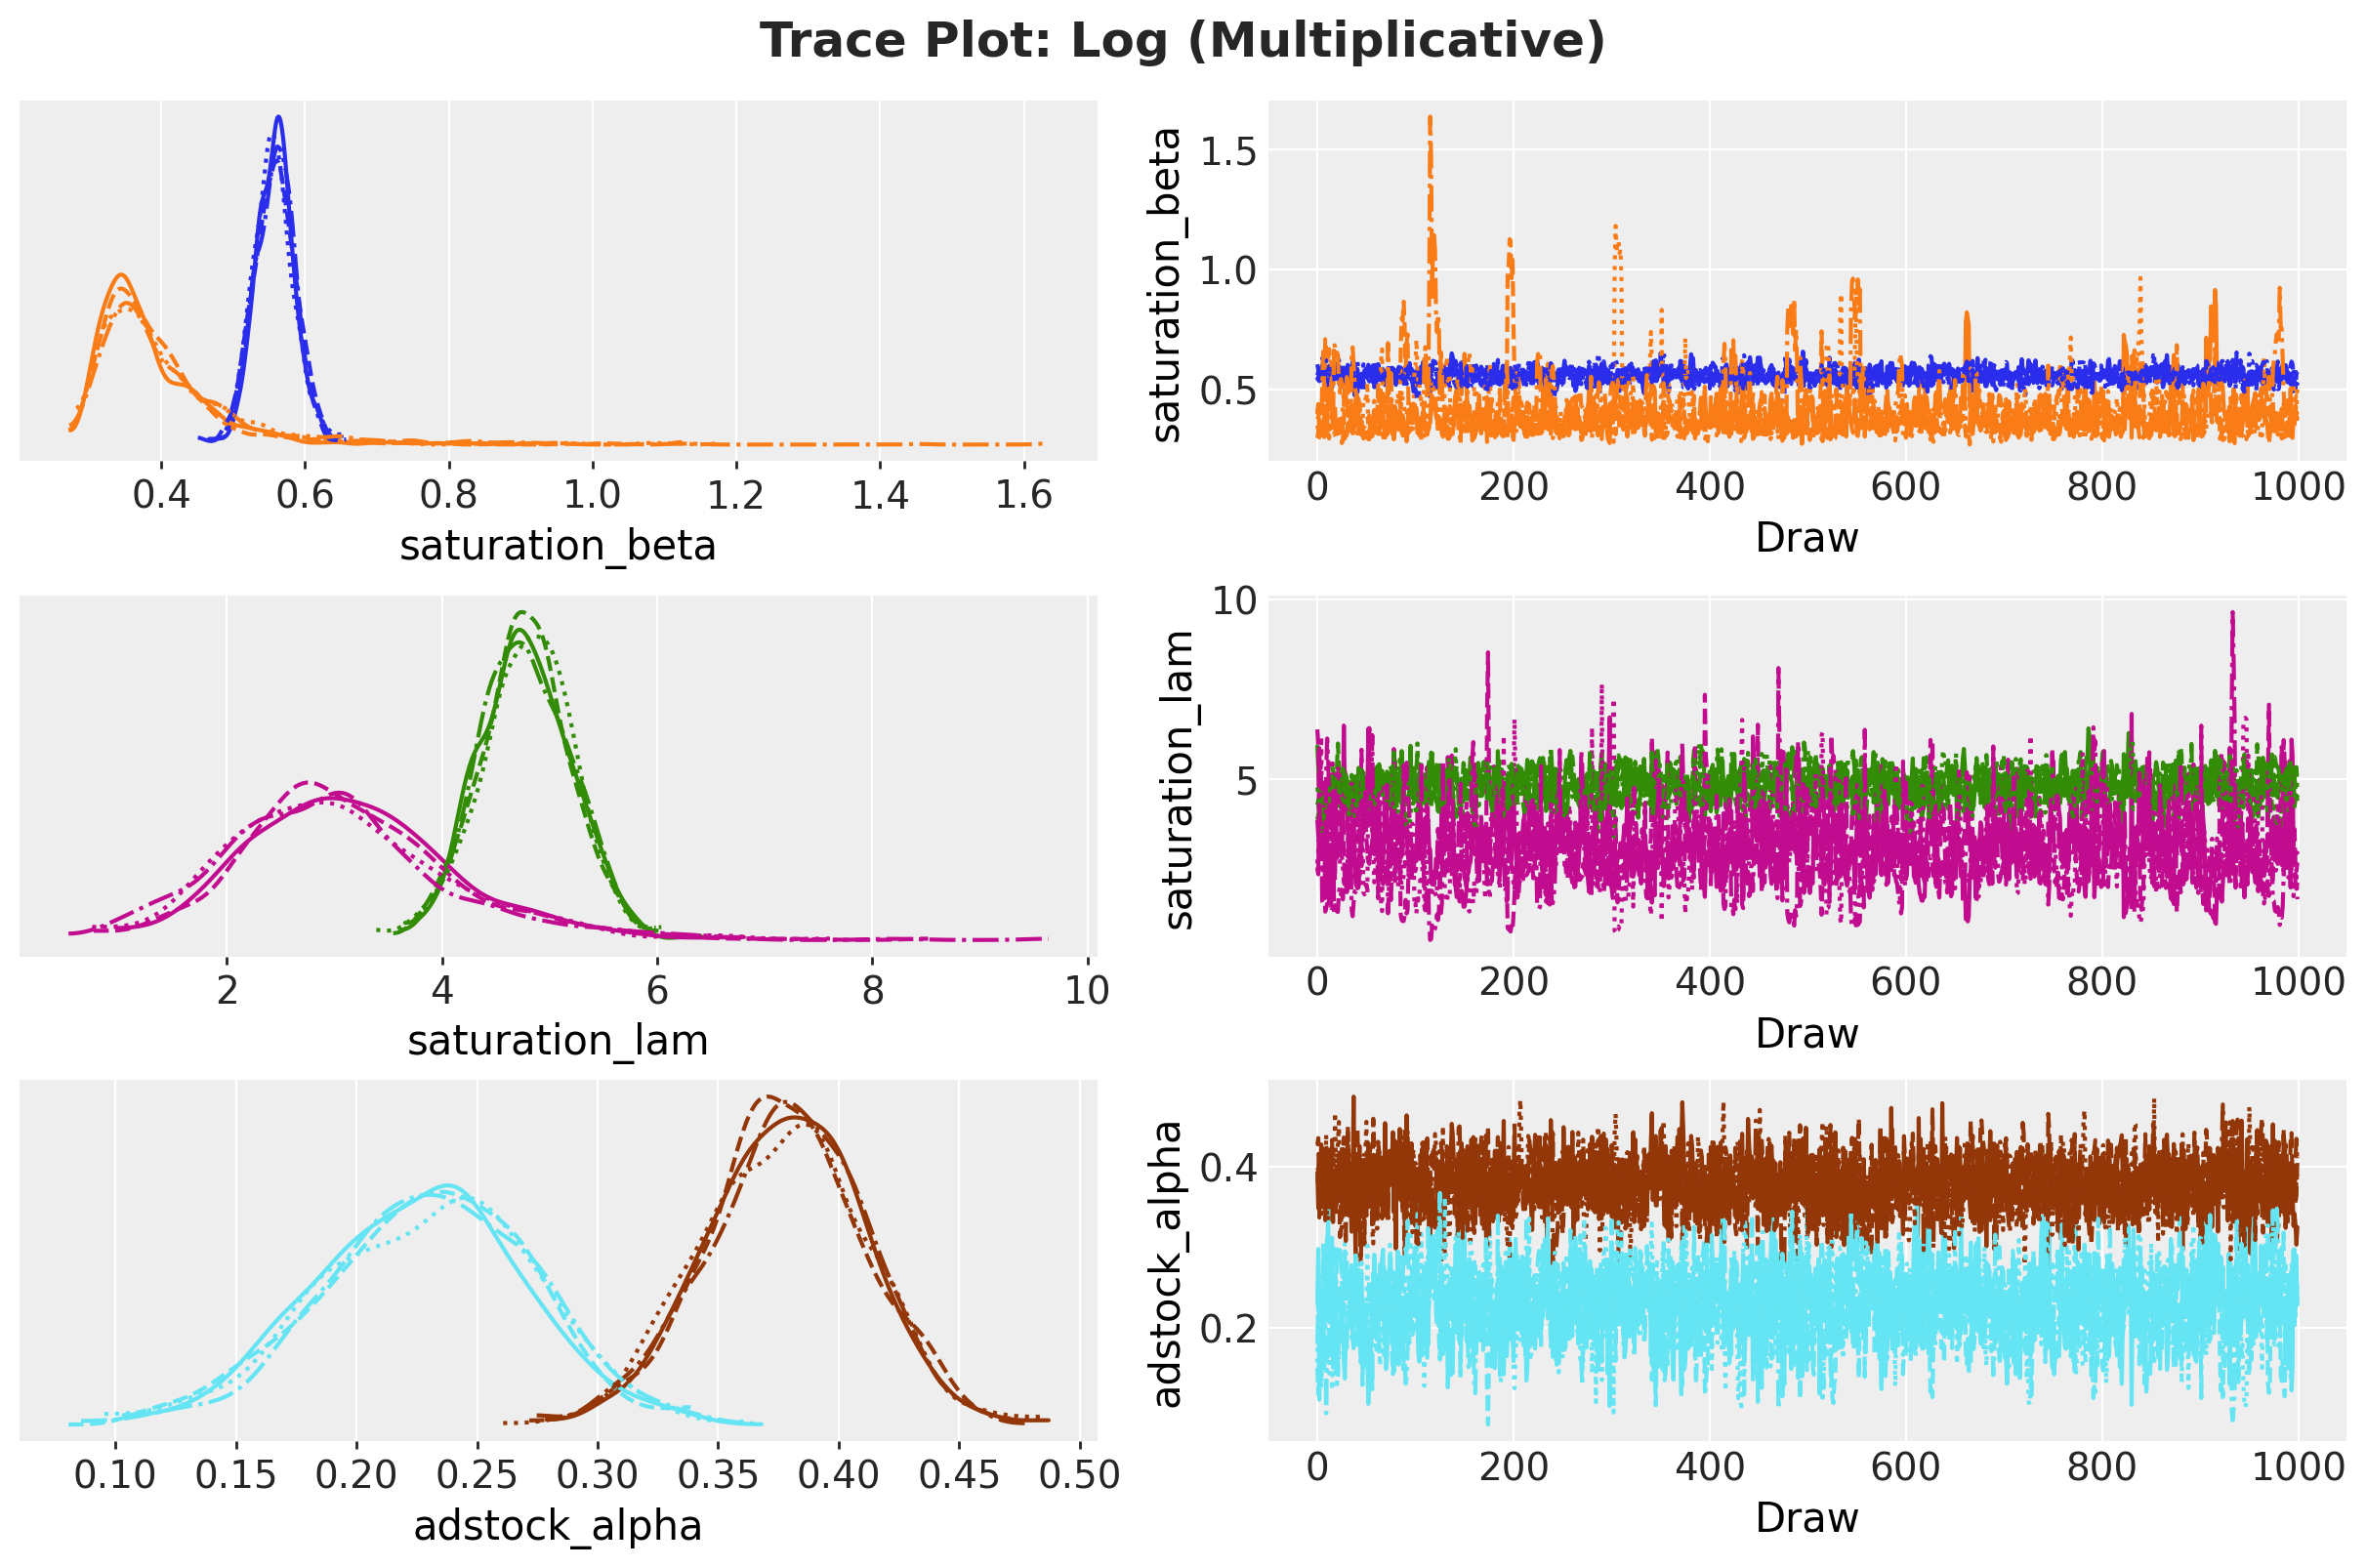

In [19]:
plot_trace_dist(
    mmm_log,
    model_name="Log (Multiplicative)",
    var_names=TRACE_VAR_NAMES,
)

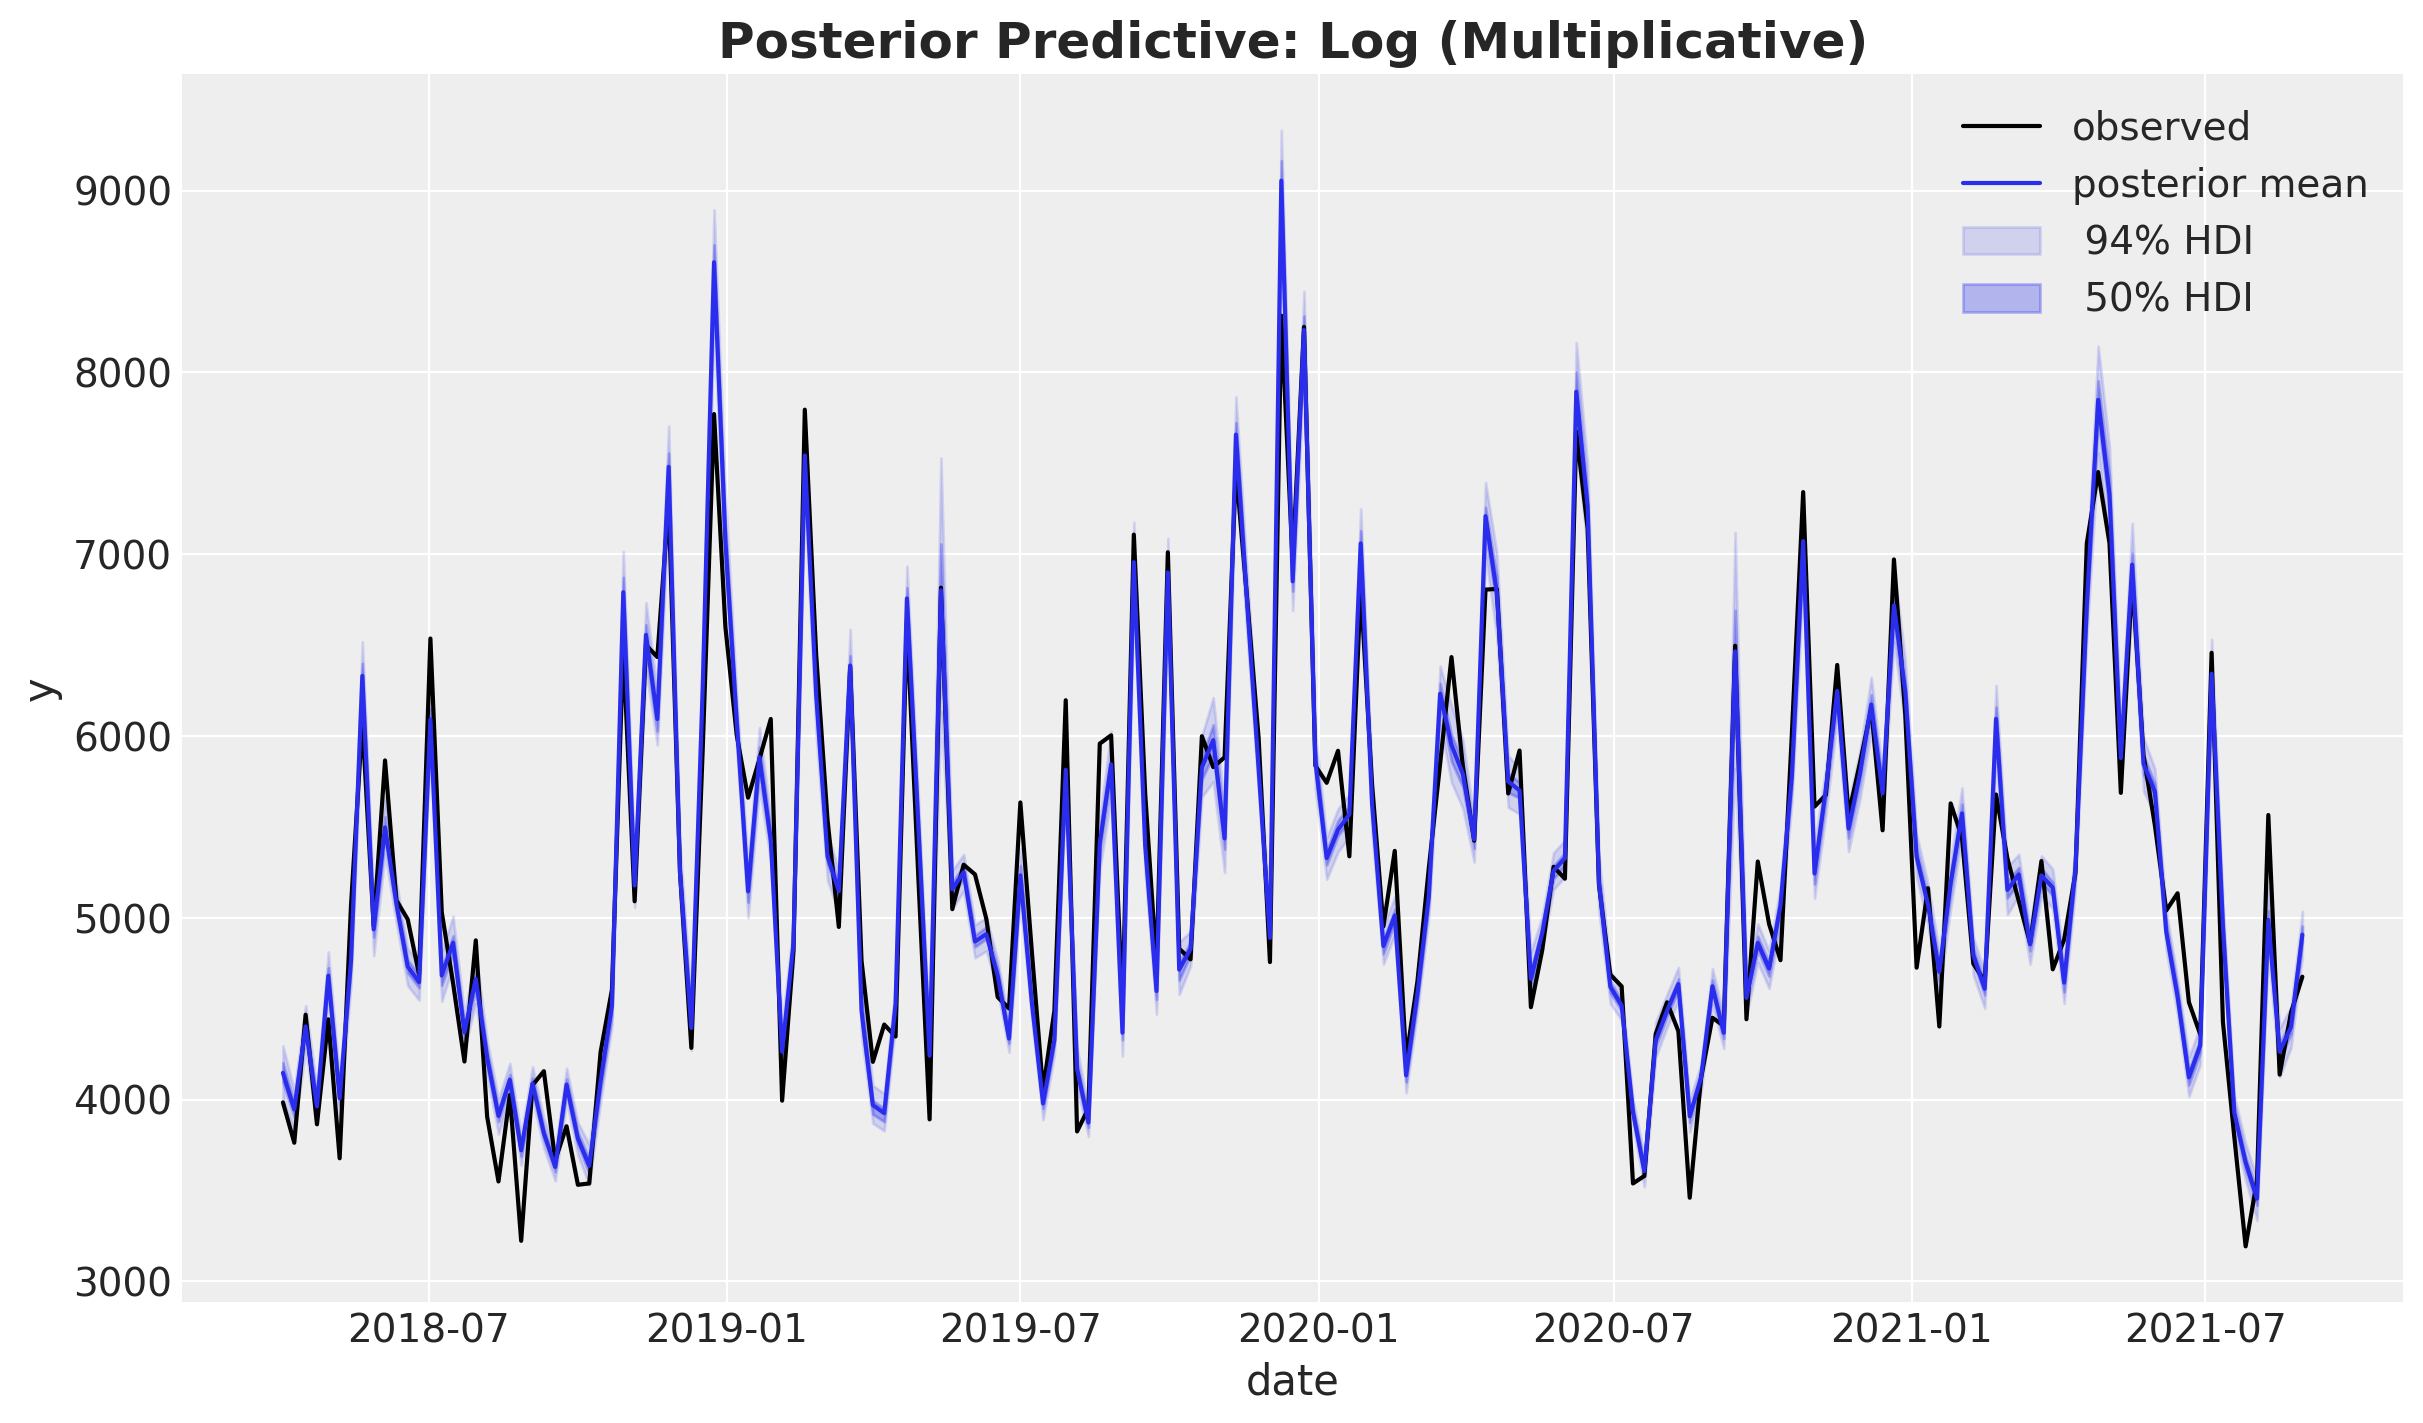

In [20]:
fig, ax = plot_posterior_predictive(mmm_log, model_name="Log (Multiplicative)", y_obs=y)

The log model's posterior predictive fit is comparable to the additive model. Because the data was generated additively, both specifications can approximate it well; the log-link simply re-expresses the same pattern through an exponential transformation.

### Decomposing contributions in a multiplicative model

**The business question:** *"How much of my weekly sales came from TV, from search, from seasonality, from baseline demand?"*

For the additive model each term already answered this in the same units as sales. For a log-link model the components *multiply* each other's effects (they are exponents inside `exp(·)`), so no single component has a direct dollar interpretation on its own.

`compute_mean_contributions_over_time()` uses the same **unified counterfactual decomposition** as for the additive model. For each component $j$ with log-space value $v_j(t)$:

$$
\text{contribution}_j(t)
= \mathbb{E}\Bigl[\; \underbrace{\exp(\mu(t)) \cdot s}_{\hat y(t)} \;-\; \underbrace{\exp\!\bigl(\mu(t) - v_j(t)\bigr) \cdot s}_{\hat y_{\text{without } j}(t)} \;\Bigr]
$$

Note that the difference is taken **inside** the expectation (per posterior draw) and only then averaged. By linearity of expectation the posterior *mean* equals $\mathbb{E}[\exp(\mu)\cdot s] - \mathbb{E}[\exp(\mu - v_j)\cdot s]$, so either form gives the same point estimate, but only the per-draw form yields correct credible intervals, which is why `compute_counterfactual_contributions_dataset()` keeps the full `(chain, draw)` posterior.

*Business reading:* each column answers **"if we removed this component entirely, how much would predicted sales drop?"**, a genuine counterfactual question.

**Why columns do not sum to $\hat y(t)$**

In a multiplicative model, components interact: removing channel A reduces the *multiplicative base* that channel B amplifies, and vice versa. Each component's counterfactual captures its own effect **plus its share of every interaction it participates in**. When you add all per-component counterfactuals together, the shared interactions are counted more than once, so the sum exceeds $\hat y(t)$.

This is an inherent property of per-component counterfactuals in any non-linear model and is **not a defect**. It simply means you cannot stack these contributions into an exact partition of $\hat y(t)$. Instead, interpret each component on its own terms: *"removing X would cost us this much."*

In [21]:
contributions_log = mmm_log.compute_mean_contributions_over_time()
contributions_log.head()

,date,x1,x2,event_1,event_2,t_norm,yearly_seasonality,intercept
0,2018-04-02,903.890411,0.0,0.0,0.0,0.000000,37.672140,-6582.938495
1,2018-04-09,667.900827,0.0,0.0,0.0,3.920761,73.913118,-6264.222755
2,2018-04-16,1092.699456,0.0,0.0,0.0,8.743834,119.336730,-6989.791189
3,2018-04-23,627.904253,0.0,0.0,0.0,11.799278,131.813969,-6289.862887
4,2018-04-30,1333.325529,0.0,0.0,0.0,18.578771,170.299487,-7433.477764


### How to read the decomposition plot

Each line shows one component's **counterfactual contribution** in original-scale units (the same units as $y$, e.g. dollars, revenue, conversions). It answers: *"if we removed this component, how much would predicted sales decrease?"*

- **Media channels** (x1, x2): the incremental sales lift from each channel. These fluctuate with spend patterns and are typically non-negative. They answer *"how many extra sales did this channel drive each week?"*
- **Controls** (events, trend): the dollar impact of external factors. Event contributions spike on event dates; trend captures the long-run direction.
- **Seasonality**: the cyclic pattern in sales attributed to time-of-year effects.

**Why the intercept looks different from the additive model**

In an additive model the intercept represents a fixed baseline level of sales: it is flat over time and always positive.

In a multiplicative (log-link) model the intercept enters as $e^{\alpha}$ and combines with media, controls, and seasonality through multiplication, not addition. There is no portion of $y$ that the intercept "owns" the way it does in an additive model; instead it sets the log-baseline against which every other component multiplies. When the other components together already explain most of $y$, the intercept's posterior centres below zero ($\alpha < 0$), because $e^{\alpha} < 1$ is the multiplicative correction the model needs.

The counterfactual question *"what if we removed the intercept?"* therefore has a counter-intuitive answer: removing a dampening factor would *increase* predicted sales, which is why the intercept contribution can be negative in the plot. Its temporal variation comes from the fact that the counterfactual scales with total predicted sales, approximately:

$$
\text{contribution}_{\text{intercept}}(t) \approx \hat y(t) \cdot (1 - e^{-\alpha})
$$

When $\hat y(t)$ is high the dampening effect is large in absolute terms, so the intercept line mirrors the shape of total sales (including seasonality and media spikes), just flipped and scaled.

This is not a modeling defect. It reflects the algebraic fact that in a multiplicative model no single component can be interpreted as a stand-alone baseline; the intercept simply sets the log-scale level that every other component multiplies.

**The non-summing property**

Unlike the additive model, summing all lines at a given date will give a total **greater than** $\hat y(t)$. This is expected: in a multiplicative model each component amplifies the others, and those shared interaction effects are counted in every component's counterfactual. Think of it as overlapping credit rather than a partitioning error. Each component's value is individually correct: *"removing X costs us this much"*, even though the values cannot be stacked into an exact pie chart of $\hat y(t)$.

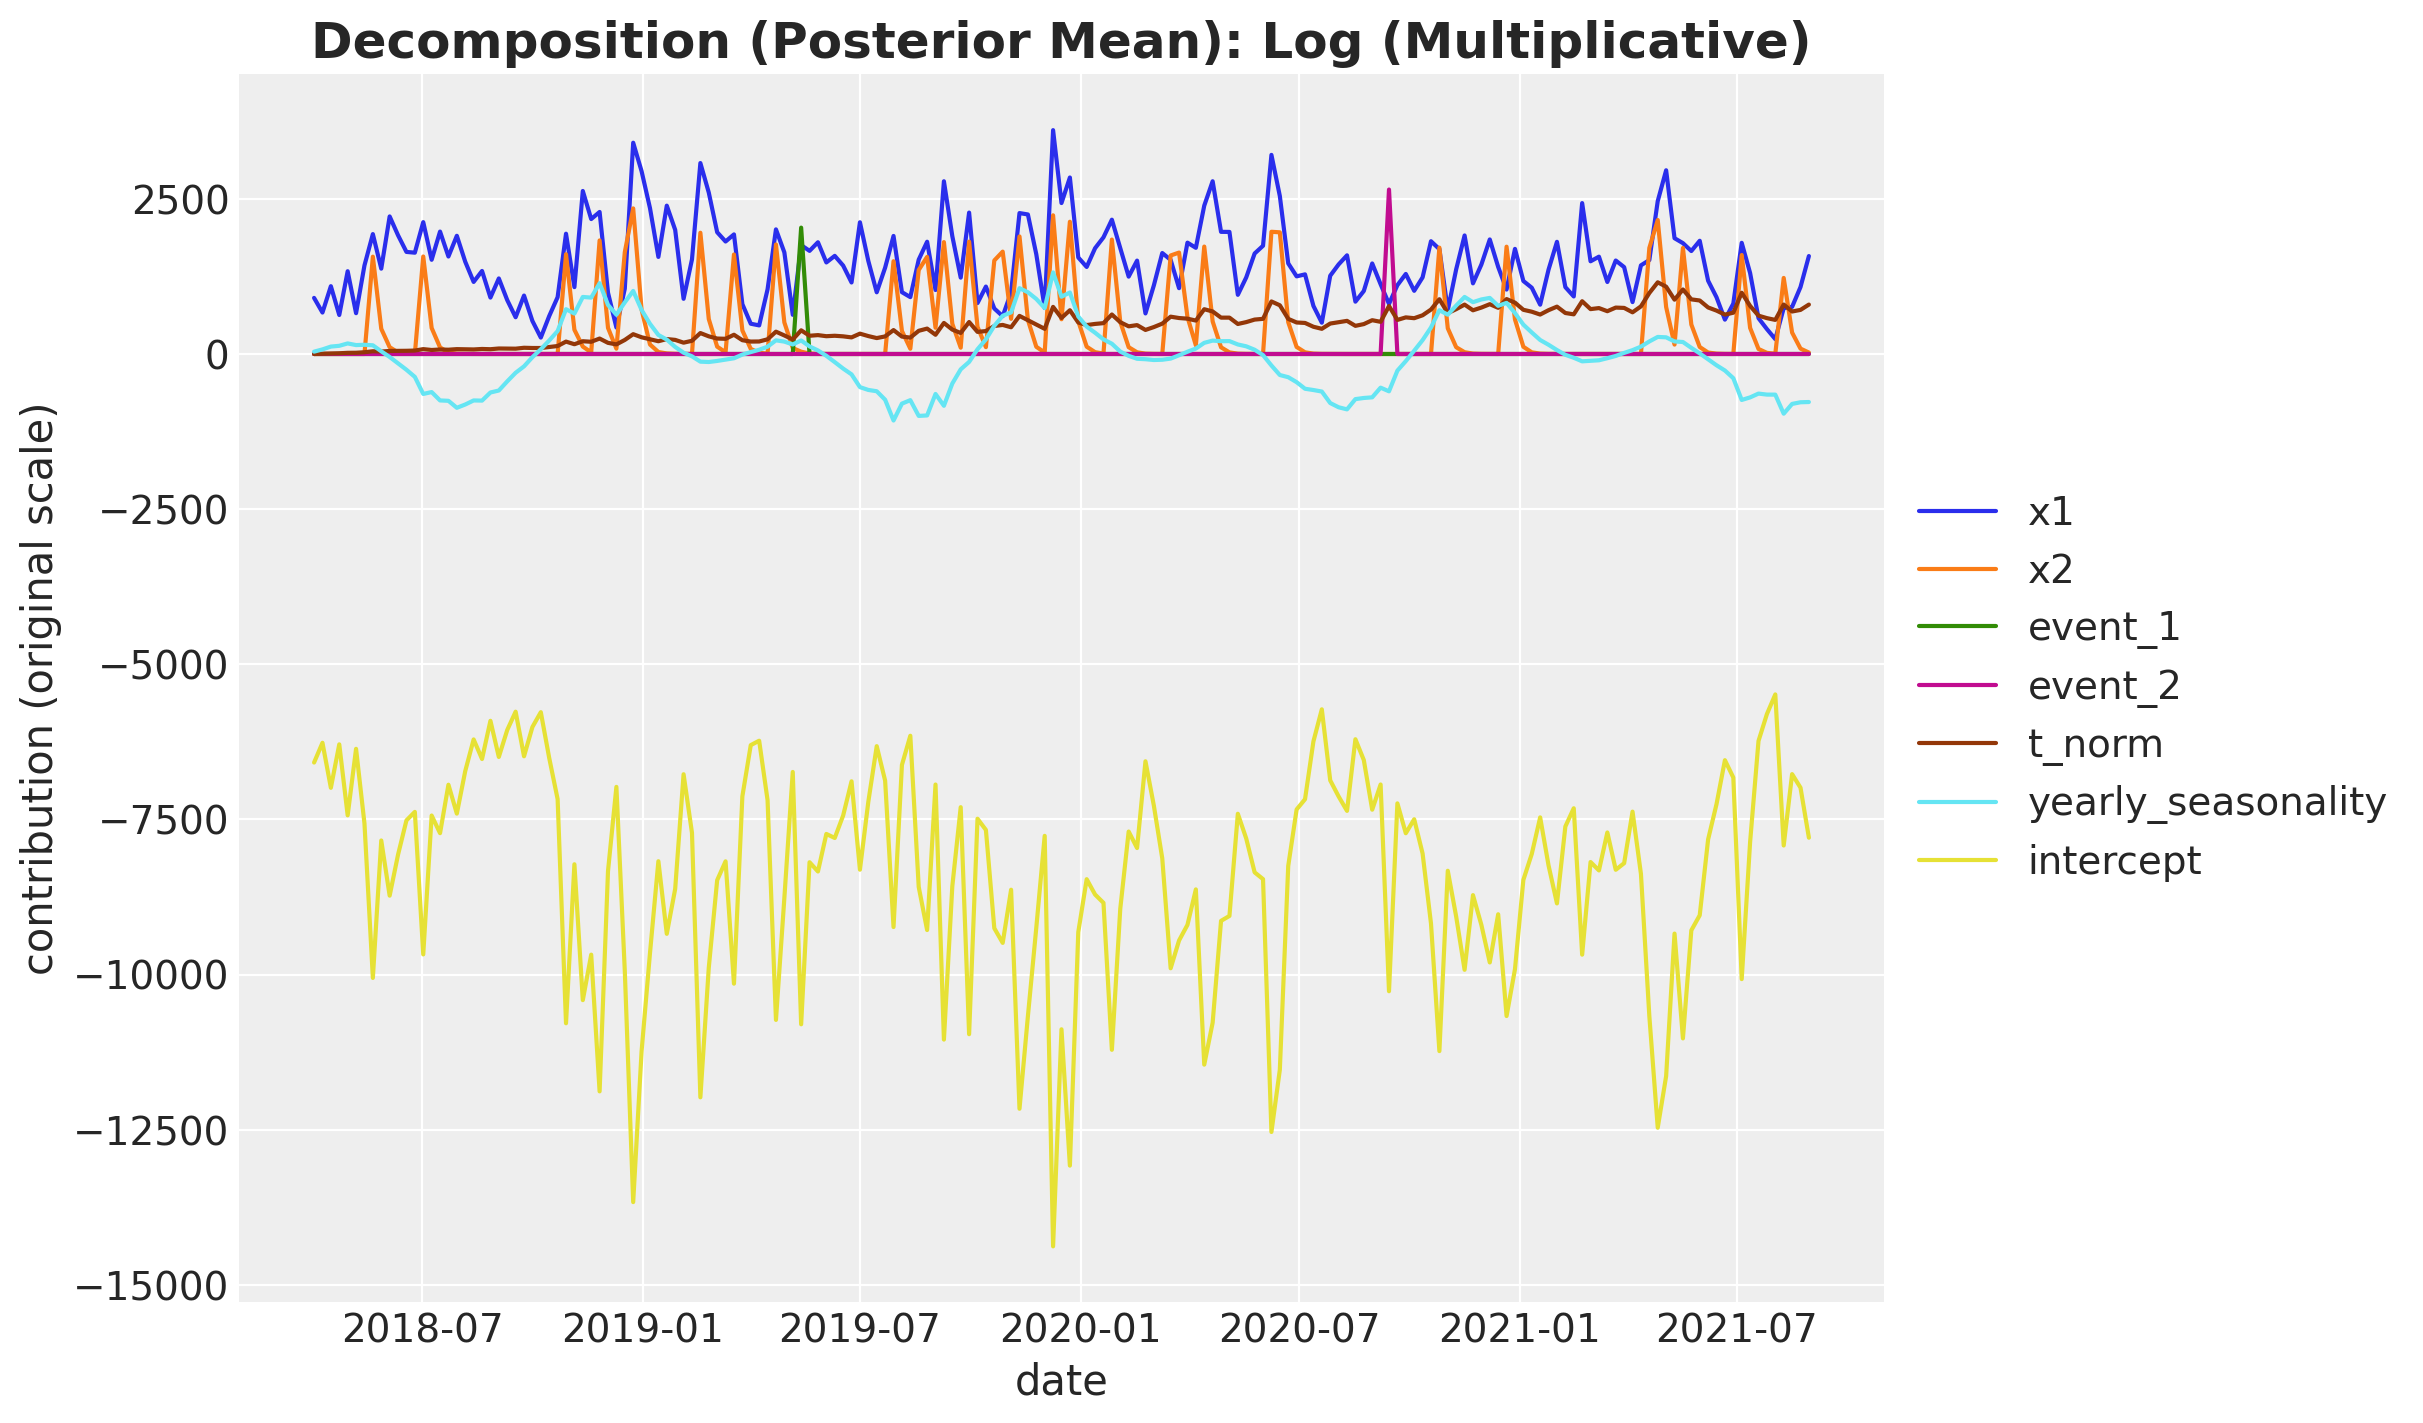

In [22]:
fig, ax = plot_decomposition(contributions_log, model_name="Log (Multiplicative)")

The intercept's large dampening contribution dominates the y-axis and compresses the other lines. Dropping it makes the channel and control contributions easier to compare.

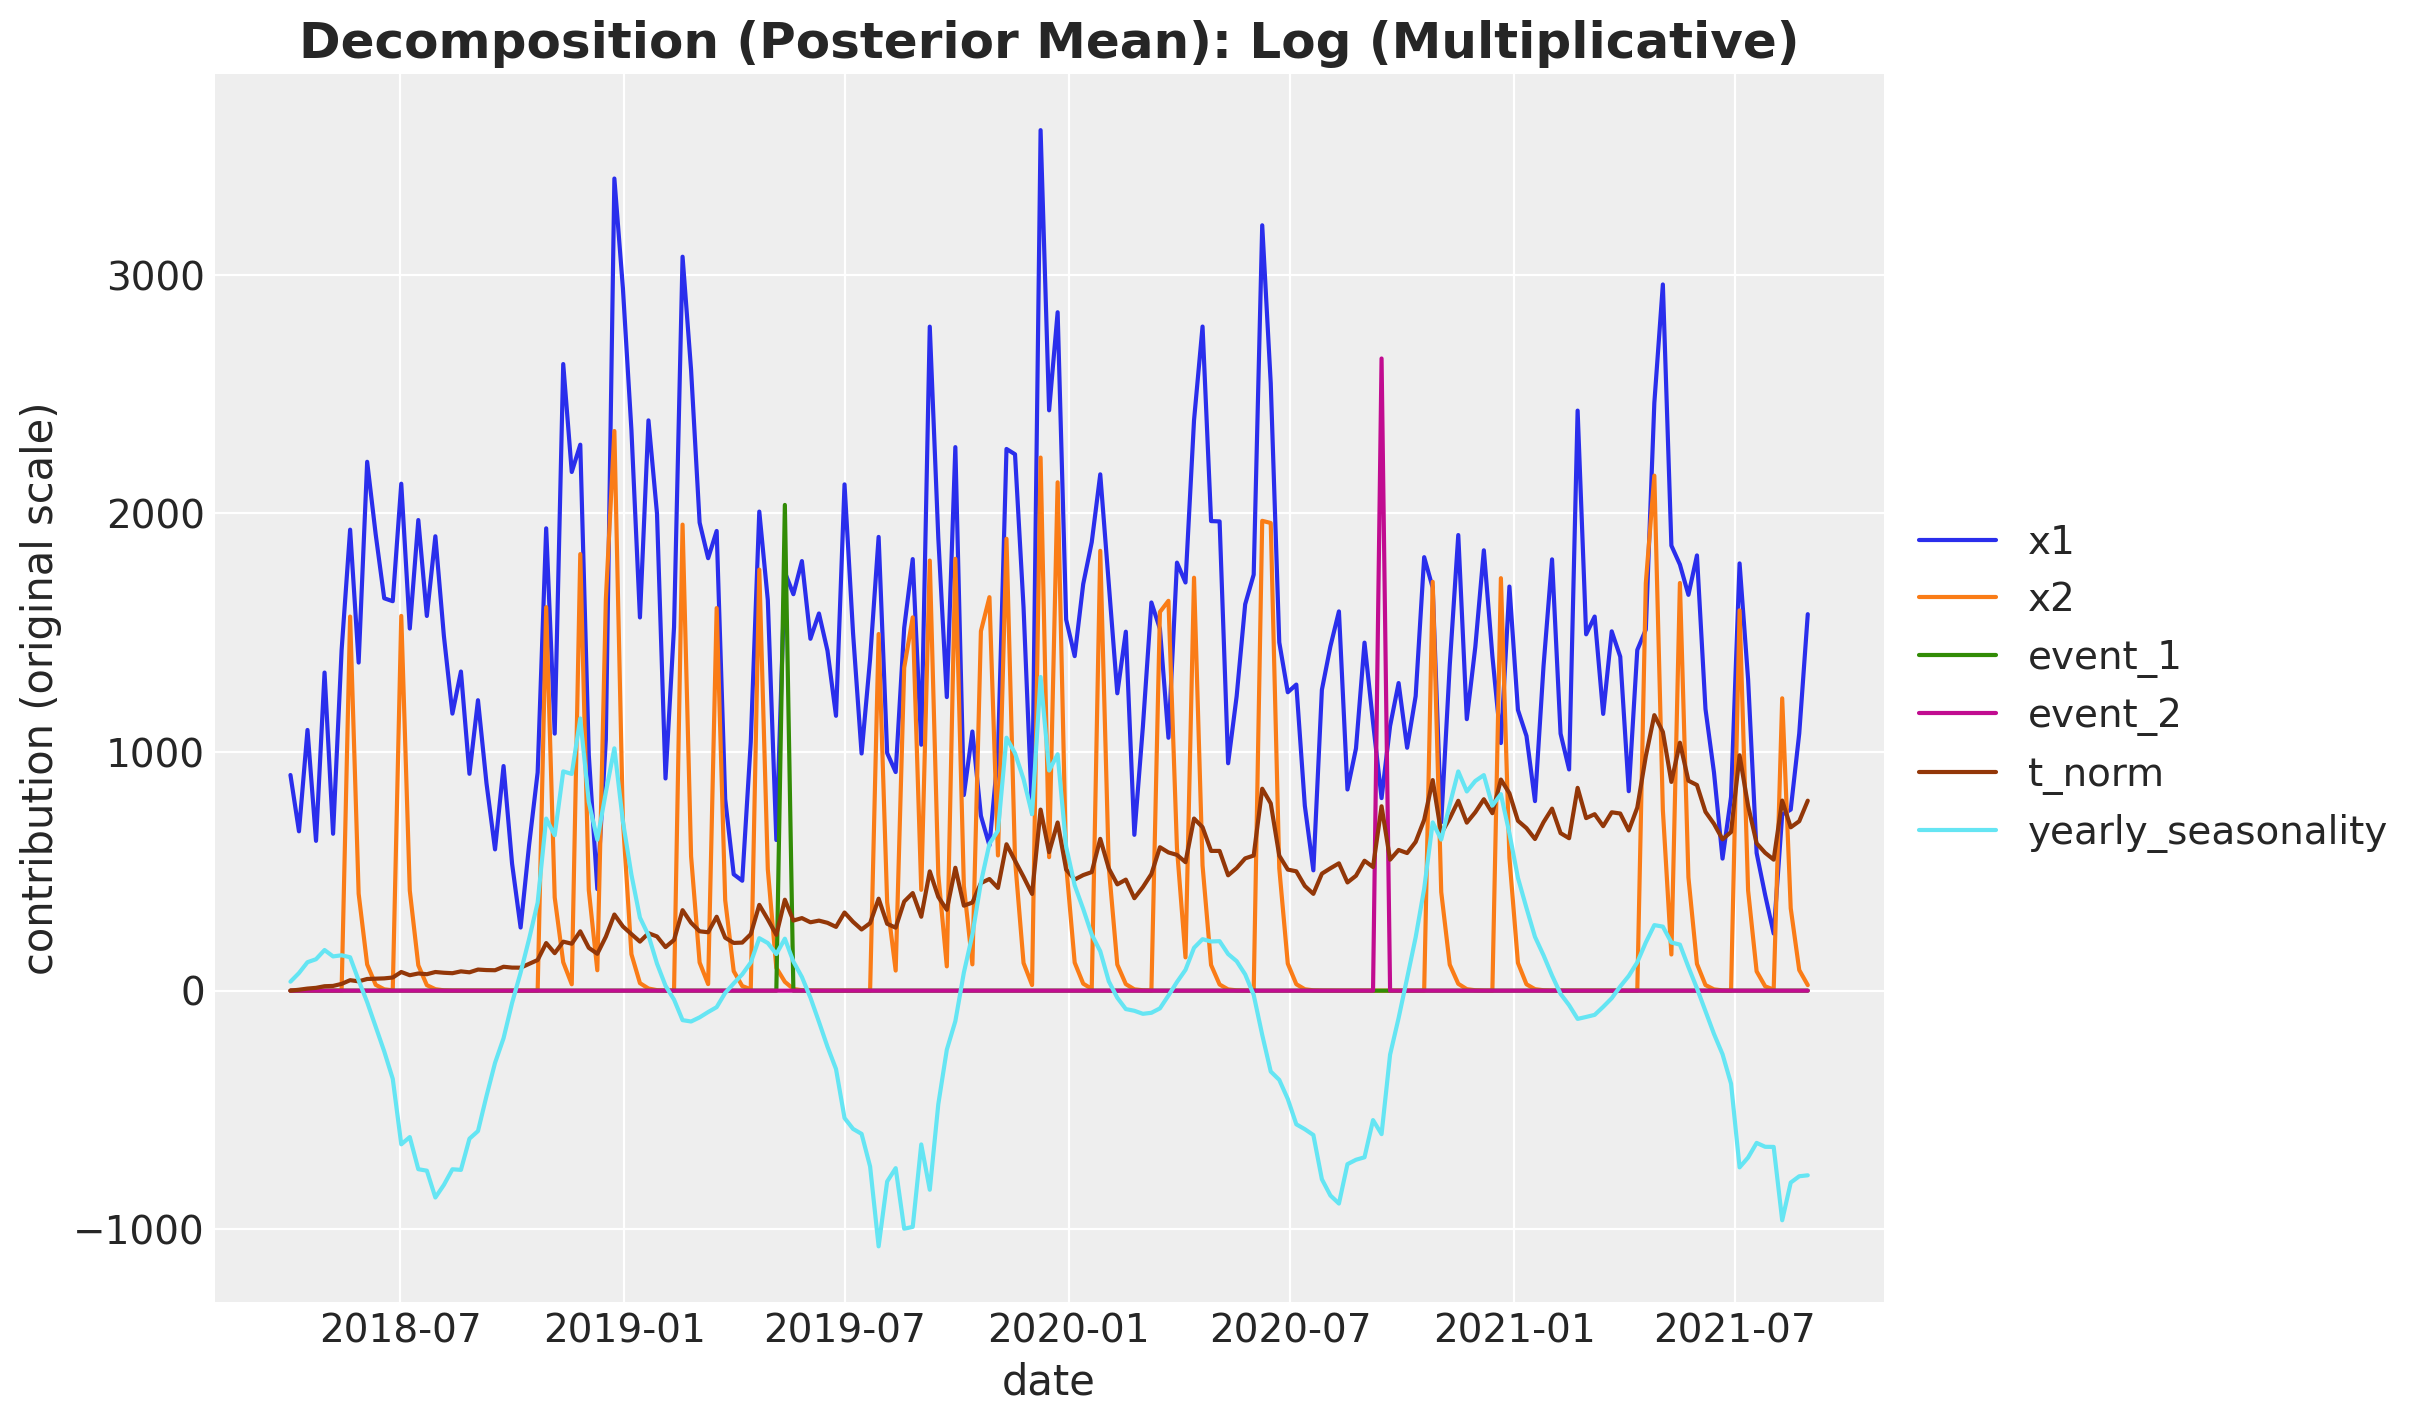

In [23]:
fig, ax = plot_decomposition(
    contributions_log.drop(columns=["intercept"]), model_name="Log (Multiplicative)"
)

This plot looks much closer to the additive model's decomposition.

## Model 3: Log-Log

The log-log model combines `link="log"` with `LogSaturation`, which applies $\beta \log(1 + x)$ instead of a sigmoidal curve, so both the response and spend enter on a log scale:

$$\log(y) \sim \ldots + \beta_c \log(1 + \text{adstock}_c(x_c)) + \ldots$$

`LogSaturation` requests **raw (unscaled)** channel inputs (`requires_unscaled_input=True`): the MMM feeds actual spend to $\beta_c \log(1 + x_c)$ and forces `channel_scale = 1` for those channels, so the coefficient does not depend on an arbitrary rescaling of spend. `\log(1 + x)` (rather than `\log x`) keeps the transform finite at $x = 0$ (common for paused channels) while matching `\log x` once spend is large.

In [24]:
mmm_loglog = MMM(
    model_config=log_model_config,
    target_column="y",
    date_column="date_week",
    channel_columns=CHANNELS,
    control_columns=CONTROL_COLUMNS_LOG,
    yearly_seasonality=2,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogSaturation(),
    link="log",
)
mmm_loglog.build_model(X_log, y)
mmm_loglog.add_original_scale_contribution_variable(
    [
        "intercept_contribution",
        "control_contribution",
        "channel_contribution",
        "fourier_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)
mmm_loglog.table()

                                 Variable  Expression                                  Dimensions                  
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                          channel_scale =  Data                                        channel[2]                  
                           target_scale =  Data                                                                    
                           channel_data =  Data                                        date[179] × channel[2]      
                            target_data =  Data                                        date[179]                   
                           control_data =  Data                                        date[179] × control[3]      
                              dayofyear =  Data                                        date[179]                   
                                                                                                                   
                 intercept_contribution ~  Normal(0, 5)                                                            
                          adstock_alpha ~  Beta(1, 3)                                  channel[2]                  
                        saturation_beta ~  HalfNormal(0, <constant>)                   channel[2]                  
                          gamma_control ~  Normal(0, 0.5)                              control[3]                  
                          gamma_fourier ~  Laplace(0, 0.2)                             fourier_mode[4]             
                                y_sigma ~  HalfNormal(0, 0.5)                                                      
                                                                                       Parameter count = 13        
                                                                                                                   
                   channel_contribution =  f(saturation_beta, adstock_alpha)           date[179] × channel[2]      
                   control_contribution =  f(gamma_control)                            date[179] × control[3]      
                   fourier_contribution =  f(gamma_fourier)                            date[179] × fourier_mode[4] 
        yearly_seasonality_contribution =  f(gamma_fourier)                            date[179]                   
                                     mu =  f(intercept_contribution, gamma_fourier,    date[179]                   
                                           gamma_control, saturation_beta,                                         
                                           adstock_alpha)                                                          
  total_media_contribution_original_scale  f(intercept_contribution, saturation_beta,                              
                                        =  gamma_fourier, gamma_control,                                           
                                           adstock_alpha)                                                          
                       y_original_scale =  f(intercept_contribution, gamma_fourier,    date[179]                   
                                           gamma_control, saturation_beta,                                         
                                           adstock_alpha)                                                          
  intercept_contribution_original_scale =  f(intercept_contribution)                                               
    control_contribution_original_scale =  f(gamma_control)                            date[179] × control[3]      
    channel_contribution_original_scale =  f(saturation_beta, adstock_alpha)           date[179] × channel[2]      
    fourier_contribution_original_scale =  f(gamma_fourier)                            date[179] × fourier_mode[4] 
 yearly_seasonality_contribution_origina…  f(gamma_fouri

In [25]:
_ = mmm_loglog.fit(
    X=X_log,
    y=y,
    chains=4,
    target_accept=0.85,
    nuts_sampler="nutpie",
    random_seed=rng,
)

NUTS[nutpie]: [gamma_fourier, adstock_alpha, saturation_beta, gamma_control, intercept_contribution, y_sigma]


Output()

Output()

Sampling complete. We check traces and divergences before proceeding.

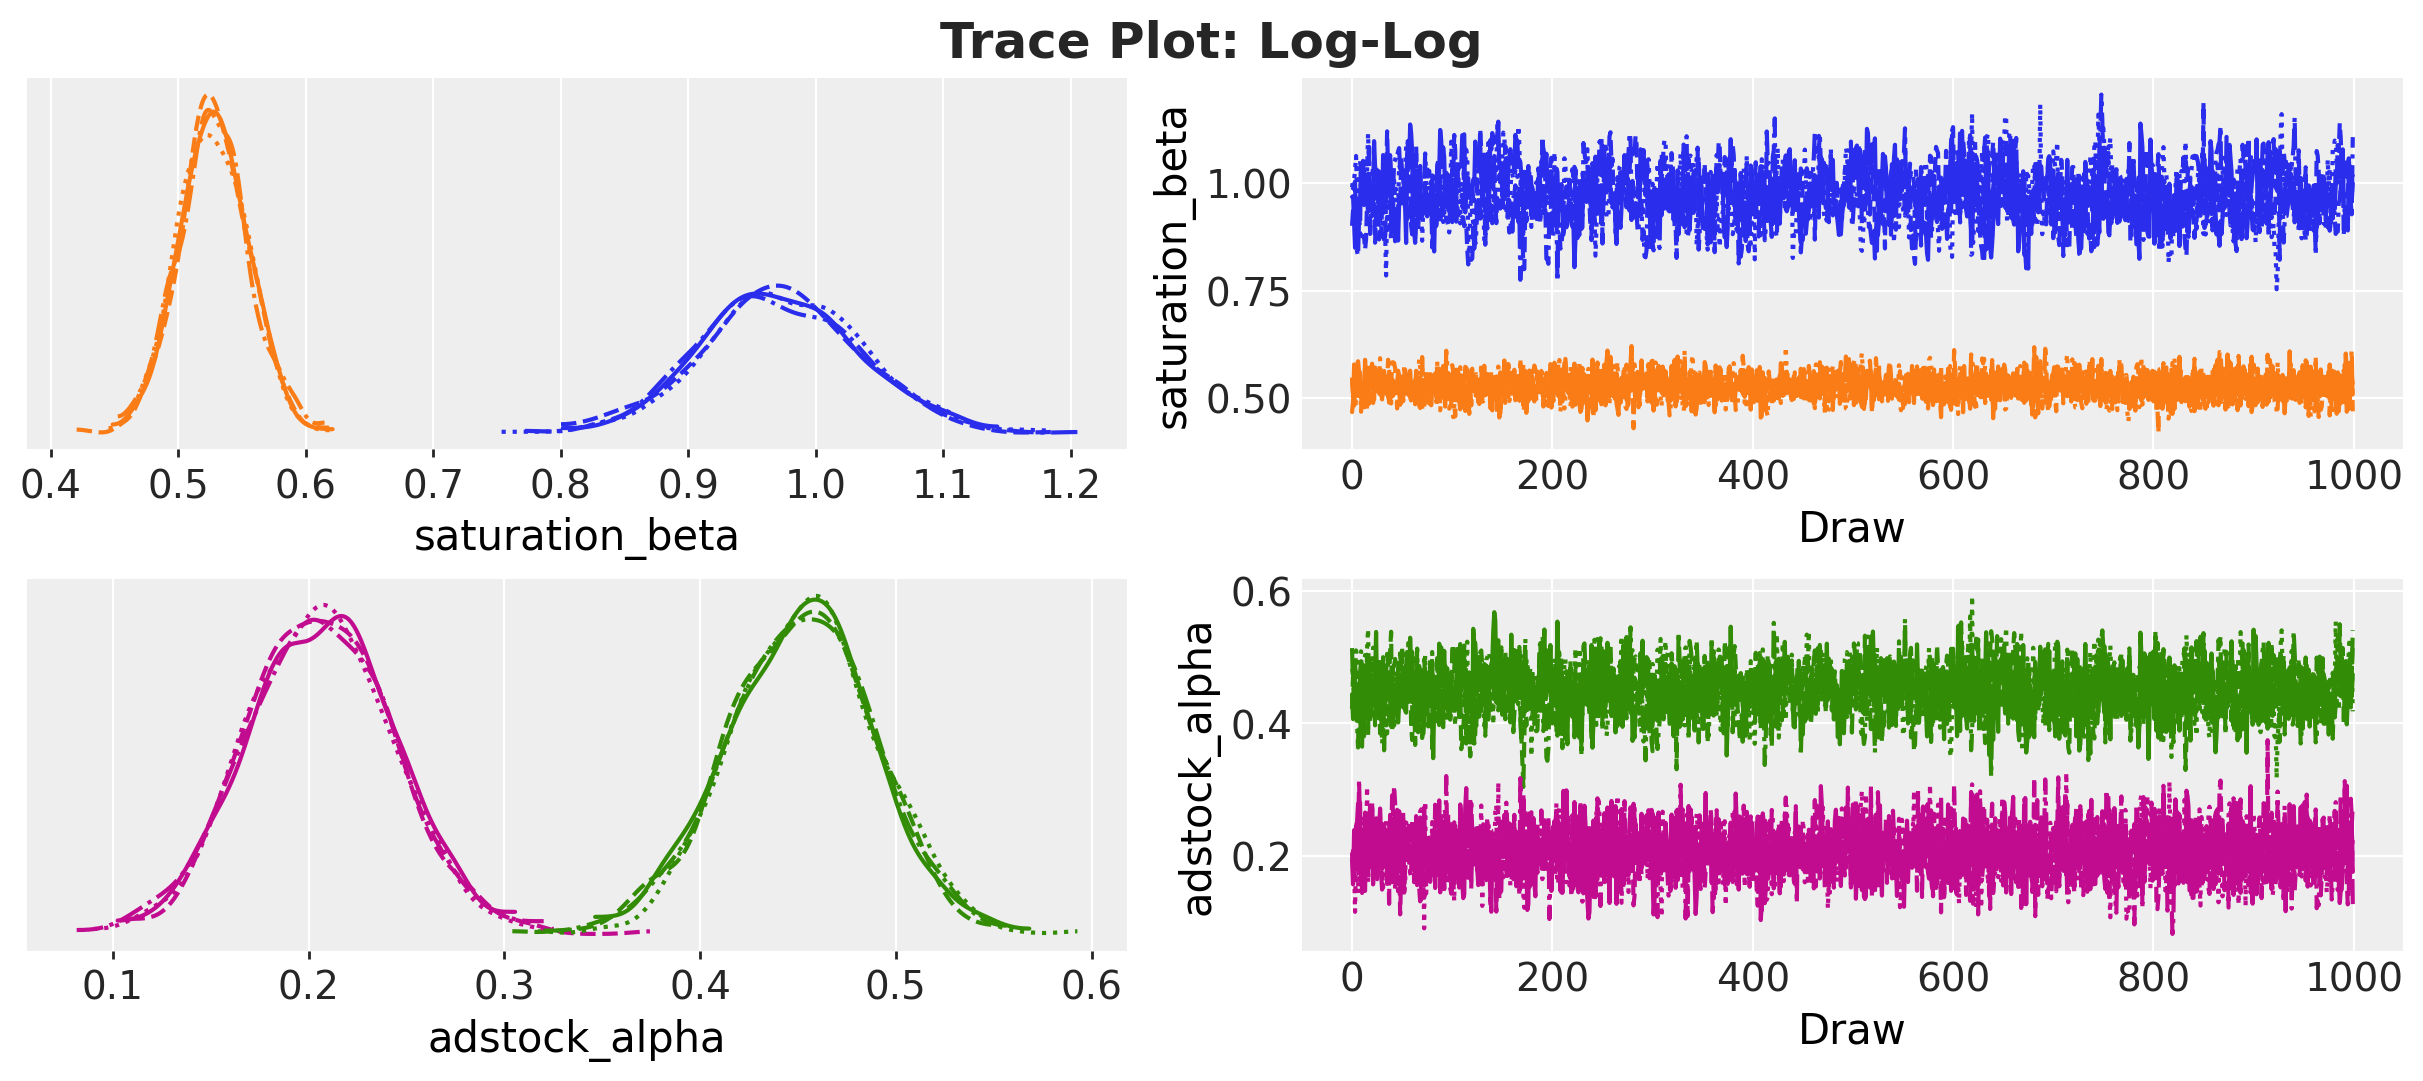

In [26]:
plot_trace_dist(mmm_loglog, "Log-Log", var_names=["saturation_beta", "adstock_alpha"])

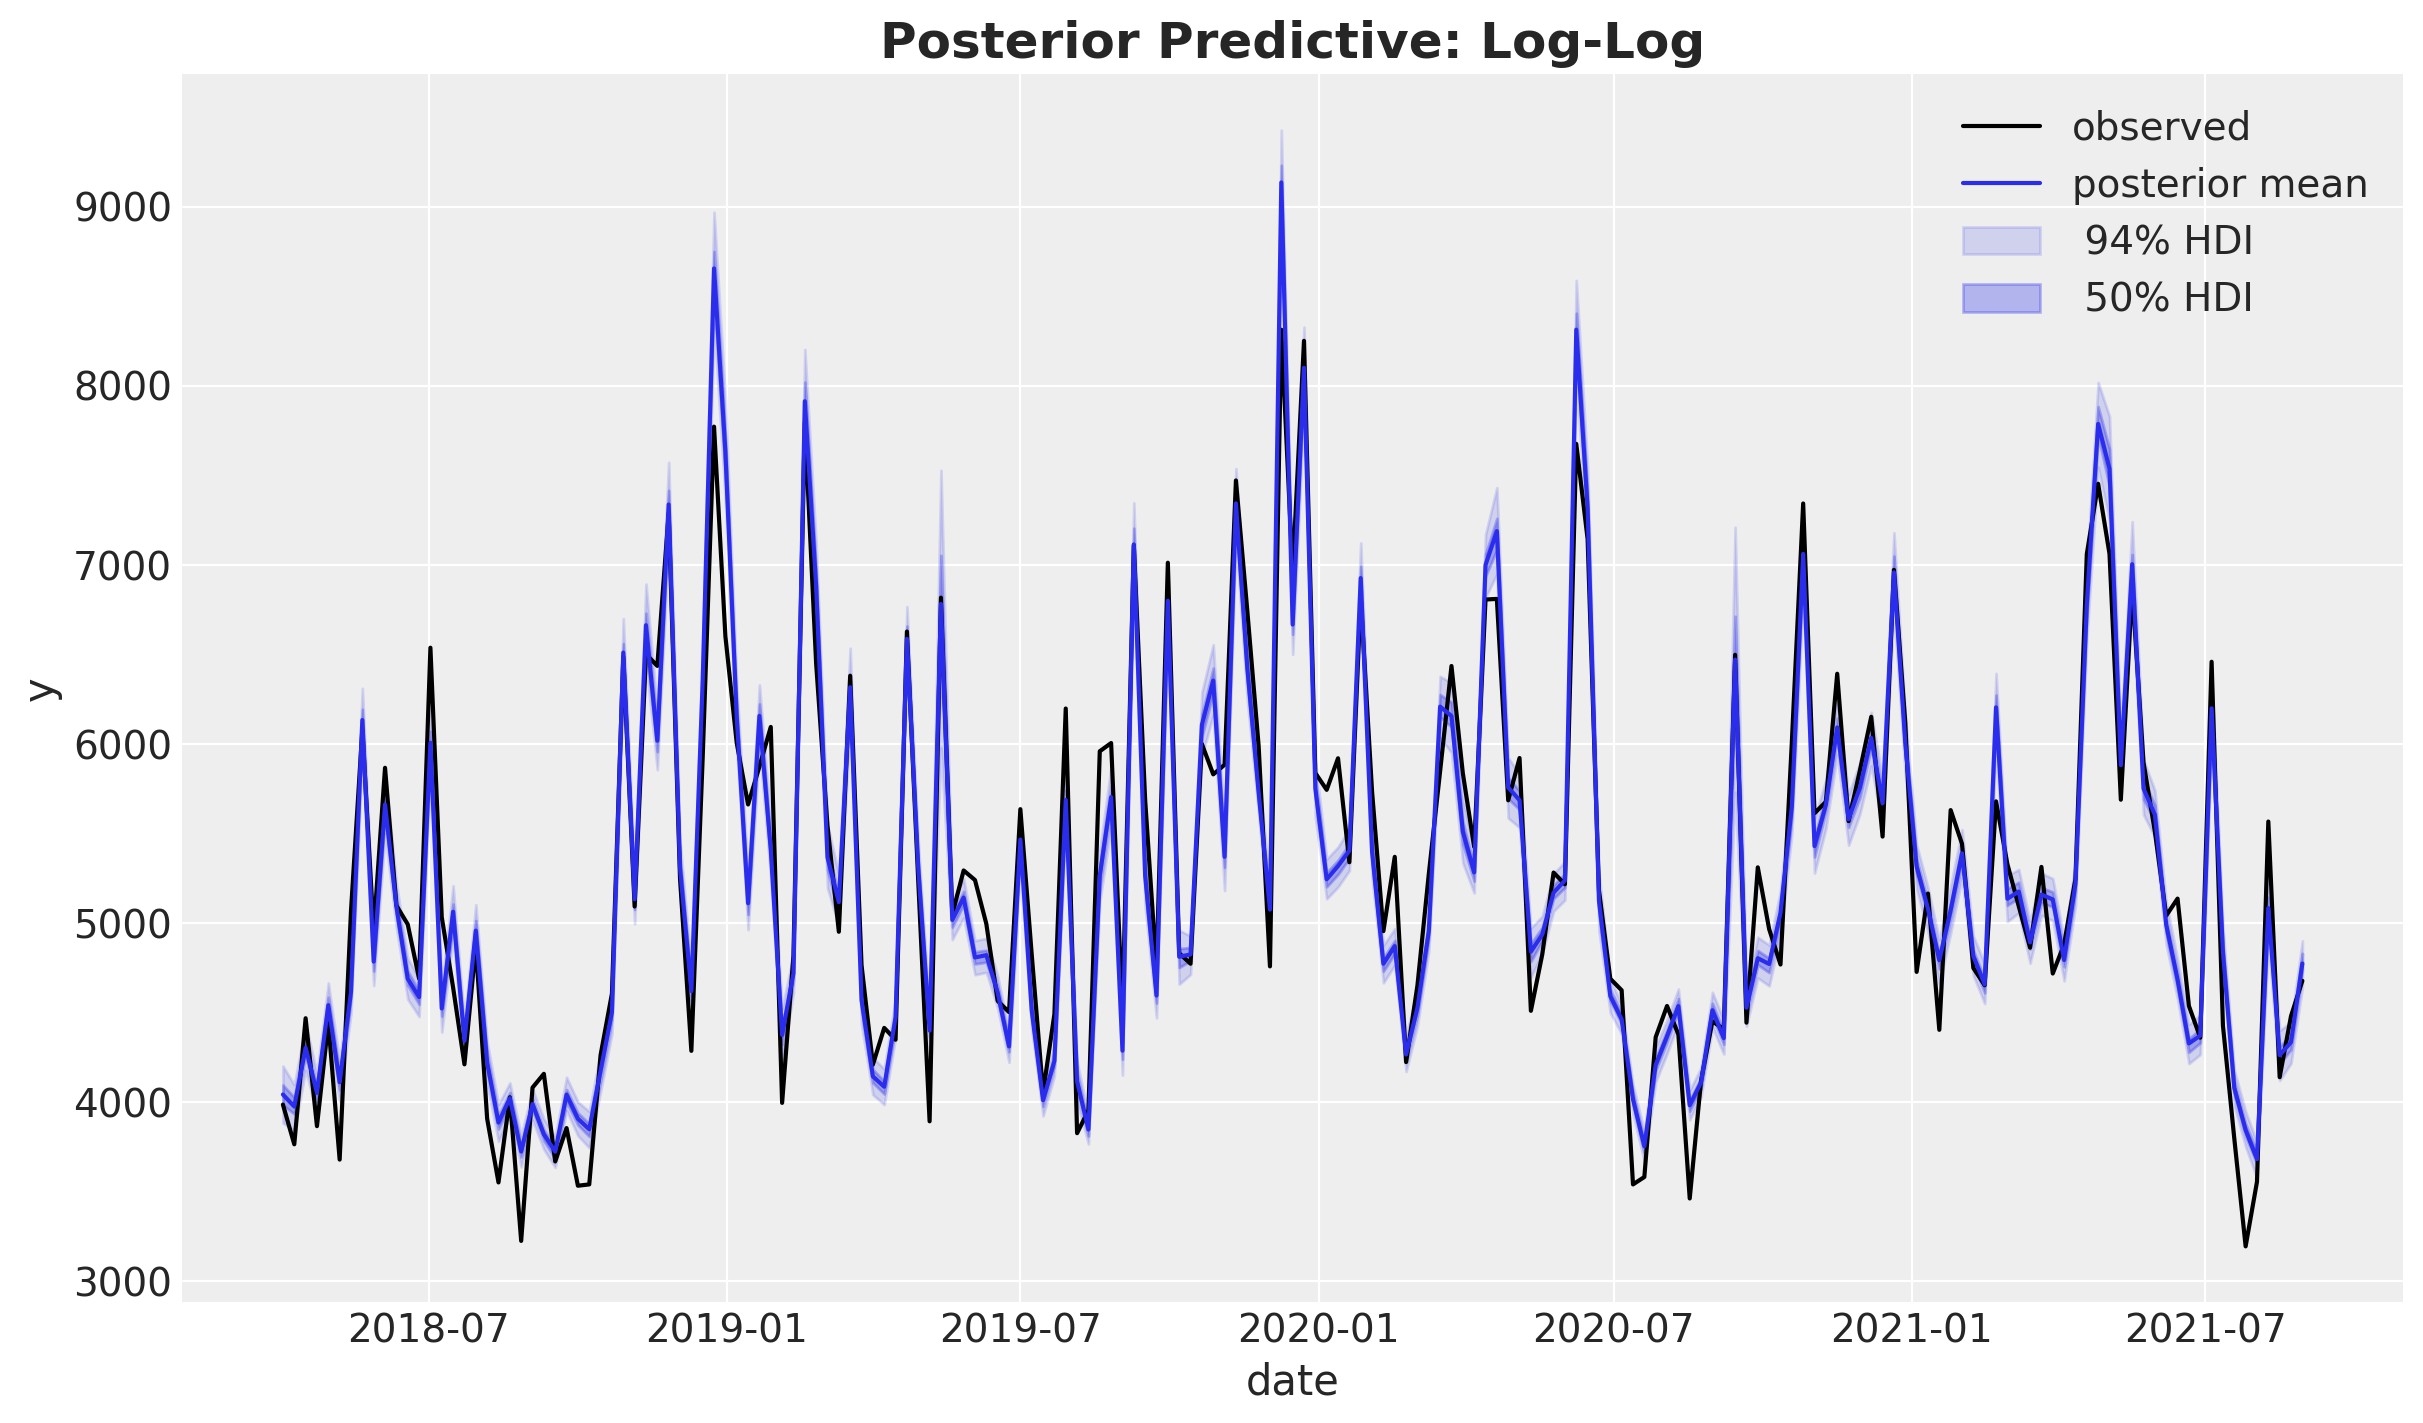

In [27]:
fig, ax = plot_posterior_predictive(mmm_loglog, model_name="Log-Log", y_obs=y)

The log-log model fits the data comparably to the other two specifications. On this synthetic additive dataset the three models converge on similar predictions, though their internal decompositions differ.

In [28]:
contributions_loglog = mmm_loglog.compute_mean_contributions_over_time()
contributions_loglog.head()

,date,x1,x2,event_1,event_2,t_norm,yearly_seasonality,intercept
0,2018-04-02,585.501588,0.0,0.0,0.0,0.000000,41.408971,-5781.267939
1,2018-04-09,476.207411,0.0,0.0,0.0,4.280999,83.913029,-5685.805909
2,2018-04-16,766.949981,0.0,0.0,0.0,9.265822,131.456346,-6156.450100
3,2018-04-23,485.130038,0.0,0.0,0.0,13.077282,152.150319,-5795.719776
4,2018-04-30,956.948815,0.0,0.0,0.0,19.534705,187.564529,-6496.611254


The counterfactual decomposition for the log-log model works identically to the log model: same formula, same non-summing property. The only difference is the saturation function shape (`LogSaturation` instead of `LogisticSaturation`), which affects *how much* each channel contributes, not *how* contributions are computed.

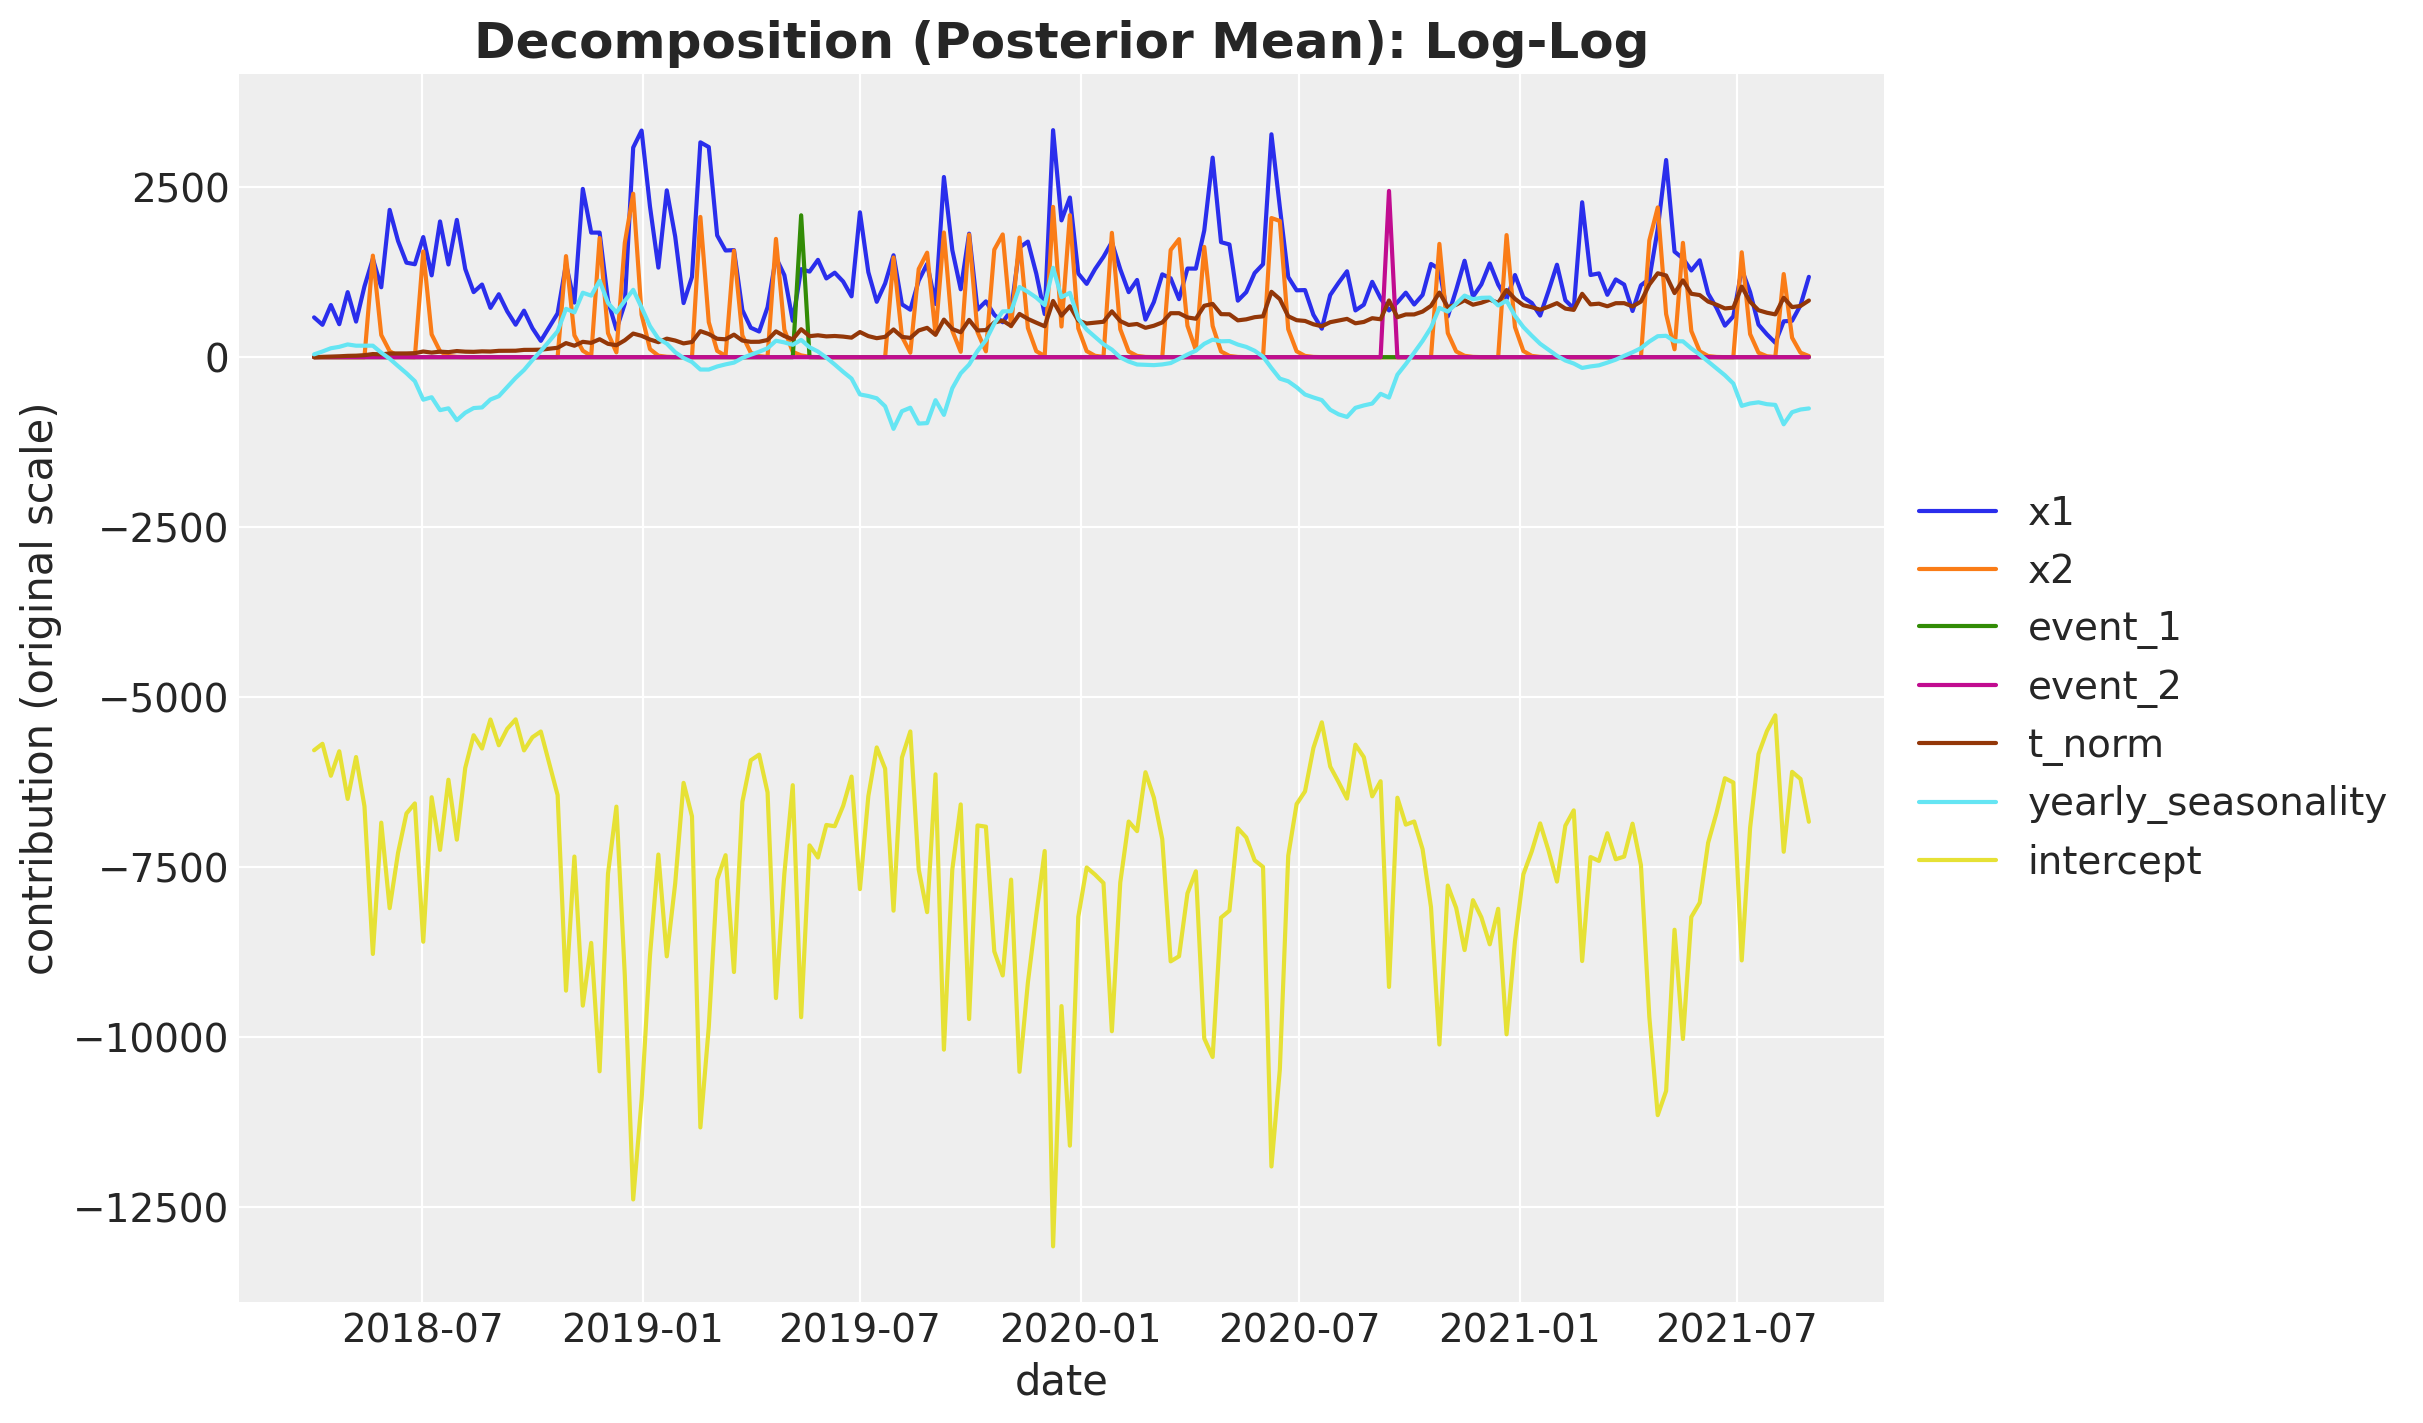

In [29]:
fig, ax = plot_decomposition(contributions_loglog, "Log-Log")

As with the log model, dropping the intercept makes the remaining contributions easier to read.

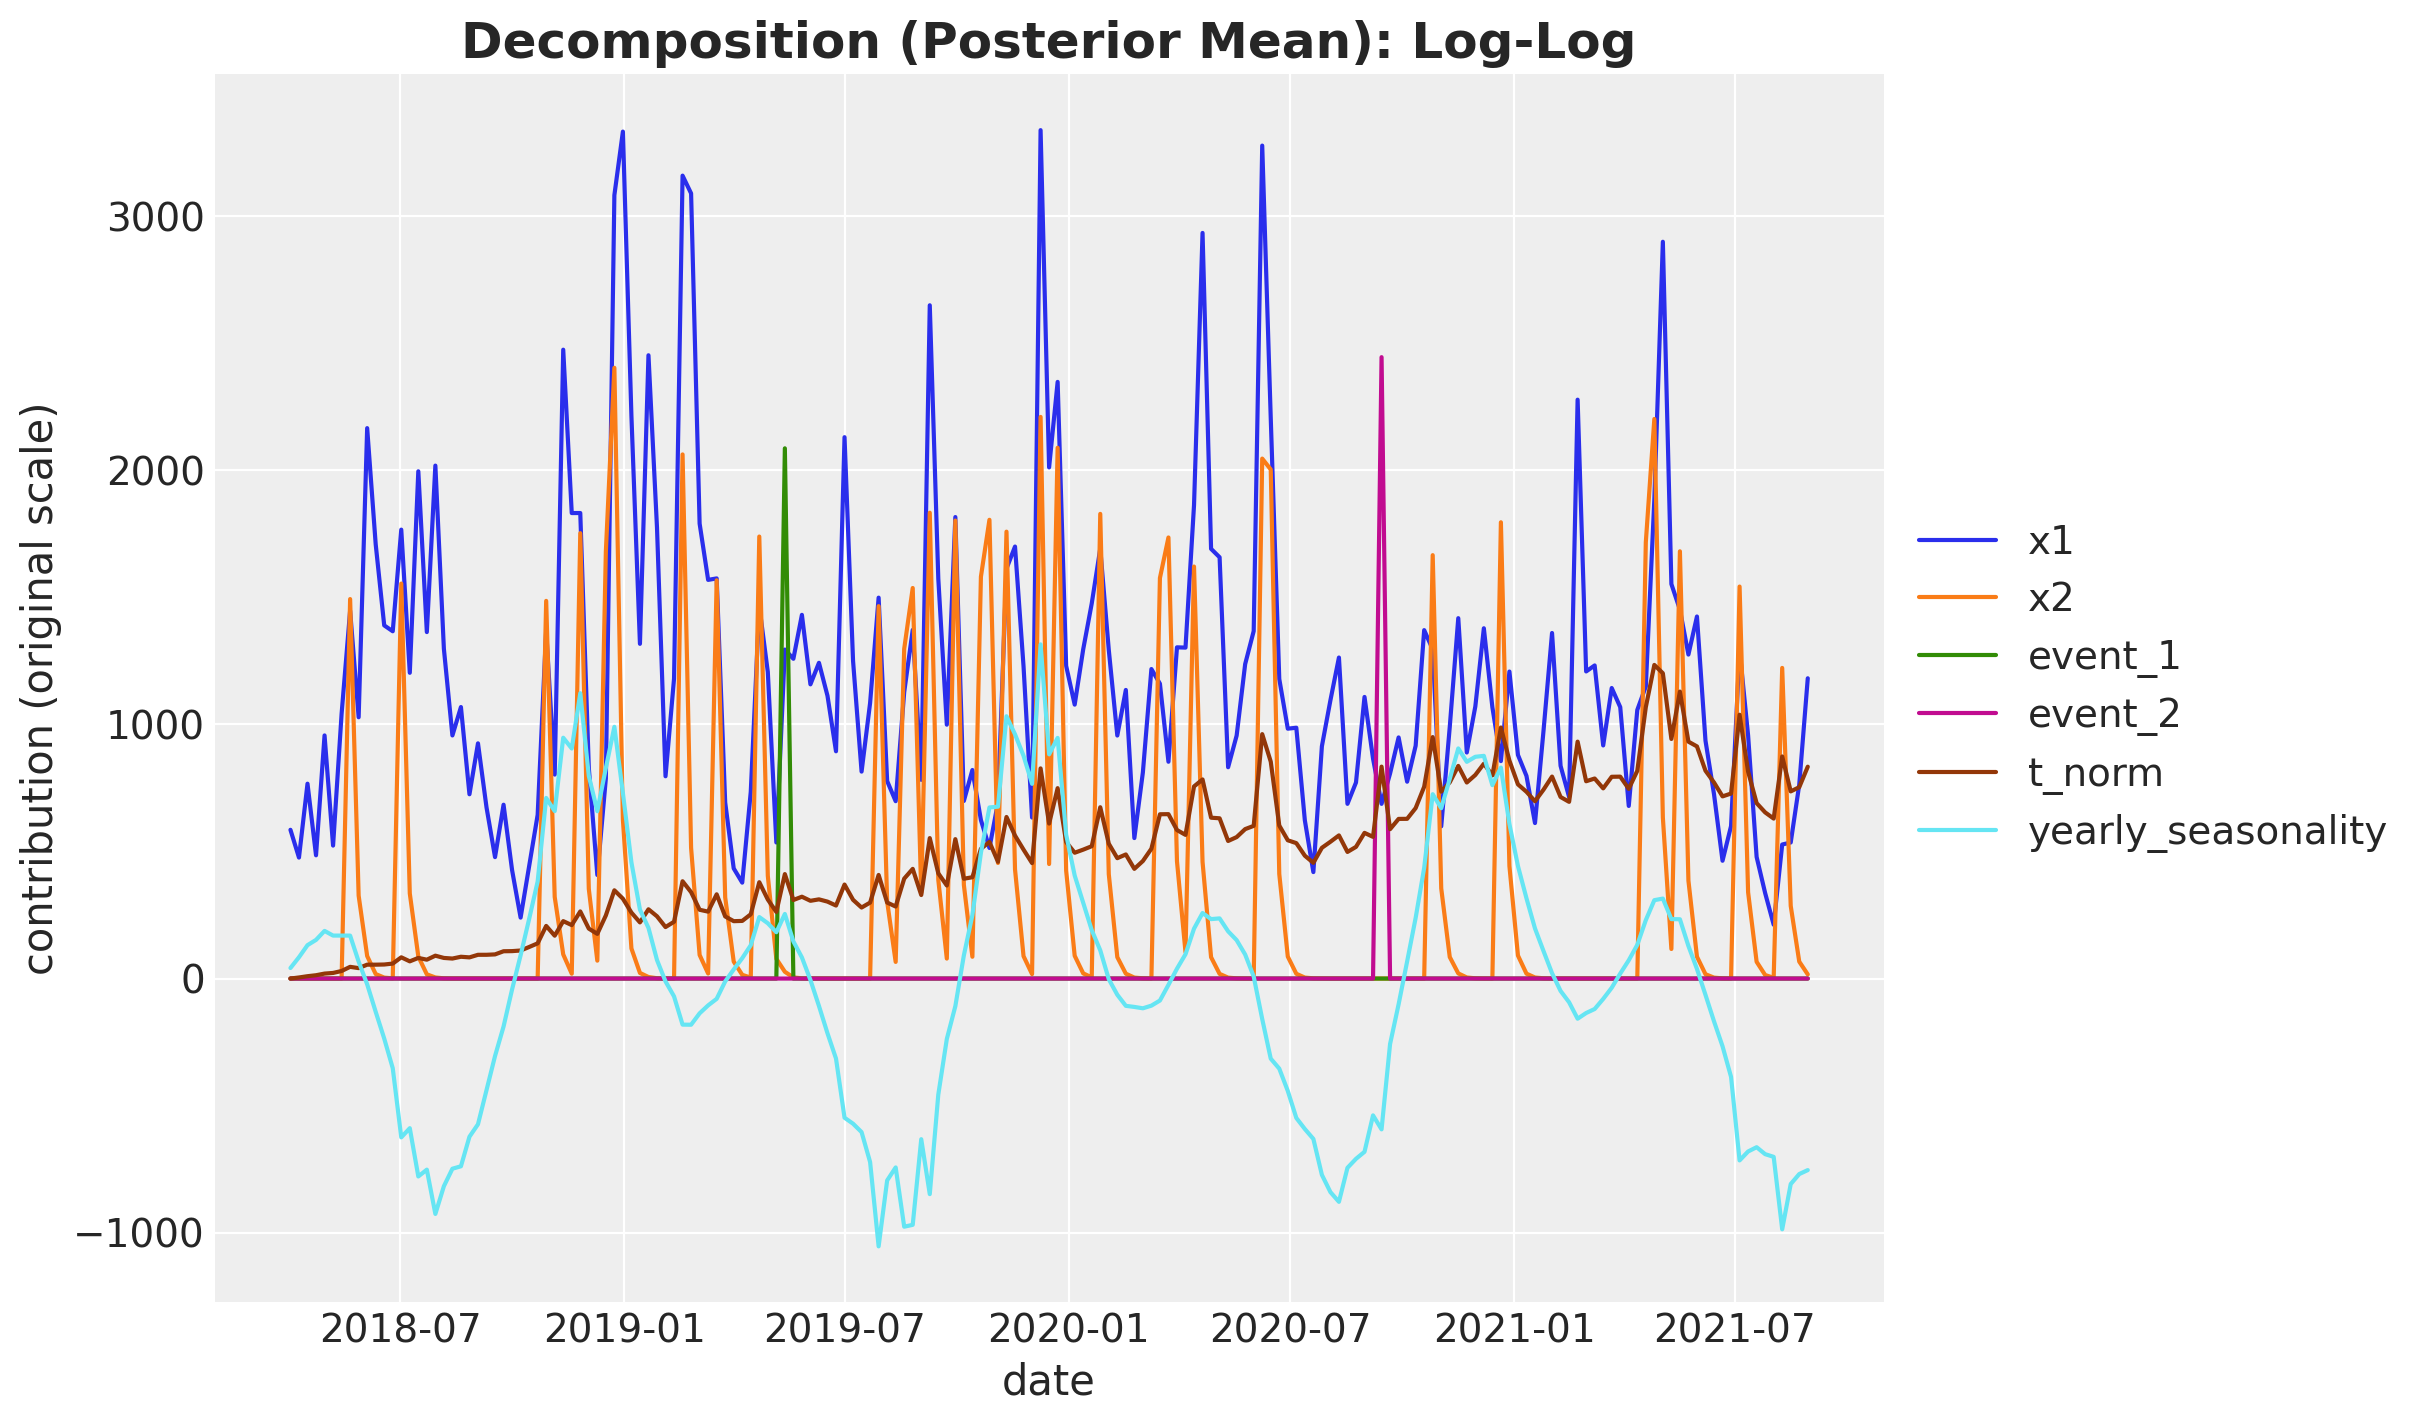

In [30]:
fig, ax = plot_decomposition(
    contributions_loglog.drop(columns=["intercept"]), "Log-Log"
)

## Decomposition Comparison

Having fitted all three models to the same data, we now compare their decompositions side by side. Since this synthetic dataset was generated with an additive process, the additive model should recover the true contributions most faithfully. The multiplicative models re-express the same fit through a different lens; the goal here is to see where they agree and where the link function choice matters.

### Media Contributions

The time-series overlay below shows whether the three models agree on the *shape* of each channel's contribution over time. The bar chart that follows compares their *relative magnitude* (which channel gets more credit).

In [31]:
decomp_data = [
    ("Additive", contributions_additive),
    ("Log (Multiplicative)", contributions_log),
    ("Log-Log", contributions_loglog),
]

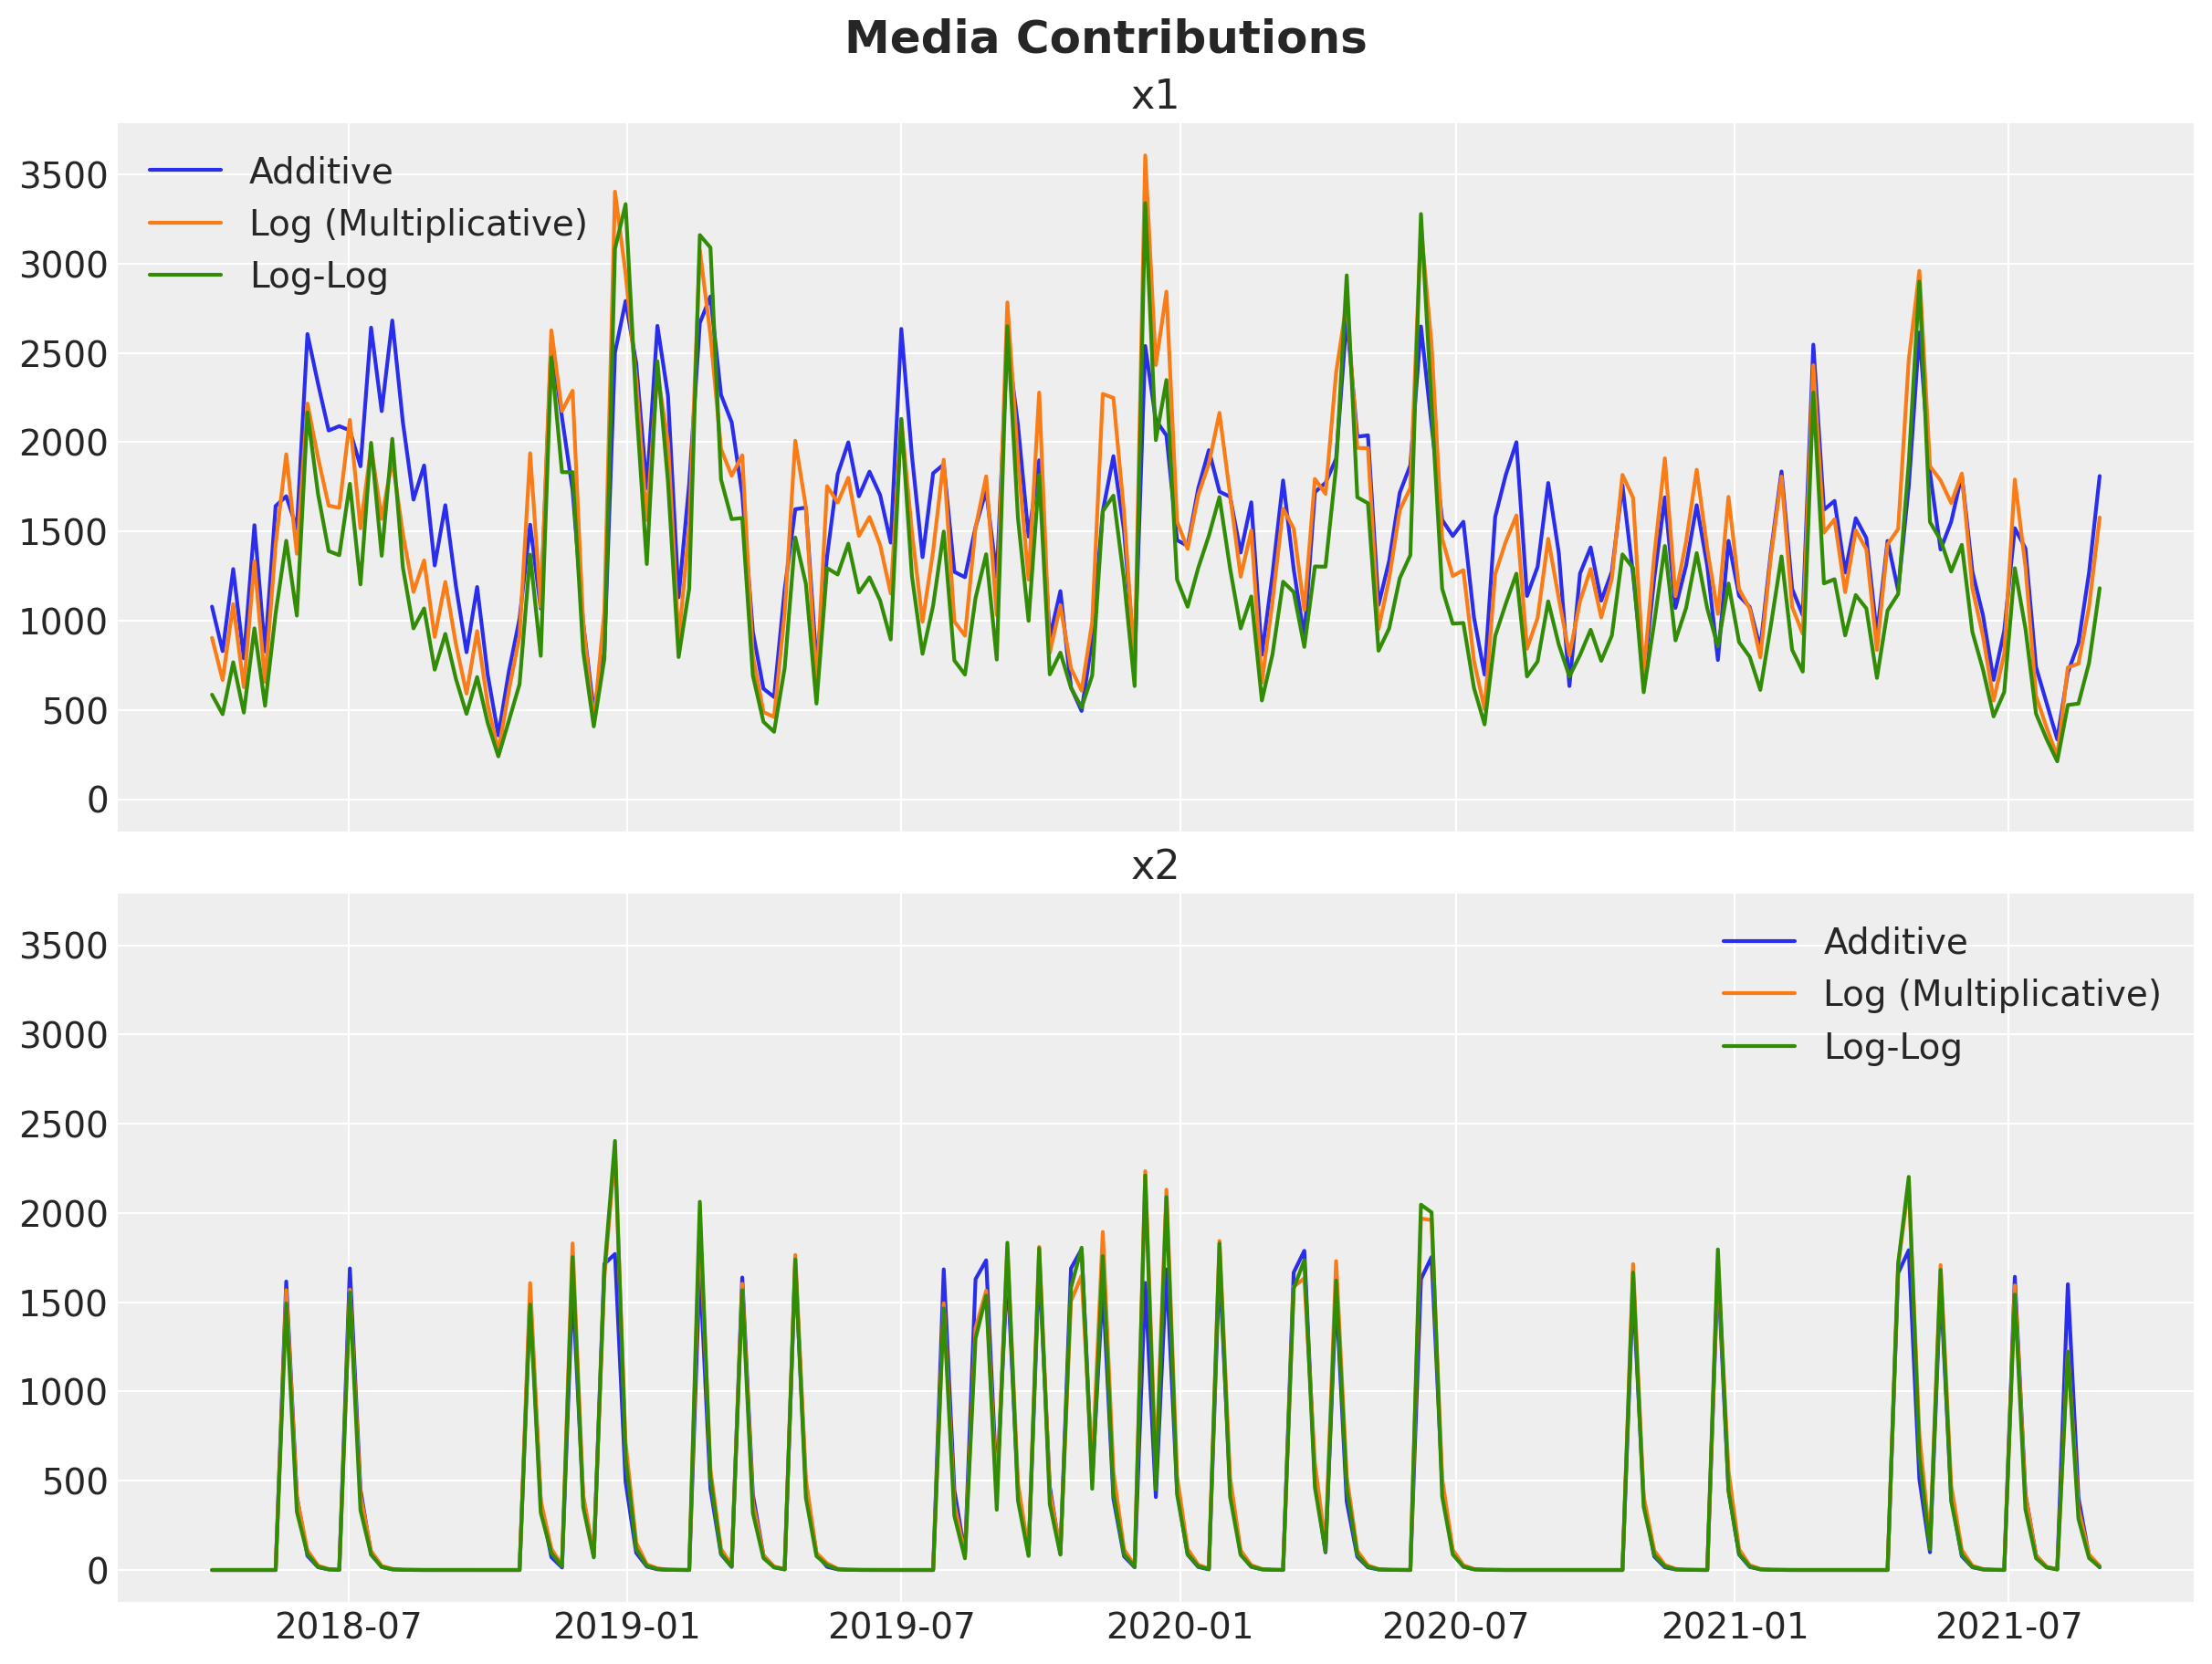

In [32]:
fig, ax = plt.subplots(
    nrows=len(CHANNELS),
    ncols=1,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for name, df in decomp_data:
    ax[0].plot(df["date"], df["x1"], label=name)
    ax[1].plot(df["date"], df["x2"], label=name)

ax[0].legend()
ax[0].set_title("x1")
ax[1].legend()
ax[1].set_title("x2")

fig.suptitle("Media Contributions", fontsize=18, fontweight="bold");

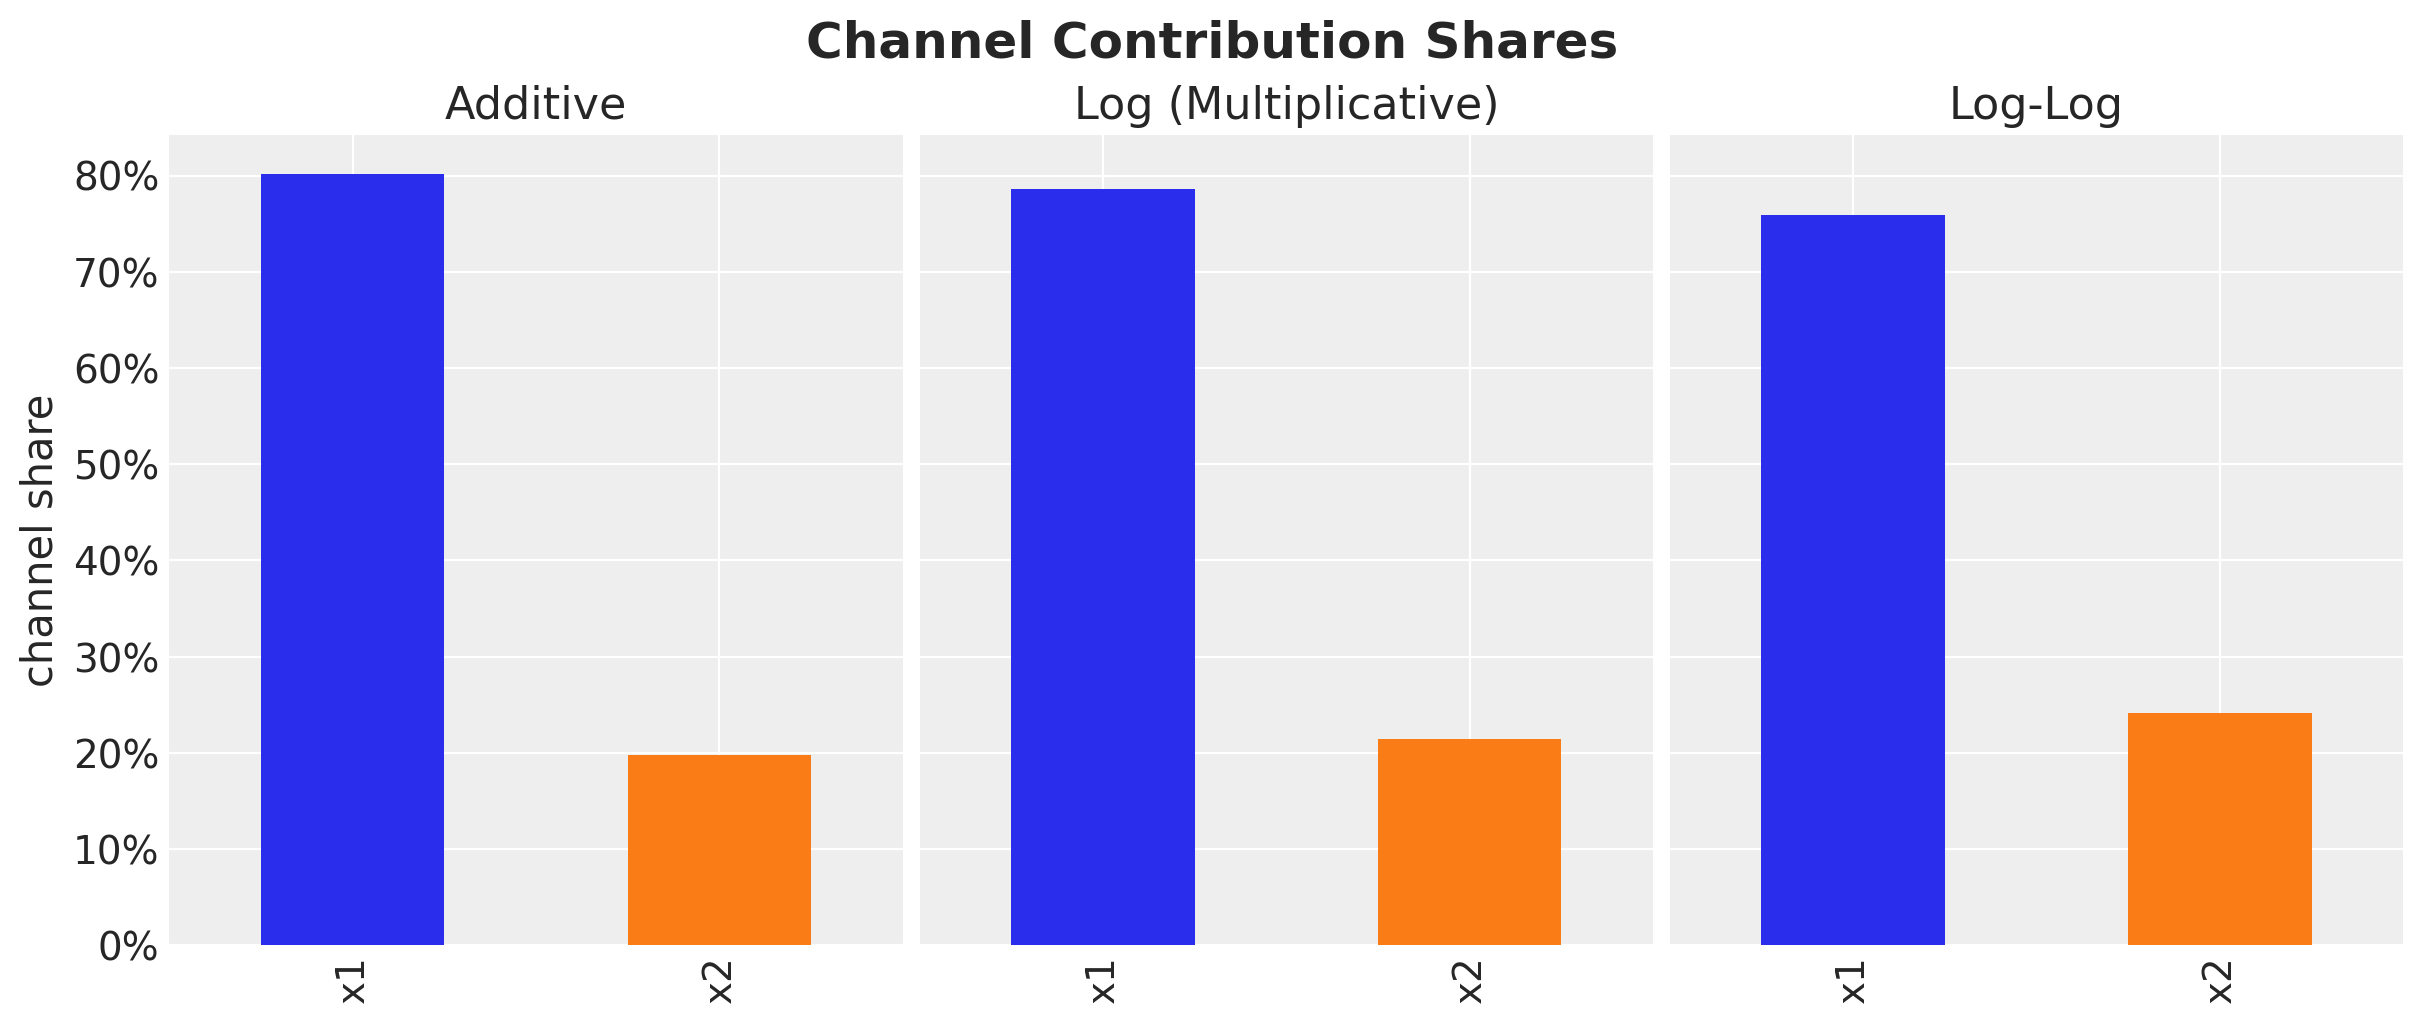

In [33]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(12, 5),
    sharex=True,
    sharey=True,
    layout="constrained",
)
for ax, (name, df) in zip(axes, decomp_data, strict=True):
    channel_total = df[CHANNELS].sum()
    channel_share = channel_total / channel_total.sum()
    channel_share.plot.bar(ax=ax, color=["C0", "C1"])
    ax.set(title=name, xlabel="", ylabel="channel share" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

fig.suptitle("Channel Contribution Shares", fontsize=18, fontweight="bold");

All three models agree on relative channel importance: `x1` consistently receives the larger share. This is reassuring, even though the multiplicative models decompose the total differently, they reach the same directional conclusion about which channel drives more sales.

### Non-Media Contributions

We compare how events and seasonality are attributed across models. Because these components represent shared structure (not marketing decision levers), agreement here increases confidence that the media estimates are not absorbing unrelated variation.

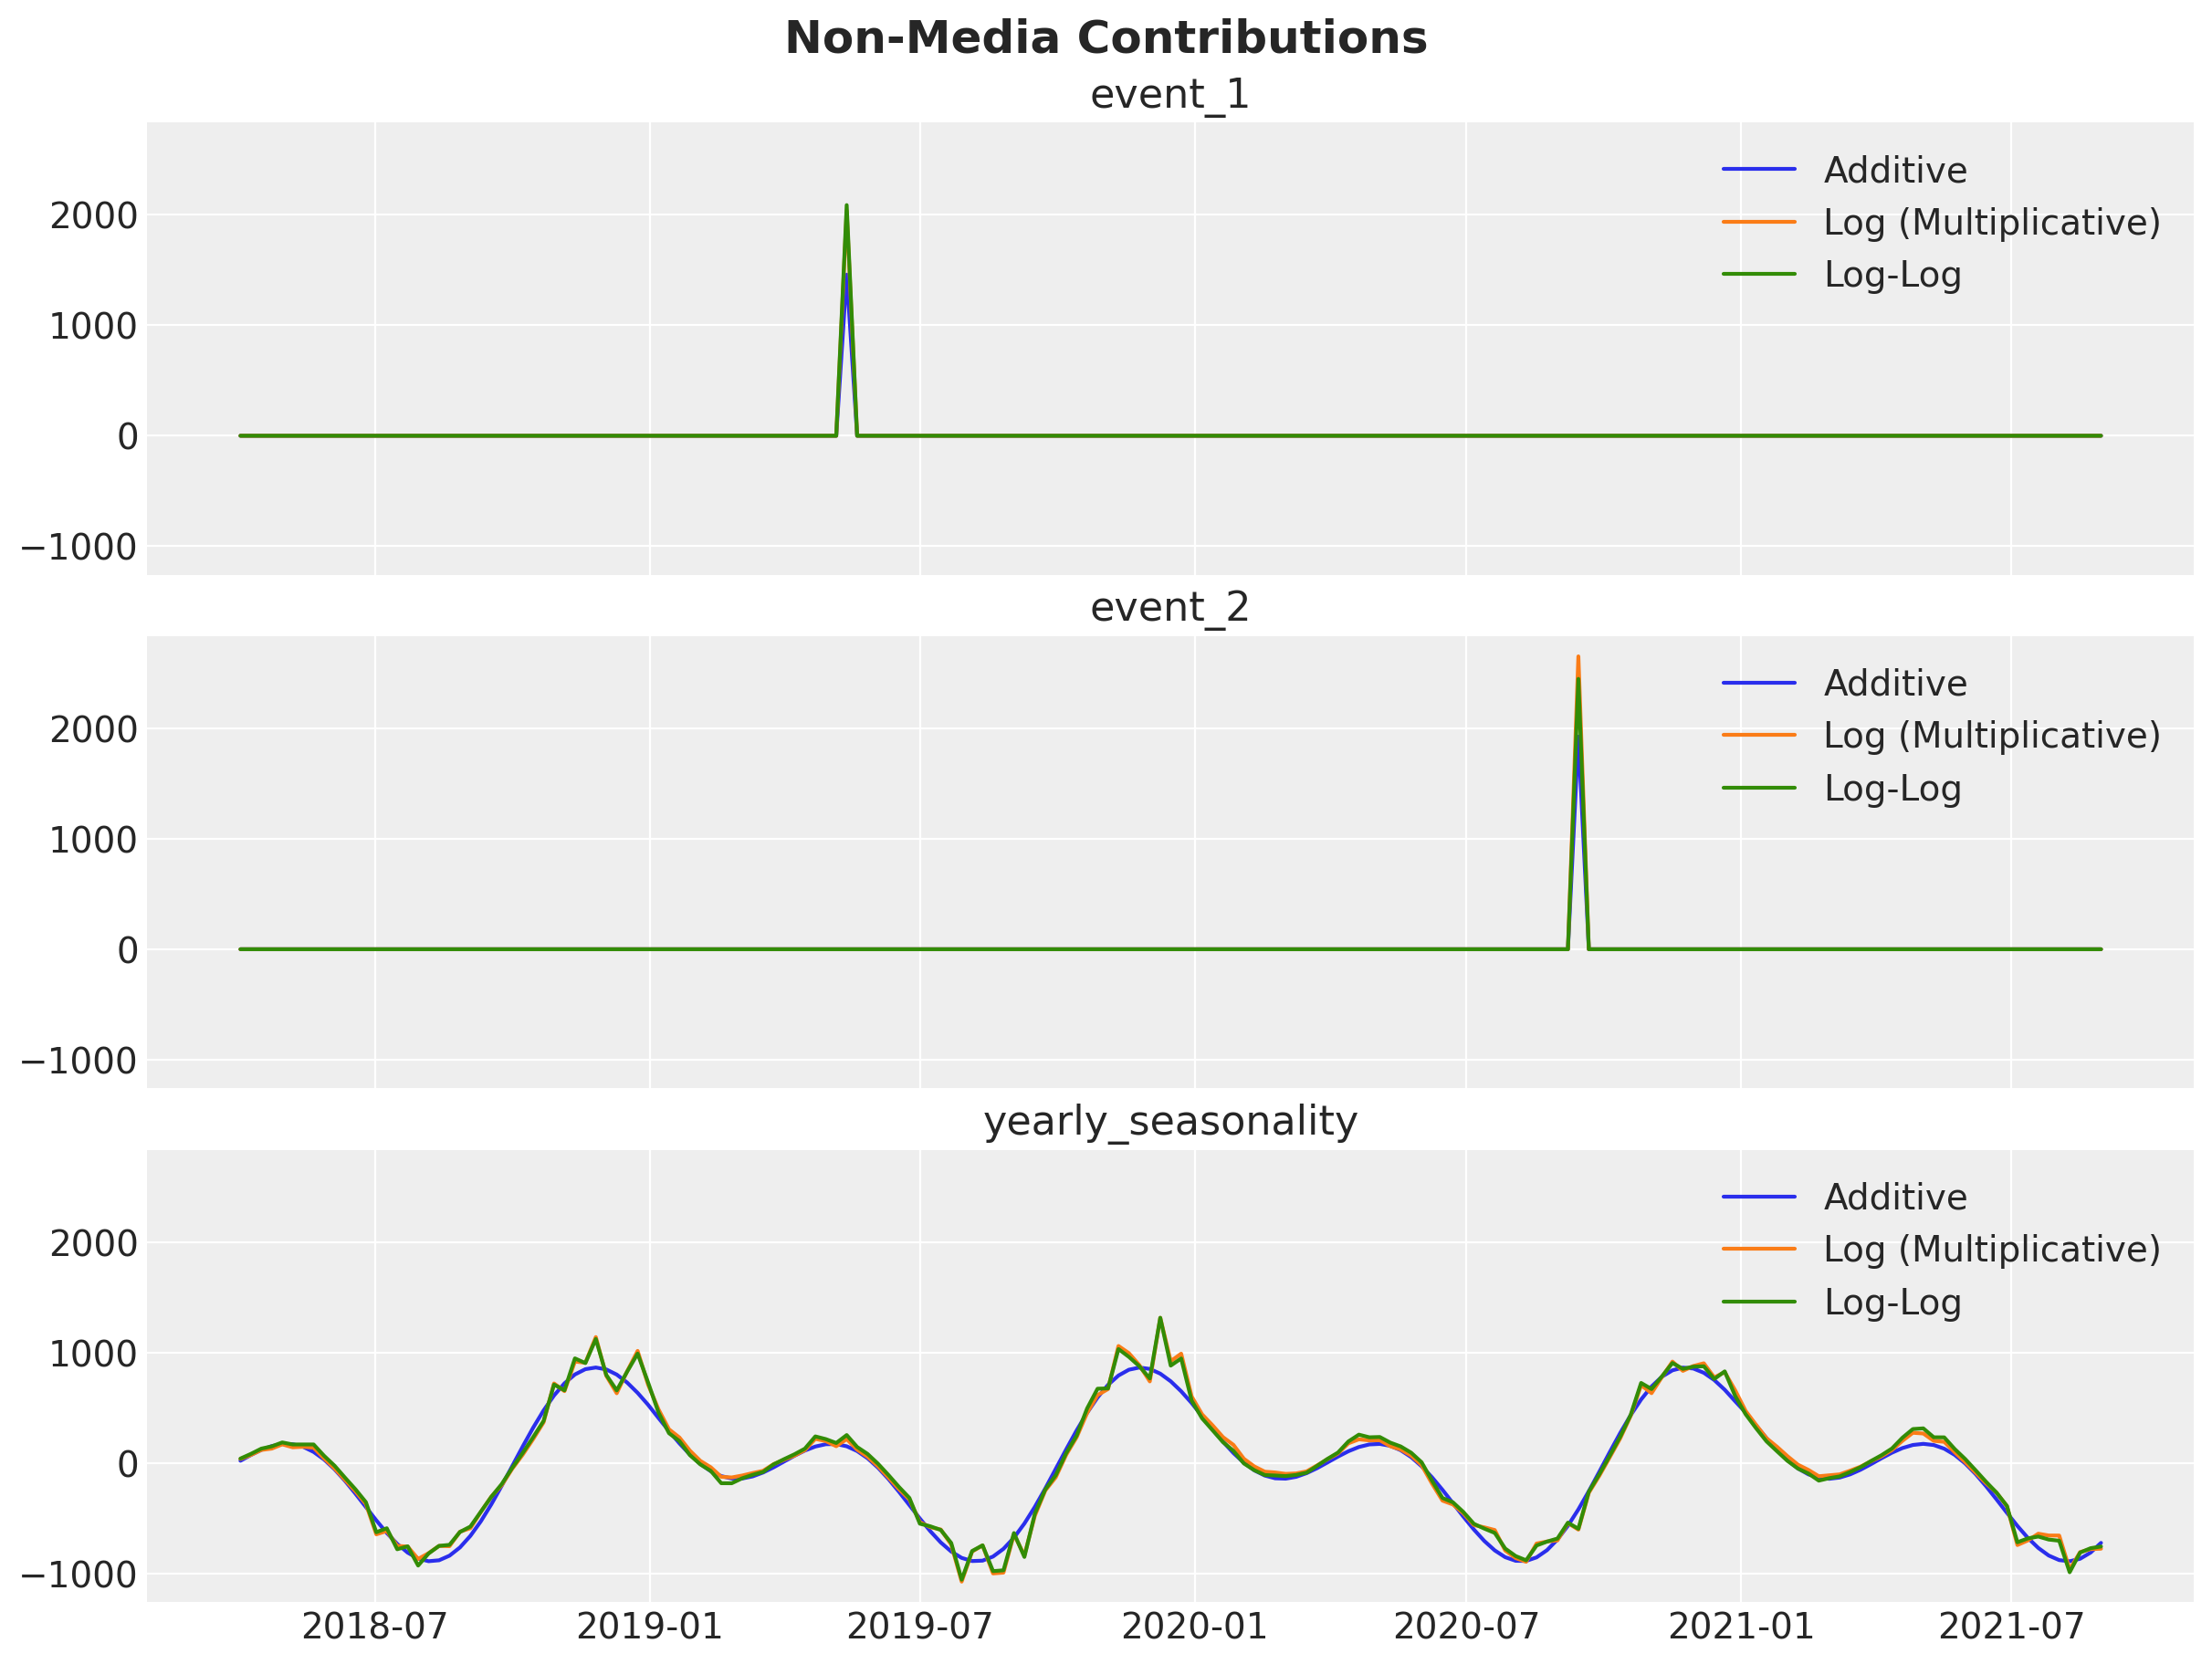

In [34]:
fig, ax = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for name, df in decomp_data:
    ax[0].plot(df["date"], df["event_1"], label=name)
    ax[1].plot(df["date"], df["event_2"], label=name)
    ax[2].plot(df["date"], df["yearly_seasonality"], label=name)

ax[0].legend()
ax[0].set_title("event_1")
ax[1].legend()
ax[1].set_title("event_2")
ax[2].legend()
ax[2].set_title("yearly_seasonality")

fig.suptitle("Non-Media Contributions", fontsize=18, fontweight="bold");

Events and seasonality contributions are broadly consistent across models, with only minor differences in amplitude. This suggests the three specifications agree on the non-media structure and differ mainly in how they partition the remaining media effect.

## ROAS Comparison

The decompositions above cannot be compared across links number-for-number: under a log link the per-component contributions overlap and do not sum to $\hat y(t)$. Return on ad spend (ROAS) *can* be compared. It is defined by a genuine spend counterfactual (the drop in predicted sales when a channel's spend is set to zero, divided by that spend), and the `mmm.incrementality` module evaluates this counterfactual **on the response scale** for every link. For the additive model the increment reduces to summing the channel's contribution; under a log link the log-space change $\Delta\mu$ is passed through the inverse link first, $\sum_t \hat y_t \,(e^{\Delta\mu_t} - 1)$, following [Jin et al. (2017)](https://storage.googleapis.com/gweb-research2023-media/pubtools/3806.pdf). All three models are therefore asked the same question in the same units.

We use the default `central_tendency="median"`: under a LogNormal likelihood $\exp(\mu) \cdot s$ is the posterior *median* of the response, which corresponds to the noise-free curve of a data-generating process, the right convention for comparing against a known ground truth. For the identity link the argument is a no-op (median and mean of the symmetric Normal coincide).

Because this dataset is simulated, we know the true ROAS. The data comes from the additive data-generating process of the {ref}`MMM Example notebook <mmm_example>` (scaled by a factor of $1000$): each channel's contribution to sales is $1000 \cdot \beta_c \cdot \text{logistic}_{\lambda_c}(\text{adstock}_{\alpha_c}(x_c))$ with $\alpha = (0.4, 0.2)$, $\lambda = (4, 3)$, and $\beta = (3, 2)$. Applying those known transformations to the observed spend gives the true incremental sales, hence the true ROAS:

In [35]:
TRUE_PARAMS = {
    "x1": {"alpha": 0.4, "lam": 4.0, "beta": 3.0},
    "x2": {"alpha": 0.2, "lam": 3.0, "beta": 2.0},
}
AMPLITUDE = 1_000  # scale factor between the DGP and mmm_example.csv

true_roas = {}
for channel, params in TRUE_PARAMS.items():
    adstocked = geometric_adstock(
        x=xr.DataArray(data[channel].to_numpy(), dims=("date",)),
        alpha=params["alpha"],
        l_max=8,
        normalize=True,
        dim="date",
    )
    saturated = logistic_saturation(x=adstocked, lam=params["lam"])
    true_contribution = AMPLITUDE * params["beta"] * np.asarray(saturated.eval())
    true_roas[channel] = true_contribution.sum() / data[channel].sum()

true_roas

{'x1': np.float64(4967.8319529471255), 'x2': np.float64(2274.883311294693)}

Each model's ROAS posterior comes from `contribution_over_spend` with `frequency="all_time"`: one number per channel and posterior draw, so the comparison below carries full uncertainty.

In [36]:
roas_by_model = {
    "Additive": mmm_additive.incrementality.contribution_over_spend(
        frequency="all_time"
    ).rename("roas"),
    "Log (Multiplicative)": mmm_log.incrementality.contribution_over_spend(
        frequency="all_time"
    ).rename("roas"),
    "Log-Log": mmm_loglog.incrementality.contribution_over_spend(
        frequency="all_time"
    ).rename("roas"),
}

roas_dt = xr.DataTree.from_dict(
    {
        "/posterior": xr.DataTree(
            xr.concat(
                [roas.to_dataset() for roas in roas_by_model.values()], dim="model"
            ).assign_coords(model=list(roas_by_model))
        )
    }
)

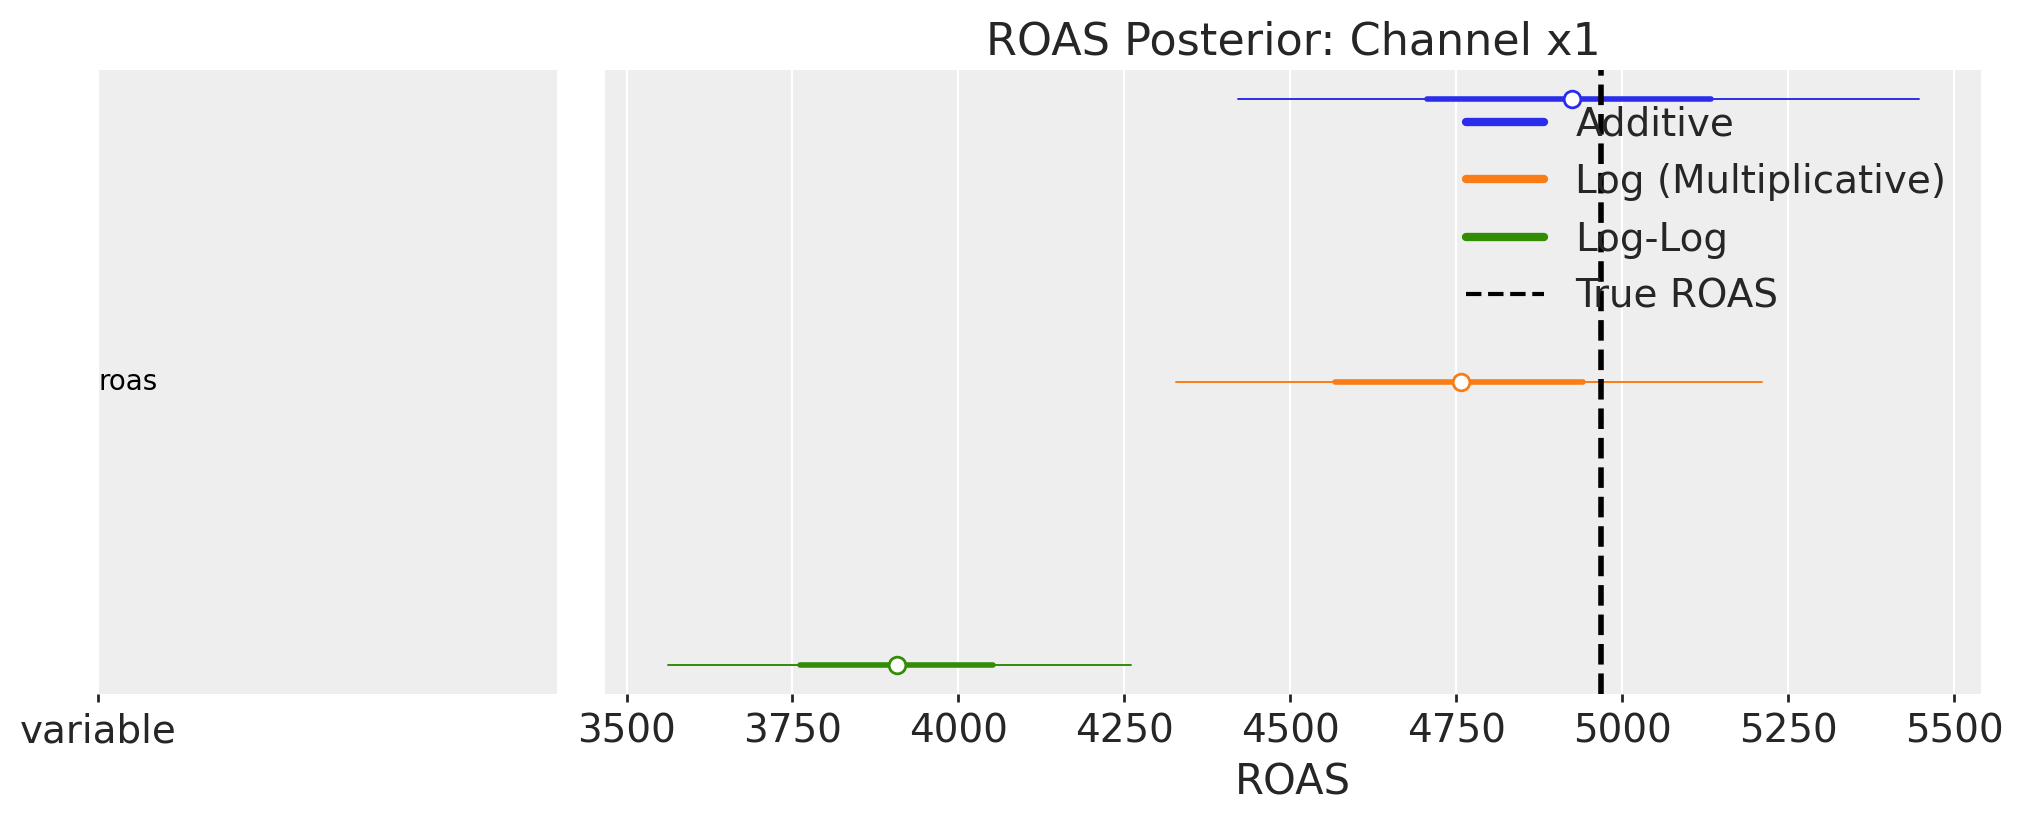

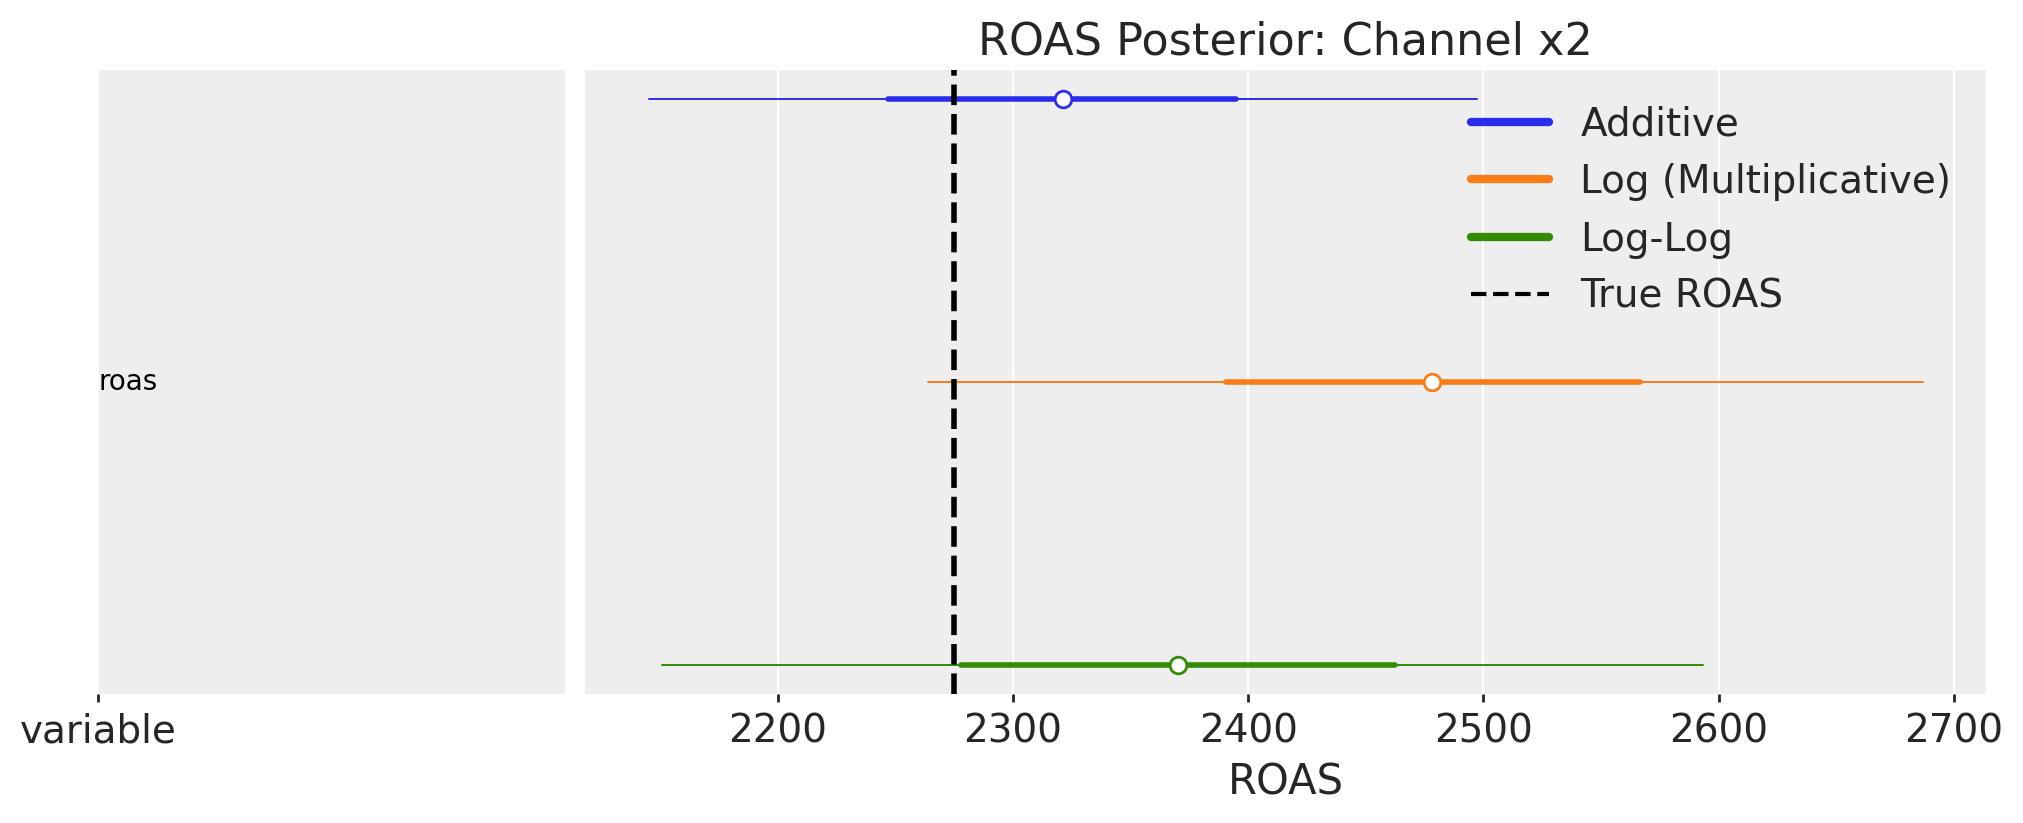

In [37]:
def plot_roas_forest(roas_dt, channel, true_value):
    """Forest plot of the three models' ROAS posteriors for one channel."""
    pc = azp.plot_forest(
        roas_dt.sel(channel=channel),
        combined=True,
        figure_kwargs={"figsize": (10, 4)},
    )
    ax = pc.viz["plot"].sel(column="forest").item()
    ax.axvline(true_value, color="black", linestyle="--", linewidth=2)

    color_map = pc.aes["color"]["mapping"]
    handles = [
        Line2D([0], [0], color=str(color_map.sel(model=m).values), linewidth=3, label=m)
        for m in roas_dt["posterior"]["model"].values
    ]
    handles.append(Line2D([0], [0], color="black", linestyle="--", label="True ROAS"))
    ax.legend(handles=handles, loc="upper right")
    ax.set(xlabel="ROAS", title=f"ROAS Posterior: Channel {channel}")


for channel in CHANNELS:
    plot_roas_forest(roas_dt, channel, true_roas[channel])

The table below summarizes the same comparison: posterior median, 94% HDI, and the relative error of the median against the truth.

In [38]:
roas_rows = []
for name, roas in roas_by_model.items():
    for channel in CHANNELS:
        samples = roas.sel(channel=channel)
        median = samples.median().item()
        hdi = az.hdi(samples, prob=0.94)
        truth = true_roas[channel]
        roas_rows.append(
            {
                "Model": name,
                "Channel": channel,
                "Median ROAS": round(median, 1),
                "HDI 3%": round(hdi.sel(ci_bound="lower").item(), 1),
                "HDI 97%": round(hdi.sel(ci_bound="upper").item(), 1),
                "True ROAS": round(truth, 1),
                "Median Rel. Error (%)": round(100 * (median - truth) / truth, 1),
            }
        )

roas_summary_df = pd.DataFrame(roas_rows)
print(roas_summary_df.to_string(index=False))

               Model Channel  Median ROAS  HDI 3%  HDI 97%  True ROAS  Median Rel. Error (%)
            Additive      x1       4916.8  4307.3   5495.0     4967.8                   -1.0
            Additive      x2       2320.7  2105.8   2510.3     2274.9                    2.0
Log (Multiplicative)      x1       4744.2  4276.0   5302.4     4967.8                   -4.5
Log (Multiplicative)      x2       2476.8  2221.5   2718.7     2274.9                    8.9
             Log-Log      x1       3900.2  3511.5   4342.3     4967.8                  -21.5
             Log-Log      x2       2367.9  2113.7   2633.5     2274.9                    4.1


All three models agree on the ranking (`x1` is roughly twice as efficient as `x2`) and land in the same range for both channels. The additive model recovers the truth within one to two percent, as expected for the well-specified model. The log model, although misspecified for this additive dataset, stays within a few percent as well, with 94% intervals covering the truth for both channels. The log-log model underestimates `x1`'s ROAS by roughly 20%, with an interval that excludes the truth: of the three it is the most misspecified, since $\beta \log(1 + x)$ cannot reproduce the logistic saturation that generated the data. A comparable estimand does not repair a wrong functional form: it exposes it.

That comparability is the practical payoff of a link-aware incrementality computation: the spend counterfactual is always reduced on the response scale, so ROAS is an estimand you can hold fixed while varying the model specification: a sound basis for comparing, and stress-testing, structurally different MMMs. Computed naively in the linear predictor's space instead, the two log models' "ROAS" would not even be in units of sales.

## Summary Metrics

We close with a quick quantitative comparison. MAE and RMSE measure in-sample prediction error in the original units of $y$; MAPE expresses the same error as a percentage of observed sales. Divergences indicate sampling problems (ideally zero for all models).

In [39]:
y_hat_additive = (
    mmm_additive.idata["posterior"]["y_original_scale"]
    .mean(dim=("chain", "draw"))
    .to_numpy()
)
y_hat_log = (
    mmm_log.idata["posterior"]["y_original_scale"]
    .mean(dim=("chain", "draw"))
    .to_numpy()
)
y_hat_loglog = (
    mmm_loglog.idata["posterior"]["y_original_scale"]
    .mean(dim=("chain", "draw"))
    .to_numpy()
)

results = []
for name, mmm_obj, y_hat in [
    ("Additive", mmm_additive, y_hat_additive),
    ("Log (Multiplicative)", mmm_log, y_hat_log),
    ("Log-Log", mmm_loglog, y_hat_loglog),
]:
    n_div = mmm_obj.idata["sample_stats"]["diverging"].sum().item()
    residuals = y.values - y_hat
    mae = np.abs(residuals).mean()
    rmse = np.sqrt((residuals**2).mean())
    mape = np.abs(residuals / y.values).mean() * 100

    results.append(
        {
            "Model": name,
            "Divergences": int(n_div),
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "MAPE (%)": round(mape, 2),
        }
    )

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

               Model  Divergences    MAE   RMSE  MAPE (%)
            Additive            0 196.92 249.19      3.90
Log (Multiplicative)            0 207.59 264.54      4.05
             Log-Log            0 236.14 304.22      4.59


On this dataset, the additive model achieves the lowest prediction error across all metrics. This is expected: the synthetic data was generated by an additive process, so the additive model has a structural advantage.

This result should **not** be taken as evidence that the additive model is universally preferable. On real-world data the true generating process is unknown, and multiplicative relationships (e.g. media amplifying a seasonal baseline) are common. The choice of link function should be guided by:

1. **Domain knowledge**: does the business context suggest additive or multiplicative effects?
2. **Data characteristics**: are sales strictly positive? Is variance proportional to the mean (favoring log-link)?
3. **Model diagnostics**: convergence, posterior predictive checks, and out-of-sample performance.

When in doubt, fitting multiple specifications (as done here) and comparing diagnostics is a practical strategy, anchored on link-independent estimands like the incrementality-based ROAS above, which remain comparable no matter how each model maps its linear predictor to sales.

In [40]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pymc,nutpie

Last updated: Wed, 05 Aug 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc_marketing: 1.0.0.dev0
pymc          : 6.0.1
nutpie        : 0.16.11

arviz         : 1.2.0
arviz_plots   : 1.2.0
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
xarray        : 2026.4.0

Watermark: 2.6.0

